# <center>Topic 9. Time Series Analysis in Python</center>

# <center>Part 2. Predicting the Future with Prophet</center>

In the previous part, we explored two major forecasting approaches:

1. **Explicit time-series models**, such as SARIMA, which represent temporal dependence through autoregressive, moving-average, differencing, and seasonal components.

2. **Feature-based machine-learning models**, where temporal information is transformed into predictors such as lag values and calendar features, allowing models such as linear regression and XGBoost to learn forecasting relationships.

In this part, we examine another forecasting perspective: **decomposable time-series models**.

Instead of modeling temporal dependence directly or transforming the series into a large feature matrix, Prophet represents a time series as a combination of interpretable components:

$$
y(t)=\text{trend}+\text{seasonality}+\text{events}+\text{noise}.
$$

This makes Prophet particularly useful for business forecasting problems where understanding the contribution of different components is important.

## Article outline

1. Introduction

2. The Prophet forecasting model

   - Trend component
   - Seasonality component
   - Holidays and events
   - Error component

3. Practical forecasting with Prophet

   - Dataset preparation
   - Exploratory analysis
   - Model fitting
   - Forecast generation
   - Evaluation

4. Transformations and model improvements

5. Summary

## 1. Introduction

[Prophet](https://facebook.github.io/prophet/) is an open-source forecasting library originally developed at Facebook (now Meta) and introduced in the paper ["Forecasting at Scale"](https://peerj.com/preprints/3190/) by Sean J. Taylor and Benjamin Letham.

The model was designed for practical forecasting problems that commonly appear in business settings, especially time series containing:

- trend changes,
- multiple seasonal patterns,
- holiday or event effects,
- missing observations,
- and occasional outliers.

The main motivation behind Prophet is not to replace every forecasting method, but to provide an interpretable and practical framework that can be applied to many real-world forecasting tasks.

As with the methods explored previously, Prophet should be evaluated empirically. Its performance depends on the characteristics of the specific time series and should be compared against appropriate baselines and alternative models.

## 2. The Prophet Forecasting Model

At its core, Prophet uses a decomposable regression model. In its default additive formulation, the observed time series is represented as

$$
y(t)=g(t)+s(t)+h(t)+\epsilon_t
$$

where:

- $g(t)$ represents the trend component, describing long-term non-periodic changes.
- $s(t)$ represents seasonal effects, such as weekly or yearly patterns.
- $h(t)$ represents the effect of holidays or other known events.
- $\epsilon_t$ represents unexplained variation or noise.

This decomposition provides an alternative perspective compared with SARIMA. Rather than modeling autocorrelation structures directly, Prophet attempts to explain the observed series through interpretable sources of variation.

<details>
<summary><span style="color:red">
What we mean by modeling autocorrelation structure:

</span></summary>

In SARIMA, “modeling autocorrelation structures” means explicitly modeling how the current value of a time series is statistically related to its own past values and past forecast errors.

For example, in an autoregressive part,

$$
X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \varepsilon_t,
$$

SARIMA is saying that today's value may depend directly on yesterday's value, two days ago, etc. Those lag relationships are part of the series' autocorrelation structure.

The moving-average part models dependence on previous shocks/errors:

$$
X_t
=
\varepsilon_t
+
\theta_1\varepsilon_{t-1}
+\cdots
$$

and the seasonal AR/MA terms do the same thing at seasonal lags. For hourly data with daily seasonality, for example, a seasonal term may model the relationship between

$$
X_t
\quad\text{and}\quad
X_{t-24}.
$$

So when we fitted SARIMA in Part 1, we were explicitly asking questions such as:

> How strongly is the present related to recent observations?
> Are there relationships at seasonal lags?
> Do previous forecast errors help predict the current observation?

That is what I mean by **modeling autocorrelation structure**.

Prophet takes a different approach. Instead of primarily specifying lag relationships such as

$$
X_t \leftrightarrow X_{t-1}, X_{t-24}, \ldots,
$$

it tries to explain the series through components such as

$$
\text{trend}+\text{weekly seasonality}+\text{yearly seasonality}+\text{events}.
$$

So, very simply:

$$
\boxed{\text{SARIMA: model dependence across lags}}
$$

versus

$$
\boxed{\text{Prophet: model interpretable time-based components}}
$$

That is the distinction that sentence is trying to make.


</details>

Prophet can also model seasonal and holiday effects multiplicatively when their magnitude changes proportionally with the level of the series; we will return to this distinction later when considering model improvements.

### Trend

Prophet currently supports three built-in trend or growth formulations:

1. **Piecewise linear trend** (`growth="linear"`), which is the default.
2. **Saturating logistic growth** (`growth="logistic"`), for series with a meaningful carrying capacity.
3. **Flat trend** (`growth="flat"`), for situations in which no systematic trend growth is assumed.

<div dir="rtl" align="right">

یعنی:

**Prophet از سه گزینه‌ی داخلی برای مدل‌کردن روند (trend) پشتیبانی می‌کند:**

1. **روند خطیِ تکه‌ای (Piecewise linear trend)**
2. **روند رشد اشباع‌شونده (Saturating growth trend)**
3. **روند تخت یا ثابت (Flat trend)**

**Piecewise linear** یعنی روند از چند بخش خطی تشکیل شده که شیب آن می‌تواند در نقاط مختلف تغییر کند.

**Saturating growth** یعنی رشد به‌تدریج با نزدیک‌شدن به یک حد یا ظرفیت مشخص، کند می‌شود و به سمت آن حد میل می‌کند.  

**Flat trend** یعنی مدل تغییر روند سیستماتیکی را در طول زمان فرض نمی‌کند و مؤلفه‌ی روند ثابت باقی می‌ماند.

</div>

The saturating growth model is based on the logistic growth function:

$$
g(t)=\frac{C}{1+e^{-k(t-m)}}
$$

where:

- $C$ is the carrying capacity,
- $k$ controls the growth rate,
- $m$ controls the offset of the curve.

This formulation is useful when growth is expected to slow after reaching a natural limit, such as user adoption of a product. 

<div dir="rtl" align="right">

این فرمول‌بندی زمانی کاربرد دارد که انتظار می‌رود رشد با نزدیک‌شدن به یک سقف طبیعی آهسته‌تر شود؛ مثلاً وقتی تعداد کاربران یک محصول به‌تدریج به حد اشباع می‌رسد.
</div>

For time series without a known saturation point, Prophet can instead use a piecewise linear trend, where the growth rate changes at automatically selected changepoints.

### Seasonality

The seasonal component $s(t)$ captures repeating patterns in the time series.

Prophet models seasonality using Fourier series representations, which allow flexible modeling of periodic patterns such as:

- yearly seasonality,
- weekly seasonality,
- daily seasonality for sub-daily data.

The flexibility of the seasonal component can be controlled through parameters such as the Fourier order, which determines how many terms are used to represent the seasonal pattern.

<div dir="rtl" align="right">

انعطاف‌پذیری مؤلفه‌ی فصلی را می‌توان با استفاده از پارامترهایی مثل مرتبه‌ی فوریه (Fourier order) کنترل کرد؛ این پارامتر تعیین می‌کند چند جمله برای نمایش الگوی فصلی استفاده شوند.

</div>

For example, an hourly time series may exhibit daily seasonality, meaning that a pattern repeats approximately every 24 hours.

In Prophet, seasonal periods are expressed in days. Therefore, a daily seasonal cycle has a period of

$$
1 \text{ day},
$$

even though an hourly dataset contains $24$ observations within that cycle.

### Holidays and Events

The holiday component $h(t)$ represents predictable effects caused by special events.

Examples include:

- public holidays,
- product launches,
- promotional campaigns,
- Black Friday.

Unlike trend and seasonality, these effects must usually be provided by the analyst through an external event calendar.

<div dir="rtl" align="right">

برخلاف روند (trend) و فصلی‌بودن (seasonality)، این اثرها معمولاً باید توسط تحلیل‌گر و از طریق یک تقویم رویداد خارجی (external event calendar) به مدل داده شوند.
</div>

### Error

The error component

$$
\epsilon_t
$$

captures variation that is not explained by the trend, seasonal, or event components.

As with most statistical models, some uncertainty remains after modeling the predictable structure of the series.

### Prophet Benchmarking

In the original ["Forecasting at Scale"](https://peerj.com/preprints/3190/) paper, Prophet was compared with several baseline forecasting methods using Mean Absolute Percentage Error (MAPE).

The compared methods included:

- `naive`: predicts future values using the last observed value.
- `snaive`: seasonal naive forecasting, where future values are predicted from previous seasonal cycles.
- `mean`: predicts using the historical average.
- `arima`: autoregressive integrated moving average models.
- `ets`: exponential smoothing models.
- `tbats`: a forecasting model designed to accommodate complex and multiple seasonal patterns.

In the experiments reported in the original paper, Prophet was competitive with the automated comparison methods and achieved lower forecast error on some of the evaluated business time series. These results provide historical context for the method rather than evidence that Prophet will outperform alternative models on every forecasting problem.

**Part 1 notebook:**

$$
\text{SARIMA} \rightarrow \text{XGBoost}
$$

**Part 2 notebook:**

$$
\text{Prophet}=\text{trend + seasonality + events decomposition}
$$

So Prophet is not "the next algorithm after XGBoost"; it is a **different modeling philosophy**.


## 3. Practical Forecasting with Prophet

We now move from the mathematical structure of Prophet to a practical forecasting example.

The workflow will be:

1. prepare the time series in Prophet's required format,
2. inspect its temporal structure,
3. fit a Prophet model,
4. generate forecasts,
5. evaluate those forecasts on unseen observations,
6. inspect the estimated trend and seasonal components.

As in Part 1, the chronological structure of the data must be preserved during evaluation: future observations should not be used when fitting or tuning a model intended to predict them.

### 3.1 Installation in Python

Prophet is available for both Python and R. In this notebook, we use the Python implementation.

The current Python package is called `prophet` and is available through [PyPI](https://pypi.org/project/prophet/). The older package name `fbprophet`, which appears in older tutorials, was replaced by `prophet` starting with Prophet 1.0.

The official installation documentation is available [here](https://facebook.github.io/prophet/docs/installation.html).

In a Jupyter notebook, Prophet can be installed with:

In [1]:
%pip install prophet


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

### 3.2 Dataset

In this part, we study a new forecasting problem: predicting the **daily number of posts published on [Medium](https://medium.com/)** using a historical dataset of Medium articles.

This differs from the hourly Ads series used in Part 1. The new dataset therefore provides an opportunity to examine how Prophet behaves on a daily time series with its own trend and seasonal structure.

For the forecasting analysis, we will use observations from

$$
\text{August 15, 2012}
$$

through

$$
\text{June 26, 2017}.
$$

The raw dataset contains a small number of observations outside this intended study period, including clearly implausible early timestamps and a partially observed final calendar day. These issues will be examined and handled during the data-audit and cleaning steps below.

Although the dataset is historical rather than recent, it is retained here because the purpose of this notebook is to study Prophet's forecasting framework and reproduce a well-defined time-series forecasting problem rather than analyze current Medium publishing behavior.

Each raw row represents a post record. After auditing and removing repeated URLs, the retained records will be aggregated by publication date to construct the daily forecasting series. 

$$
y_t = \text{number of retained posts published on day } t.
$$

Because Part 1 and Part 2 use different datasets and sampling frequencies, their forecasting-error values should **not** be interpreted as a direct model-to-model comparison. The goal here is instead to evaluate Prophet correctly on this separate forecasting problem.

We begin by loading and inspecting the raw data.



In [3]:
data = pd.read_csv("./Data/medium_posts.csv", sep="\t") # sep="\t" means that the columns in the CSV file are separated by tabs. This is important because it tells pandas how to correctly parse the data into a DataFrame. If the separator is not specified correctly, pandas may not be able to read the file properly, leading to errors or incorrect data representation.

In [4]:
print(f"Shape: {data.shape}")

display(data.head())

data.info()

Shape: (92191, 3)


,published,domain,url
0,2012-08-13 22:54:53.510Z,medium.com,https://medium.com/policy/medium-terms-of-serv...
1,2012-08-13 22:57:17.248Z,medium.com,https://medium.com/policy/medium-privacy-polic...
2,2016-11-04 23:40:43.364Z,medium.com,https://medium.com/@Medium/personalize-your-me...
3,2016-12-24 18:21:13.427Z,medium.com,https://medium.com/holiday-poems/xmas-morning-...
4,2015-09-22 21:37:48.207Z,blog.medium.com,https://blog.medium.com/taking-a-side-on-net-n...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92191 entries, 0 to 92190
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   published  92191 non-null  object
 1   domain     92191 non-null  object
 2   url        92191 non-null  object
dtypes: object(3)
memory usage: 2.1+ MB


#### Raw-data audit

Before constructing the daily time series, we inspect the raw records for potential data-quality issues.

The forecasting target will ultimately depend only on publication timestamps and post counts, but the `domain` column is retained temporarily so that we can understand the composition of the dataset before discarding information.

In particular, we check:

- missing or unparseable values,
- duplicated records and URLs,
- temporal coverage,
- suspicious timestamps,
- and the number of represented domains.

This is important because aggregation can hide data-quality problems that are easier to detect at the individual-post level.

In [5]:
df = data[["published", "domain", "url"]].copy() 

# Parse publication timestamps explicitly as UTC.
df["published"] = pd.to_datetime(
    df["published"],
    utc=True,
    errors="coerce",
)

study_start = pd.Timestamp("2012-08-15", tz="UTC")
study_end_exclusive = pd.Timestamp("2017-06-27", tz="UTC")

medium_rows = (df["domain"] == "medium.com").sum()

outside_study_window = (
    (df["published"] < study_start)
    | (df["published"] >= study_end_exclusive)
).sum()

audit = pd.Series(
    {
        "Rows": len(df),
        "Missing / unparseable values": int(df.isna().sum().sum()),
        "Exact duplicate rows": int(df.duplicated().sum()),
        "Duplicate URL values": int(df["url"].duplicated().sum()),
        "Unique domains": int(df["domain"].nunique()),
        "medium.com rows": int(medium_rows),
        "medium.com share (%)": 100 * medium_rows / len(df),
        "Timestamps outside intended study window": int(outside_study_window),
        "Earliest timestamp": df["published"].min(),
        "Latest timestamp": df["published"].max(),
    }
)

display(audit.to_frame("value")) # "value" is the name of the column in the DataFrame that will hold the values from the audit Series. The to_frame() method converts the Series into a DataFrame, and the display() function is used to render this DataFrame in a Jupyter notebook environment.

,value
Rows,92191
Missing / unparseable values,0
Exact duplicate rows,10
Duplicate URL values,47
Unique domains,143
medium.com rows,90186
medium.com share (%),97.825167
Timestamps outside intended study window,167
Earliest timestamp,1970-01-01 00:00:00.001000+00:00
Latest timestamp,2017-06-27 14:48:42.850000+00:00


<details>
<summary><span style="color:red">

More on this:

</span></summary>

This cell performs the **initial data audit and defines the forecasting study window** before we clean and aggregate the Medium posts.

Let's go line by line.

### 1. Keep only relevant columns

```python
df = data[["published", "domain", "url"]].copy()
```

The raw dataset contains three columns that are relevant for this task:

* `published` → publication timestamp (the time information)
* `domain` → source domain (used only for auditing)
* `url` → unique identifier of a post

`.copy()` creates an independent copy so later modifications do not affect the original DataFrame.

### 2. Convert timestamps to proper datetime objects

```python
df["published"] = pd.to_datetime(
    df["published"],
    utc=True,
    errors="coerce",
)
```

The original `published` column is stored as text.

This converts it into pandas datetime format.

Example:

```
"2017-06-26 23:56:52.160Z"
```

becomes:

```
2017-06-26 23:56:52.160000+00:00
```

Arguments:

* `utc=True`

  → interpret all timestamps as UTC and store them consistently.

* `errors="coerce"`

  → if a timestamp cannot be parsed, replace it with `NaT` (missing datetime) instead of crashing.

This allows us to later count invalid timestamps.

### 3. Define the intended forecasting period

```python
study_start = pd.Timestamp("2012-08-15", tz="UTC")

study_end_exclusive = pd.Timestamp("2017-06-27", tz="UTC")
```

These define the period we want to analyze.

The reason for the dates:

* Medium launched publicly around **August 15, 2012**, so earlier dates are suspicious.
* June 27, 2017 is excluded because the final day is incomplete.

Notice the word **exclusive**:

```python
published < study_end_exclusive
```

means:

$$
\text{keep dates before June 27, 2017}
$$

which includes the entire day:

$$
\text{June 26, 2017}
$$

### 4. Count exact `medium.com` rows

```python
medium_rows = (df["domain"] == "medium.com").sum()
```

This checks how many rows have exactly:

```
domain == "medium.com"
```

The expression:

```python
df["domain"] == "medium.com"
```

creates a Boolean series:

```
True
True
False
True
...
```

and `.sum()` counts the `True` values.

Example:

```python
[True, False, True]
```

becomes:

```
2
```

### 5. Count timestamps outside the study period

```python
outside_study_window = (
    (df["published"] < study_start)
    | (df["published"] >= study_end_exclusive)
).sum()
```

This finds observations that should not be used.

The condition has two parts:

### Too early:

$$
published < 2012-08-15
$$

Example:

```
1970-01-01
```

### Too late:

$$
published \geq 2017-06-27
$$

Example:

```
2017-06-27 14:48:42
```

The operator:

```python
|
```

means OR.

So a row is counted if:

$$
\text{too early}
\quad OR \quad
\text{too late}
$$

Again `.sum()` counts how many rows satisfy the condition.

### 6. Create an audit summary table

```python
audit = pd.Series({...})
```

This creates a small report containing important data-quality checks.

For example:

```python
"Rows": len(df)
```

gives:

$$
92,191
$$

total observations.


```python
"Missing / unparseable values":
int(df.isna().sum().sum())
```

Counts missing values.

Why twice `.sum()`?

First:

```python
df.isna().sum()
```

gives missing values per column:

```
published    0
domain       0
url          0
```

Second:

```python
.sum()
```

adds them together.

```python
"Exact duplicate rows": int(df.duplicated().sum())
```

Counts rows where **all columns are identical**.

Example:

| published | domain     | url |
| --------- | ---------- | --- |
| A         | medium.com | X   |
| A         | medium.com | X   |

The second row is an exact duplicate.

```python
"Duplicate URL values": int(df["url"].duplicated().sum())
```

Counts repeated URLs.

This is different from exact duplicates.

Two rows may have the same URL but different metadata.

Because a URL represents one post, these duplicates need attention later.

```python
"Unique domains": int(df["domain"].nunique())
```

Counts how many different domains appear.

Example:

```
medium.com
hackernoon.com
blog.medium.com
...
```

```python
"medium.com share (%)": 
100 * medium_rows / len(df)
```

Calculates what percentage of observations have the exact domain:

$$
\frac{\text{medium.com rows}}
{\text{all rows}}
\times100
$$

```python
"Earliest timestamp": df["published"].min()

"Latest timestamp": df["published"].max()
```

Find the temporal boundaries of the raw dataset.

These help detect suspicious dates.


### 7. Display the audit

```python
display(audit.to_frame("value"))
```

A pandas `Series` normally displays like:

```
Rows                     92191
Missing values               0
...
```

`to_frame("value")` converts it into a cleaner table:

|                | value |
| -------------- | ----- |
| Rows           | 92191 |
| Missing values | 0     |

which is easier to read in a notebook.


### The purpose of this whole cell

In one sentence:

> This cell does not clean the dataset yet; it creates an evidence-based audit of the raw data and defines the temporal boundaries that will guide the later cleaning step.

The workflow is:

$$
\boxed{
\text{Raw dataset}
\rightarrow
\text{Audit}
\rightarrow
\text{Define study window}
\rightarrow
\text{Clean}
\rightarrow
\text{Aggregate daily series}
\rightarrow
\text{Forecast with Prophet}
}
$$

This is exactly the right order for a rigorous forecasting notebook.


</details>

In [6]:
display( # display() acts as a wrapper around the IPython display function, which is used to render rich representations of objects in Jupyter notebooks. In this case, it is used to display the result of the chained operations on the DataFrame.
    df["domain"]
    .value_counts()
    .head(10)
    .rename("rows")
    .to_frame()
) # df["domain"].value_counts() = 143

,rows
domain,
medium.com,90186
hackernoon.com,1406
themission.co,135
blog.medium.com,82
thecoffeelicious.com,33
byrslf.co,27
praxis.fortelabs.co,16
artplusmarketing.com,15
acumenideas.com,11


In [7]:
display(
    df["published"].dt.year
    .value_counts()
    .rename("rows")
    .to_frame()
) 

,rows
published,
2017,39492
2016,35763
2015,12068
2014,3315
2013,1315
2012,175
2011,24
2008,8
2006,6


In [8]:
df["published"].dt.year.value_counts().rename("rows").to_frame().iloc[6:].sum()

rows    63
dtype: int64

The raw-data audit reveals several characteristics that should be addressed before constructing the daily forecasting series.

The dataset contains

- $92{,}191$ rows,
- no missing or unparseable values,
- $10$ exact duplicate rows,
- $47$ observations whose URL has already appeared earlier in the dataset,
- $143$ distinct domains,
- and $167$ timestamps outside the intended study window.

Because this exercise treats the URL as the identifier of an individual post, we will retain only one observation per URL within the analysis period. This removes both exact duplicate records and cases where the same post URL appears more than once.

The timestamp audit also confirms that the raw dataset contains observations that should not contribute to the forecasting series. The earliest recorded timestamp is in 1970, and the yearly counts include records from several years before Medium's 2012 launch.

At the other end of the dataset, observations extend through June 27, 2017. However, the final recorded observation occurs at approximately 14:49 UTC, meaning that June 27 is only a partially observed calendar day.

For the forecasting analysis, we therefore restrict the data to the study period:

$$
\text{August 15, 2012}
\leq t
\leq
\text{June 26, 2017}.
$$

This removes implausible early timestamps and excludes the incomplete final day of the collection.

The dataset is dominated by `medium.com`, which accounts for approximately

$$
97.8\%
$$

of all observations. 

The dataset contains $143$ distinct domains in total, of which $142$ are different from the exact domain `medium.com`.

A non-`medium.com` domain does not necessarily mean that an observation is unrelated to Medium. Medium publications can use custom domains while remaining hosted on the Medium platform, and historically some publications in this dataset, such as Hacker Noon, used their own domains while publishing through Medium.

Therefore, filtering the dataset to `domain == "medium.com"` would risk removing legitimate Medium-hosted posts. We retain all domains after the audit and use the `url` and publication timestamp to construct the forecasting series.

The yearly counts also show that the dataset is heavily concentrated in 2016 and 2017, with substantially fewer observations in earlier years. This may reflect genuine growth in Medium publishing activity, differences in historical collection coverage, or both.

Accordingly, the resulting time series should be interpreted as the number of **retained posts represented in this dataset**, rather than as a guaranteed complete record of all posts published on Medium.


#### Inspecting the end of the collection

Before applying the final date cutoff, we inspect the daily number of retained posts near the end of the raw dataset.

The latest timestamp occurs on June 27, 2017 at approximately 14:49 UTC, which already suggests that the final calendar day is only partially observed.

To verify how the last few days behave, we temporarily apply the same URL-based deduplication rule that will be used later and aggregate the observations from June 16 onward into daily post counts.

This diagnostic helps justify the final study window using the observed data rather than relying only on the original tutorial's cutoff.

In [9]:
clean_preview = (
    df.dropna(subset=["published", "url"])
    .sort_values("published")
    .drop_duplicates(subset="url", keep="first")
)

end_counts = (
    clean_preview.loc[
        clean_preview["published"]
        >= pd.Timestamp("2017-06-16", tz="UTC")
    ]
    .set_index("published")
    .resample("D")
    .size()
    .rename("posts")
)

display(end_counts.to_frame())

,posts
published,
2017-06-16 00:00:00+00:00,345
2017-06-17 00:00:00+00:00,188
2017-06-18 00:00:00+00:00,243
2017-06-19 00:00:00+00:00,406
2017-06-20 00:00:00+00:00,417
2017-06-21 00:00:00+00:00,422
2017-06-22 00:00:00+00:00,441
2017-06-23 00:00:00+00:00,421
2017-06-24 00:00:00+00:00,277


<details>
<summary><span style="color:red">
More on this code cell:  
</span></summary>

This cell is a **diagnostic step**. Its purpose is to inspect the **final days of the dataset before deciding where to cut the forecasting period**.

It does **not** create the final cleaned dataset yet. It creates a temporary preview (`clean_preview`) to answer:

> "Is the last day of the dataset fully observed, or is it an incomplete collection day?"

Let's go step by step.

## 1. Create a temporary cleaned preview

```python
clean_preview = (
    df.dropna(subset=["published", "url"])
    .sort_values("published")
    .drop_duplicates(subset="url", keep="first")
)
```

This creates a temporary version of the dataset with the same cleaning logic we will use later.

### Remove missing timestamps or URLs

```python
df.dropna(subset=["published", "url"])
```

removes rows where either:

* `published` is missing
* `url` is missing

Why only these two columns?

Because for this forecasting problem:

* `published` tells us **when** a post happened.
* `url` identifies **which post** it is.

Without either one, the observation cannot contribute correctly.

### Sort chronologically

```python
.sort_values("published")
```

orders the posts from oldest to newest.

Example:

Before:

| published  |
| ---------- |
| 2017-06-20 |
| 2012-08-15 |
| 2017-06-10 |

After:

| published  |
| ---------- |
| 2012-08-15 |
| 2017-06-10 |
| 2017-06-20 |

This is important because the next step uses:

```python
keep="first"
```

### Remove duplicate URLs

```python
.drop_duplicates(subset="url", keep="first")
```

Here we say:

> A URL represents one unique post, so if the same URL appears multiple times, keep only the first occurrence.

Example:

| published | url               |
| --------- | ----------------- |
| Jan 1     | medium.com/post-A |
| Jan 5     | medium.com/post-A |

After:

| published | url               |
| --------- | ----------------- |
| Jan 1     | medium.com/post-A |

Why do we sort first?

Because:

```python
keep="first"
```

means:

> keep whichever duplicate appears first in the current ordering.

Since we sorted by time, we keep the earliest occurrence.

# 2. Select only the final part of the dataset

```python
clean_preview.loc[
    clean_preview["published"]
    >= pd.Timestamp("2017-06-16", tz="UTC")
]
```

This keeps only observations from:

$$
2017\text{-}06\text{-}16
$$

onward.

Why?

Because we only care about the end of the dataset.

The raw audit showed:

* latest timestamp:

$$
2017-06-27\ 14{:}48
$$

So we want to inspect the final days.

# 3. Make the timestamp the index

```python
.set_index("published")
```

Before:

| published        | url    |
| ---------------- | ------ |
| 2017-06-20 10:00 | post A |
| 2017-06-20 15:00 | post B |

After:

| published        | url    |
| ---------------- | ------ |
| 2017-06-20 10:00 | post A |
| 2017-06-20 15:00 | post B |

The timestamp becomes the row index.

This allows pandas time-series operations such as:

```python
.resample("D")
```

# 4. Aggregate into daily counts

```python
.resample("D")
```

means:

> group observations into daily bins.

The raw data is event-level:

```
2017-06-20 10:01 post A
2017-06-20 10:15 post B
2017-06-20 22:30 post C
```

After resampling:

```
2017-06-20 → 3 posts
```

Then:

```python
.size()
```

counts how many rows exist in each day.

Example:

Before:

| timestamp     |
| ------------- |
| June 20 10:00 |
| June 20 12:00 |
| June 20 15:00 |

After:

| date    | count |
| ------- | ----- |
| June 20 | 3     |

Finally:

```python
.rename("posts")
```

just gives the resulting Series a meaningful name.

Instead of:

```
0
2017-06-20    3
```

you get:

```
posts
2017-06-20    3
```


# 5. Convert to a DataFrame and display

```python
display(end_counts.to_frame())
```

`end_counts` is a pandas Series:

```
2017-06-16    345
2017-06-17    188
...
```

`to_frame()` converts it into a table:

| published  | posts |
| ---------- | ----- |
| 2017-06-16 | 345   |
| 2017-06-17 | 188   |


## The scientific purpose of this cell

The whole cell answers:

> "Is June 27 a normal day or an incomplete observation?"

Your output showed:

| Date    | Posts |
| ------- | ----: |
| June 26 |   207 |
| June 27 |    36 |

and the latest timestamp was:

$$
2017-06-27\ 14:48
$$

Therefore:

* June 26 reaches almost midnight → likely complete.
* June 27 stops at 14:48 and has only 36 posts → likely incomplete.

That is why excluding June 27 is justified by the data rather than simply copying the original tutorial's cutoff.


</details>

The final daily counts show a clear distinction between the last observation day and the preceding days.

From June 16 through June 26, the dataset contains between roughly $188$ and $441$ retained posts per day. The lower counts on June 17--18 and June 24--25 also suggest a possible weekend effect, which we will examine later as part of the series' seasonal structure.

June 27, however, contains only

$$
36
$$

recorded posts. Combined with the fact that the final timestamp occurs at approximately 14:49 UTC on that day, this provides strong evidence that June 27 is only partially observed.

June 26 also has a relatively low count of $207$ posts compared with the preceding weekdays. However, this single observation is not sufficient evidence that the day itself is incomplete. We therefore retain June 26 and exclude only June 27 from the forecasting dataset.

Accordingly, the final study period is

$$
\boxed{
\text{August 15, 2012}
\leq t
\leq
\text{June 26, 2017}
}
$$

#### Defining and cleaning the analysis dataset

The raw timestamps include clearly implausible historical observations and extend through June 27, 2017.

For this exercise, we restrict the series to the intended historical Medium period beginning on August 15, 2012.

Inspection of the final daily counts shows that June 27 contains only $36$ recorded posts, while the final timestamp occurs at approximately 14:49 UTC. This confirms that June 27 is only a partially observed calendar day.

June 26 contains $207$ posts. Although this is lower than the counts on several preceding weekdays, there is not sufficient evidence to conclude that June 26 itself is incomplete.

We therefore retain observations from

$$
\text{August 15, 2012}
$$

through

$$
\text{June 26, 2017},
$$

and exclude June 27 together with observations preceding the intended study period.

At the same time, we apply the remaining cleaning decisions established by the audit:

- remove records with missing publication timestamps or URLs,
- treat the URL as the identifier of an individual post and retain only its first occurrence,
- preserve observations from all domains,
- and sort the resulting records chronologically.

The resulting cleaned post-level dataset will then be aggregated into daily post counts for Prophet.

In [10]:
data.iloc[:2].loc[[True, False]] #.loc[] means that we are selecting rows based on the boolean mask provided. In this case, we are selecting the first row (True) and excluding the second row (False). The result is a DataFrame containing only the first row of the original DataFrame.

,published,domain,url
0,2012-08-13 22:54:53.510Z,medium.com,https://medium.com/policy/medium-terms-of-serv...


In [11]:
clean_df = (
    df.dropna(subset=["published", "url"]) # dropna(subset=["published", "url"]) removes any rows from the DataFrame where either the "published" or "url" columns have missing (NaN) values. This ensures that the subsequent analysis only includes rows with valid publication timestamps and URLs.
    .loc[
        lambda data:
        (data["published"] >= study_start)
        & (data["published"] < study_end_exclusive)
    ] # in .loc[...] the output of that lambda function is a list? answer: Yes, it returns a boolean mask indicating which rows to select.
    .sort_values("published")
    .drop_duplicates(subset="url", keep="first")
    .reset_index(drop=True)
)

print(f"Rows after cleaning: {len(clean_df):,}")

print(
    "Date range:",
    clean_df["published"].min(),
    "to",
    clean_df["published"].max(),
)

print(
    "Duplicate URLs remaining:",
    clean_df["url"].duplicated().sum(),
)

display(clean_df.head(3))
display(clean_df.tail(3))

Rows after cleaning: 91,978
Date range: 2012-08-15 00:25:03.373000+00:00 to 2017-06-26 23:56:52.160000+00:00
Duplicate URLs remaining: 0


,published,domain,url
0,2012-08-15 00:25:03.373000+00:00,medium.com,https://medium.com/launch-day/jean-attempts-to...
1,2012-08-15 00:25:29.419000+00:00,medium.com,https://medium.com/launch-day/dan-and-kristin-...
2,2012-08-15 00:34:59.502000+00:00,medium.com,https://medium.com/i-m-h-o/the-world-is-social...


,published,domain,url
91975,2017-06-26 23:50:22.199000+00:00,medium.com,https://medium.com/poets-unlimited/below-c12de...
91976,2017-06-26 23:55:53.218000+00:00,medium.com,https://medium.com/poets-unlimited/less-method...
91977,2017-06-26 23:56:52.160000+00:00,medium.com,https://medium.com/@bmunst/i-see-you-ico-a-beg...


<details>
<summary><span style="color:red">

About this code cell:
</span></summary>

This cell creates the **final cleaned post-level dataset** that will be used to build the forecasting time series.

The previous cell (`clean_preview`) was only a **diagnostic** to inspect the last days. This one actually applies the cleaning decisions we justified.

Let's go step by step.

## 1. Start with the raw dataset and remove unusable rows

```python
df.dropna(subset=["published", "url"])
```

This removes rows where either:

* `published` is missing → we do not know when the post happened.
* `url` is missing → we cannot identify the post.

For forecasting, both are essential:

$$
\text{post record}
=
(\text{time}, \text{identifier})
$$

Without time, it cannot enter the time series.
Without an identifier, we cannot remove duplicates reliably.


## 2. Filter to the intended study period

```python
.loc[
    lambda data:
    (data["published"] >= study_start)
    & (data["published"] < study_end_exclusive)
]
```

This keeps only observations inside the forecasting window.

Earlier we defined:

```python
study_start = pd.Timestamp("2012-08-15", tz="UTC")

study_end_exclusive = pd.Timestamp("2017-06-27", tz="UTC")
```

So the condition becomes:

$$
2012\text{-}08\text{-}15
\leq
published
<
2017\text{-}06\text{-}27
$$

Notice the `<` instead of `<=`.

This is a common pandas pattern called an **exclusive upper bound**.

It means:

Keep:

✅ June 26, 2017

Remove:

❌ June 27, 2017

because June 27 is the incomplete final day.

### Why use `.loc[lambda data: ...]`?

This is an alternative way of filtering.

You could write:

```python
df[
    (df["published"] >= study_start)
    &
    (df["published"] < study_end_exclusive)
]
```

The lambda version keeps the whole pipeline readable:

```python
df
→ remove missing values
→ filter dates
→ sort
→ remove duplicates
```

This style is common in pandas method chaining.

## 3. Sort chronologically

```python
.sort_values("published")
```

This orders posts from oldest to newest.

Example:

Before:

| published  |
| ---------- |
| 2017-01-01 |
| 2012-08-15 |
| 2015-03-10 |

After:

| published  |
| ---------- |
| 2012-08-15 |
| 2015-03-10 |
| 2017-01-01 |

Why do we care?

Because the next operation uses:

```python
keep="first"
```

and "first" depends on the current ordering.


## 4. Remove duplicate posts

```python
.drop_duplicates(
    subset="url",
    keep="first"
)
```

Here we treat:

$$
\text{URL} = \text{post identifier}
$$

If the same URL appears multiple times:

Example:

| published  | url               |
| ---------- | ----------------- |
| 2015-01-01 | medium.com/post-A |
| 2015-02-01 | medium.com/post-A |

we keep only:

| published  | url               |
| ---------- | ----------------- |
| 2015-01-01 | medium.com/post-A |

because it is the first chronological occurrence.

After this:

```python
clean_df["url"].duplicated().sum()
```

should be:

$$
0
$$


## 5. Reset the index

```python
.reset_index(drop=True)
```

After filtering, pandas keeps the original row numbers.

Example:

Before:

| index | published |
| ----- | --------- |
| 0     | 2012      |
| 50    | 2013      |
| 90000 | 2017      |

After:

| index | published |
| ----- | --------- |
| 0     | 2012      |
| 1     | 2013      |
| 2     | 2017      |

`drop=True` means:

> do not keep the old index as a new column.

This gives a clean DataFrame.


# The whole pipeline visually

The code:

```python
clean_df = (
    df
    .dropna()
    .filter_dates()
    .sort_by_time()
    .remove_duplicate_urls()
    .reset_index()
)
```

is equivalent to:

$$
\boxed{
\text{Raw posts}
}
$$

↓

Remove incomplete records

$$
\downarrow
$$

Keep only:

$$
2012-08-15
\leq t
<
2017-06-27
$$

↓

Sort chronologically

↓

Keep one row per URL

↓

$$
\boxed{
\text{Clean post-level dataset}
}
$$

# The validation outputs

## Number of rows

```python
print(f"Rows after cleaning: {len(clean_df):,}")
```

`len(clean_df)` counts remaining posts.

You got:

$$
91,978
$$

meaning:

$$
92,191
-
\text{removed invalid dates}
-
\text{duplicates}
-
\text{outside-window records}
=
91,978
$$

## Date range

```python
clean_df["published"].min()
clean_df["published"].max()
```

checks the final boundaries.

Expected:

$$
2012-08-15
$$

to

$$
2017-06-26
$$

## Remaining duplicate URLs

```python
clean_df["url"].duplicated().sum()
```

This verifies the cleaning rule worked.

Expected:

$$
0
$$

## Inspect beginning and end

```python
display(clean_df.head(3))
display(clean_df.tail(3))
```

This is a sanity check.

You want to visually confirm:

* earliest posts are around August 15, 2012,
* latest posts are June 26, 2017,
* columns still exist,
* timestamps look correct.


## In one sentence

This cell transforms:

$$
\text{raw post events}
$$

into:

$$
\boxed{
\text{a clean chronological collection of unique posts within the valid forecasting window}
}
$$

which can safely be aggregated into:

$$
y_t = \text{number of posts published on day }t
$$

for Prophet.


</details>

The cleaned dataset contains $91{,}978$ unique post records.

Its observed timestamp range is

$$
\text{August 15, 2012 at 00:25 UTC}
$$

through

$$
\text{June 26, 2017 at 23:56 UTC}.
$$

The final retained timestamp occurs only a few minutes before midnight on June 26, providing further evidence that this day is substantially represented in the collection, unlike the partially observed June 27.

No duplicate URLs remain after cleaning.

The data are still at the individual-post level. To obtain the forecasting target, we next aggregate these publication events into a regular daily time series, where

$$
y_t
=
\text{number of retained posts published on day } t.
$$

#### Constructing the daily time series

The cleaned dataset contains individual publication events recorded at irregular, sub-daily timestamps.

Our forecasting target, however, is the number of retained posts published per calendar day:

$$
y_t
=
\text{number of retained posts published on day } t.
$$

We therefore aggregate the individual publication events into one-day bins.

This produces a regularly indexed daily time series. Days with no retained publication records are represented by a count of zero, preserving a complete sequence of calendar days for the forecasting analysis.

This operation is a form of temporal aggregation, or resampling, from irregular timestamped events to daily observations.

In [12]:
daily_df = (
    clean_df
    .set_index("published") # We do this, i.e. set the "published" column as the index, because pandas time-series operations such as `resample()` operate naturally on a `DatetimeIndex`.
    .resample("D") # this is doing a daily resampling of the data, meaning that we are grouping the data by each day. The "D" parameter specifies that we want to resample by day. This is useful for time series analysis, as it allows us to aggregate the data into daily counts of posts.
    .size()
    .rename("posts")
    .to_frame()
)

# Prophet does not support timezone-aware ds values, so remove the
# timezone after defining the daily bins in UTC.
daily_df.index = daily_df.index.tz_localize(None)

display(daily_df.head())

print(f"Number of days: {len(daily_df):,}")
print(
    "Date range:",
    daily_df.index.min(),
    "to",
    daily_df.index.max(),
)
print(
    "Days with zero recorded posts:",
    int((daily_df["posts"] == 0).sum()),
)

,posts
published,
2012-08-15,16
2012-08-16,11
2012-08-17,4
2012-08-18,2
2012-08-19,1


Number of days: 1,777
Date range: 2012-08-15 00:00:00 to 2017-06-26 00:00:00
Days with zero recorded posts: 123


<details>
<summary><span style="color:red">

About this code cell:
</span></summary>

This cell converts the **cleaned post-level dataset** into the **regular daily time series** that we will eventually give to Prophet.

Before this cell, `clean_df` still has one row per post. After this cell, `daily_df` has one row per calendar day.

### 1. Make publication time the index

```python
clean_df.set_index("published")
```

Before this step, the data look conceptually like:

| index | published        | domain     | url    |
| ----: | ---------------- | ---------- | ------ |
|     0 | 2012-08-15 00:25 | medium.com | post-A |
|     1 | 2012-08-15 00:25 | medium.com | post-B |
|     2 | 2012-08-16 04:12 | medium.com | post-C |

After:

| published        | domain     | url    |
| ---------------- | ---------- | ------ |
| 2012-08-15 00:25 | medium.com | post-A |
| 2012-08-15 00:25 | medium.com | post-B |
| 2012-08-16 04:12 | medium.com | post-C |

We do this because pandas time-series operations such as `resample()` operate naturally on a `DatetimeIndex`.

### 2. Group observations into daily bins

```python
.resample("D")
```

`"D"` means **daily frequency**.

So pandas groups all timestamps falling on the same UTC calendar day.

For example:

```text
2017-06-20 09:30
2017-06-20 12:15
2017-06-20 21:40
```

all belong to:

$$
\text{2017-06-20}
$$

This is the temporal aggregation step.

### 3. Count how many posts occur on each day

```python
.size()
```

`.size()` counts the number of rows in each daily group.

So if June 20 contains 417 retained post records:

```text
2017-06-20    417
```

Our forecasting target is therefore

$$
y_t
=
\text{number of retained posts on day }t.
$$

<span style="font-size:24px; color:hotpink;">

An important benefit of daily resampling is that calendar days with no rows are represented as bins with count `0`, so the daily index remains continuous. That is exactly wht we didn't say:

```python
daily_df = (
    clean_df
    .groupby(clean_df["published"].dt.date)
    .size()
    .rename("posts")
    .to_frame()
)
```
the comparison is:
```python
.groupby(clean_df["published"].dt.date)
```
→ group the dates that actually appear

versus
```python
.set_index("published").resample("D")
```
→ construct daily time bins across the whole interval, including empty days.

In other words:  
An important benefit of daily resampling is that calendar days with no observations are still represented as daily bins with count 0, so the time index remains continuous. This is one reason we use resample("D") rather than simply grouping the observed records by date: an ordinary groupby would normally include only dates that actually appear in the data.

</span>

### 4. Give the resulting Series a meaningful name

```python
.rename("posts")
```

After `.size()`, the result is a pandas `Series`.

We name its values:

```text
posts
```

so instead of an unnamed count series, conceptually we have:

| published  | posts |
| ---------- | ----: |
| 2012-08-15 |    16 |
| 2012-08-16 |    11 |

### 5. Convert the Series into a DataFrame

```python
.to_frame()
```

Before:

```python
type(...)
# pandas.Series
```

After:

```python
type(daily_df)
# pandas.DataFrame
```

This gives us the structure:

```text
            posts
published
2012-08-15     16
2012-08-16     11
...
```

So this whole block:

```python
daily_df = (
    clean_df
    .set_index("published")
    .resample("D")
    .size()
    .rename("posts")
    .to_frame()
)
```

means:

$$
\boxed{
\text{individual post records}
\rightarrow
\text{group by calendar day}
\rightarrow
\text{count posts per day}
}
$$

### 6. Remove timezone information

At this point, the daily index is still timezone-aware because the original publication timestamps were parsed as UTC.

For example:

```text
2012-08-15 00:00:00+00:00
```

The `+00:00` indicates that the timestamp is expressed in UTC.

We remove this timezone information with:

```python
daily_df.index = daily_df.index.tz_localize(None)
```

so that:

```text
2012-08-15 00:00:00+00:00
```

becomes:

```text
2012-08-15 00:00:00
```

This operation does **not** shift the date or clock time; it only removes the timezone metadata.

The daily counts therefore still correspond to the same UTC calendar dates used during aggregation. The timezone is removed because Prophet expects the `ds` values to be timezone-naive.

A useful distinction is:

```python
tz_localize(None)
```

removes timezone information without changing the displayed time, whereas converting to another timezone with something like:

```python
tz_convert(...)
```

could shift timestamps across midnight and therefore change which calendar date some observations belong to.

So in this notebook, UTC matters mainly because it defines the calendar dates consistently; after those dates have been established, the timezone metadata itself is no longer needed for Prophet.

## 7. Look at the first few daily observations

```python
display(daily_df.head())
```

This is simply a sanity check.

Your output starts:

| published  | posts |
| ---------- | ----: |
| 2012-08-15 |    16 |
| 2012-08-16 |    11 |
| 2012-08-17 |     4 |
| 2012-08-18 |     2 |
| 2012-08-19 |     1 |

So we can visually confirm that the aggregation produced sensible daily counts.

## 8. Count how many daily observations we have

```python
print(f"Number of days: {len(daily_df):,}")
```

`len(daily_df)` is the number of rows.

Because there is one row per calendar day:

$$
\text{number of rows}
=
\text{number of days}.
$$

You got:

$$
1,777
$$

The `:,` inside the f-string is just formatting:

```python
1777
```

becomes:

```text
1,777
```

## 9. Check the beginning and end of the series

```python
print(
    "Date range:",
    daily_df.index.min(),
    "to",
    daily_df.index.max(),
)
```

Since the dates are now the index:

```python
daily_df.index.min()
```

finds the first day, and:

```python
daily_df.index.max()
```

finds the last.

You obtained:

$$
2012\text{-}08\text{-}15
\quad\text{to}\quad
2017\text{-}06\text{-}26.
$$

This confirms that our earlier filtering worked.

## 10. Count zero-record days

```python
daily_df["posts"] == 0
```

creates a Boolean Series like:

```text
False
False
False
...
True
...
```

where:

* `True` means the daily count is zero.
* `False` means at least one retained post exists.

Then:

```python
(daily_df["posts"] == 0).sum()
```

counts the `True` values, because in Python/pandas:

$$
True=1,\qquad False=0.
$$

So:

```python
int((daily_df["posts"] == 0).sum())
```

gives the number of zero-count days.

You got:

$$
123.
$$

Again, this means:

> 123 calendar days have no **retained records in this dataset**.

It does not necessarily prove that zero posts were actually published on Medium on those dates.

So by the end of this cell, you have transformed the cleaned event data into the core forecasting object:

$$
\boxed{
\text{1,777 regularly spaced daily observations}
}
$$

with

$$
y_t=\text{daily retained-post count}.
$$

One small distinction: this is now the **daily forecasting series**, but it is not yet in Prophet's final required `ds`/`y` column format. That conversion can happen later.


</details>

In [13]:
clean_df

,published,domain,url
0,2012-08-15 00:25:03.373000+00:00,medium.com,https://medium.com/launch-day/jean-attempts-to...
1,2012-08-15 00:25:29.419000+00:00,medium.com,https://medium.com/launch-day/dan-and-kristin-...
2,2012-08-15 00:34:59.502000+00:00,medium.com,https://medium.com/i-m-h-o/the-world-is-social...
3,2012-08-15 00:40:10.773000+00:00,medium.com,https://medium.com/@karen/this-farm-table-1cfc...
4,2012-08-15 00:58:25.898000+00:00,medium.com,https://medium.com/@hattmodgins/lighting-strik...
...,...,...,...
91973,2017-06-26 23:05:05.446000+00:00,medium.com,https://medium.com/@amandahharris/if-a-student...
91974,2017-06-26 23:10:33.645000+00:00,medium.com,https://medium.com/@amandahharris/cheers-to-yo...
91975,2017-06-26 23:50:22.199000+00:00,medium.com,https://medium.com/poets-unlimited/below-c12de...
91976,2017-06-26 23:55:53.218000+00:00,medium.com,https://medium.com/poets-unlimited/less-method...


In [14]:
clean_df.groupby(clean_df["published"].dt.date).size().rename("posts").to_frame()

# clean_df["published"].dt.date means that we are extracting the date part (year, month, day) from the "published" column of the clean_df DataFrame. 
#   The dt accessor allows us to access datetime properties of the Series. By using .dt.date, we are converting the timestamps to just their date component, effectively ignoring the time part.


# clean_df["published"].dt.date:  
    # clean_df["published"] is a pandas Series
    # .dt gives access to datetime-specific properties and methods of that Series
    # .date extracts the Python date part from each timestamp


,posts
published,
2012-08-15,16
2012-08-16,11
2012-08-17,4
2012-08-18,2
2012-08-19,1
...,...
2017-06-22,441
2017-06-23,421
2017-06-24,277


In [15]:
clean_df.groupby(clean_df["published"].dt.date).size().to_frame()

,0
published,
2012-08-15,16
2012-08-16,11
2012-08-17,4
2012-08-18,2
2012-08-19,1
...,...
2017-06-22,441
2017-06-23,421
2017-06-24,277


The aggregation produces a regular daily time series containing

$$
1{,}777
$$

calendar days, spanning August 15, 2012 through June 26, 2017.

Of these days, $123$ have a recorded post count of zero. Because the original dataset may not represent a complete record of all Medium publishing activity, these zeros should be interpreted carefully: they indicate that **no retained post records are present in this dataset for those dates**, not necessarily that no posts were published on Medium.

Because the publication timestamps were parsed as UTC, these one-day bins correspond to UTC calendar days.

The daily series is now regularly indexed, with one observation for every calendar day in the study period. Before fitting Prophet, we will examine the temporal distribution of the series—including the zero-count days, overall growth, and recurring seasonal patterns.

#### Auditing zero-count days

The daily series contains $123$ dates with a recorded post count of zero.

Before fitting a forecasting model, we should determine whether these zero-count days are concentrated in the sparse early years of the dataset or appear throughout the study period.

This matters because a zero in the aggregated series means that **no retained post records are present in this dataset for that date**. Given the known limitations of the historical collection, this does not necessarily prove that no Medium posts were published on that day.

We therefore summarize the daily series by year and count how many zero-record days occur in each year. This helps distinguish between plausible sparsity in the early part of the dataset and potential gaps in data coverage later in the series.

In [16]:
zero_days_by_year = (
    daily_df["posts"]
    .eq(0)
    .groupby(daily_df.index.year)
    .sum()
    .rename("zero_days")
    .to_frame()
)

daily_summary_by_year = (
    daily_df["posts"]
    .groupby(daily_df.index.year)
    .agg(
        days="size",
        total_posts="sum",
        mean_daily_posts="mean",
        median_daily_posts="median",
    ) # That .agg(...) block is just a compact way to say: “For each year, calculate several summary statistics, and give each result column a custom name.”
)

yearly_audit = daily_summary_by_year.join(zero_days_by_year)

display(yearly_audit)

,days,total_posts,mean_daily_posts,median_daily_posts,zero_days
published,,,,,
2012,139,107,0.769784,0.0,82
2013,365,1315,3.602740,3.0,39
2014,365,3315,9.082192,8.0,2
2015,365,12068,33.063014,29.0,0
2016,366,35743,97.658470,96.0,0
2017,177,39430,222.768362,205.0,0


The zero-count audit shows that all $123$ zero-record days are concentrated in the earliest years of the dataset:

$$
82 \text{ in 2012},
\qquad
39 \text{ in 2013},
\qquad
2 \text{ in 2014}.
$$

From 2015 onward, every calendar day contains at least one retained post record.

This pattern suggests that the zero-count days are primarily associated with the sparse early portion of the historical collection rather than with intermittent gaps throughout the later series.

The yearly summaries also show strong growth in the number of retained posts represented in the dataset. Mean daily counts rise from less than one post per day in the partial 2012 period to more than $220$ posts per day in 2017.

These results reinforce an important interpretation: the earliest years contain substantially fewer retained records than the later years. This may reflect genuine growth in Medium publishing activity, differences in historical collection coverage, or both. The early portion of the series should therefore be interpreted cautiously.

#### Validating the daily aggregation

Before exploring the time series, we verify that the aggregation from individual publication events to daily counts was performed correctly.

In particular, we check that:

- the sum of the daily post counts equals the number of cleaned post-level records,
- the daily index contains every calendar day in the study period,
- no missing values were introduced during aggregation,
- and all daily counts are non-negative integers.

These checks ensure that the daily series faithfully represents the cleaned event-level data before we begin exploratory analysis or forecasting.

In [17]:
expected_index = pd.date_range(
    start=daily_df.index.min(),
    end=daily_df.index.max(),
    freq="D",
)

aggregation_checks = pd.Series(
    {
        "Daily counts sum to cleaned rows":
            daily_df["posts"].sum() == len(clean_df),

        "Complete daily index":
            daily_df.index.equals(expected_index),

        "Missing daily values":
            int(daily_df["posts"].isna().sum()),

        "Negative daily counts":
            int((daily_df["posts"] < 0).sum()),

        "All daily counts are integers":
            bool((daily_df["posts"] % 1 == 0).all()),
    }
)

display(aggregation_checks.to_frame("result"))

,result
Daily counts sum to cleaned rows,True
Complete daily index,True
Missing daily values,0
Negative daily counts,0
All daily counts are integers,True


<details>
<summary><span style="color:red">

About this code cell:
</span></summary>

This block is doing a set of **sanity checks** to make sure the daily aggregation was done correctly.

First:

```python
expected_index = pd.date_range(
    start=daily_df.index.min(),
    end=daily_df.index.max(),
    freq="D",
)
```

This creates the sequence of dates that we **expect** to have if the series is perfectly daily and has no missing dates.

So if the first date were:

```text
2012-08-15
```

and the last date were:

```text
2012-08-18
```

then `expected_index` would be:

```text
2012-08-15
2012-08-16
2012-08-17
2012-08-18
```

because:

```python
freq="D"
```

means one observation per day.

Then:

```python
aggregation_checks = pd.Series({...})
```

creates a small summary where each item is one validation check.

For example:

```python
"Daily counts sum to cleaned rows":
    daily_df["posts"].sum() == len(clean_df)
```

checks whether the total number of posts after daily aggregation is exactly the same as the number of cleaned post-level rows.

Why?

Because aggregation should only reorganize the data into days; it should not lose or invent posts.

So ideally:

$$
\sum_t y_t = \text{number of rows in clean\_df}
$$

and the result should be:

```text
True
```

Next:

```python
"Complete daily index":
    daily_df.index.equals(expected_index)
```

checks whether the actual dates in `daily_df` are exactly equal to the complete daily date range we just constructed.

If even one date were missing, this would return:

```text
False
```

So this is the check that confirms the series is evenly spaced daily.

Next:

```python
"Missing daily values":
    int(daily_df["posts"].isna().sum())
```

checks how many `NaN` values exist in the daily post counts.

Ideally:

```text
0
```

because every day should have a numeric count, including zero if no posts were recorded.

Next:

```python
"Negative daily counts":
    int((daily_df["posts"] < 0).sum())
```

checks whether any daily counts are negative.

A count of posts cannot logically be:

$$
-1,\,-5,\ldots
$$

so the expected result is:

```text
0
```

Next:

```python
"All daily counts are integers":
    bool((daily_df["posts"] % 1 == 0).all())
```

This checks that every daily count is a whole number.

The part:

```python
daily_df["posts"] % 1
```

takes the remainder after division by 1.

For integers:

```text
3 % 1 = 0
8 % 1 = 0
```

For a non-integer:

```text
3.5 % 1 = 0.5
```

So:

```python
daily_df["posts"] % 1 == 0
```

asks:

> does this value have no fractional part?

Then:

```python
.all()
```

checks whether this is true for every row.

So the expected result is:

```text
True
```

Finally:

```python
display(aggregation_checks.to_frame("result"))
```

turns the `Series` into a one-column DataFrame called `"result"` and displays it neatly.

So overall, this block checks:

* no posts were lost or added,
* no dates are missing,
* no values are missing,
* no counts are negative,
* all counts are whole numbers.

In short:

$$
\boxed{\text{Does daily\_df look like a valid daily count time series?}}
$$


</details>

In [18]:
expected_index = pd.date_range(
    start=study_start.tz_localize(None),
    end=(study_end_exclusive - pd.Timedelta(days=1)).tz_localize(None),
    freq="D",
)

print("Expected number of days:", len(expected_index))
print("Actual number of days:", len(daily_df))
print("Complete daily index:", daily_df.index.equals(expected_index))
print("Unique timestamps:", daily_df.index.is_unique)
print("Chronologically sorted:", daily_df.index.is_monotonic_increasing)

Expected number of days: 1777
Actual number of days: 1777
Complete daily index: True
Unique timestamps: True
Chronologically sorted: True


<details>
<summary><span style="color:red">

About this code cell:
</span></summary>

This block is a **more explicit validation** of your daily time index.

The previous check:

```python
daily_df.index.equals(expected_index)
```

used the first and last dates **inside `daily_df`**.

This version is stronger because it uses the **study period you defined before**:

```python
study_start
study_end_exclusive
```

So it checks:

> "Does my final daily series exactly cover the intended forecasting period?"

### 1. Creating the expected daily index

```python
expected_index = pd.date_range(
    start=study_start.tz_localize(None),
    end=(study_end_exclusive - pd.Timedelta(days=1)).tz_localize(None),
    freq="D",
)
```

Let's break it down.

### Start date

```python
study_start.tz_localize(None)
```

Earlier you defined:

```python
study_start = pd.Timestamp("2012-08-15", tz="UTC")
```

so it is:

```text
2012-08-15 00:00:00+00:00
```

But your `daily_df` index is now timezone-naive because you removed the timezone:

```python
daily_df.index = daily_df.index.tz_localize(None)
```

So we remove the timezone from `study_start` too:

```text
2012-08-15 00:00:00
```

### End date

You defined:

```python
study_end_exclusive = pd.Timestamp("2017-06-27", tz="UTC")
```

The word **exclusive** means:

> this date is not included.

Your filtering was:

```python
published < study_end_exclusive
```

So:

```text
2017-06-27
```

is excluded.

The last valid day is therefore:

```text
2017-06-26
```

This line:

```python
study_end_exclusive - pd.Timedelta(days=1)
```

does exactly that:

$$
\text{June 27, 2017} - 1\text{ day}
=
\text{June 26, 2017}
$$

Then:

```python
.tz_localize(None)
```

removes UTC information.

### Frequency

```python
freq="D"
```

means:

> create one timestamp every day.

So `expected_index` becomes:

```text
2012-08-15
2012-08-16
2012-08-17
...
2017-06-26
```

This is the ideal daily index.

## 2. Number of expected days

```python
print("Expected number of days:", len(expected_index))
```

This tells you how many days should exist.

For your data:

$$
\text{Aug 15, 2012 → Jun 26, 2017}
$$

should give:

```text
1777 days
```

## 3. Number of actual days

```python
print("Actual number of days:", len(daily_df))
```

This checks how many rows your actual time series has.

You want:

```text
Actual number of days: 1777
```

If it were:

```text
1776
```

then one date is missing.

## 4. Check completeness

```python
print(
    "Complete daily index:",
    daily_df.index.equals(expected_index)
)
```

This is the most important check.

It asks:

> Are my dates exactly the same as the dates I expected?

It checks:

* same start date,
* same end date,
* same number of dates,
* same order,
* no missing days.

Expected:

```text
Complete daily index: True
```

## 5. Check duplicate dates

```python
print(
    "Unique timestamps:",
    daily_df.index.is_unique
)
```

A proper time series should have one value per timestamp.

Good:

```text
2017-01-01    10
2017-01-02    15
```

Bad:

```text
2017-01-01    10
2017-01-01    12
```

You want:

```text
Unique timestamps: True
```

## 6. Check chronological ordering

```python
print(
    "Chronologically sorted:",
    daily_df.index.is_monotonic_increasing
)
```

This checks that dates move forward:

Good:

```text
2017-01-01
2017-01-02
2017-01-03
```

Bad:

```text
2017-01-02
2017-01-01
2017-01-03
```

You want:

```text
Chronologically sorted: True
```

So the whole block verifies:

$$
\boxed{
\text{daily\_df is a complete, ordered, unique daily time series over the intended study period}
}
$$

This is a very good check before moving to Prophet because forecasting models assume the time index is correctly structured.


</details>

All aggregation checks pass.

The daily counts sum exactly to the number of cleaned post-level records, the index contains every calendar day in the study period, no missing values were introduced, and all observations are valid non-negative integer counts.

The data-preparation stage is therefore complete, and the daily forecasting series is ready for exploratory analysis.

### 3.3 Exploratory analysis of the daily series

The daily forecasting series is now complete and validated.

Before fitting Prophet, we examine the main characteristics of the data:

- long-term trend,
- variability over time,
- possible weekly seasonality,
- possible yearly/holiday effects,
- and unusual observations.

This step is important because Prophet explicitly models these components:

$$
y(t)=g(t)+s(t)+h(t)+\epsilon_t
$$

where trend, seasonality, and holiday effects are estimated from the historical data.

We begin by visualizing the daily series.

<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

In the Prophet decomposition equation:

$$
y(t)=g(t)+s(t)+h(t)+\epsilon_t
$$

$y(t)$ represents the **observed value of the time series at time $t$**.

In your Medium dataset:

$$
\boxed{y(t)=\text{number of posts published on day }t}
$$

So for example:

```text
t = 2017-01-10
y(t) = 180 posts
```

It is the actual daily observation.

However, be careful with the word **"level"**. In time-series terminology, "level" usually refers to the **baseline value around which the series fluctuates**, not exactly the observed value.

In the Prophet equation:

$$
y(t)
$$

is the **whole observed series**, which is decomposed into:

### 1. Trend component $g(t)$

The underlying long-term movement:

$$
g(t)=\text{growth trend}
$$

Example:

```text
2013: ~5 posts/day
2016: ~100 posts/day
2017: ~220 posts/day
```

This captures the increasing activity of Medium.

### 2. Seasonality component $s(t)$

Repeating patterns:

Examples:

Weekly:

$$
s(t)=\text{weekday effects}
$$

Maybe:

```text
Monday    +20 posts
Tuesday   +25 posts
Sunday    -30 posts
```

Yearly:

```text
holiday effects
summer effects
```

### 3. Holiday component $h(t)$

Special events:

Examples:

```text
Christmas
New Year
special campaigns
```

Prophet allows these effects to be explicitly modeled.

### 4. Noise / error $\epsilon_t$

The unexplained part:

$$
\epsilon_t =
\text{random fluctuations}
$$

Things the model cannot explain.

So the interpretation is:

$$
\boxed{
\text{Observed posts on a day}
=
\text{trend}
+
\text{seasonality}
+
\text{holiday effects}
+
\text{random noise}
}
$$

For your notebook, I would slightly adjust the wording:

> where $y(t)$ is the observed value of the time series at time $t$, $g(t)$ represents the trend component, $s(t)$ represents seasonal effects, $h(t)$ represents holiday effects, and $\epsilon_t$ represents unexplained variation.

This will avoid confusing $y(t)$ with the "level" component.


</details>

In [19]:
from plotly import graph_objs as go
from plotly.offline import init_notebook_mode, iplot

init_notebook_mode(connected=True)


def plotly_df(df, title=""):
    """Plot dataframe columns as interactive time series."""

    data = [
        go.Scatter(
            x=df.index,
            y=df[column],
            name=column,
            mode="lines",
        )
        for column in df.columns
    ]

    layout = go.Layout(title=title)

    fig = go.Figure(data=data, layout=layout)

    iplot(fig)

### Daily series visualization

We first plot the original daily observations.

Because the series contains more than 1,700 daily points, individual fluctuations may obscure the underlying pattern. However, the plot helps identify:

- overall growth,
- changes in variability,
- unusual periods,
- and potential structural changes.

In [20]:
plotly_df(
    daily_df,
    title="Daily number of Medium posts"
)

The daily series reveals several important characteristics.

First, the number of recorded Medium posts increases substantially over the study period, indicating a strong upward trend. This suggests that the series is non-stationary, with its average level changing over time.

<span style="font-size:24px; color:hotpink;">

In time-series terminology, "level" usually refers to the baseline value around which the series fluctuates, not exactly the observed value.

</span>

Second, the magnitude of daily fluctuations also increases as the overall volume grows. This suggests that the variability of the series changes with its level.

Finally, the daily series contains repeated short-term fluctuations, particularly in the later period where the volume of observations is higher. These fluctuations may reflect recurring calendar effects, such as weekly seasonality, although this needs to be examined explicitly before fitting Prophet.

<span style="font-size:24px; color:hotpink;">

There are repeating fluctuations → let's investigate whether the calendar explains them.
</span>

### Smoothing the daily series

The daily series contains substantial short-term fluctuations, which can make the underlying trend difficult to interpret.

To better visualize the long-term movement of the series, we compute a rolling average. A rolling mean reduces high-frequency noise by averaging observations within a moving time window while preserving the general direction of the series.

Here we use a 30-day window as a visualization tool. The original daily observations will still be retained for forecasting.

In [21]:
daily_with_roll = daily_df.copy()

daily_with_roll["rolling_30d_mean"] = (
    daily_with_roll["posts"]
    .rolling(window=30)
    .mean()
)

display(daily_with_roll.head(40))

,posts,rolling_30d_mean
published,,
2012-08-15,16,NaN
2012-08-16,11,NaN
2012-08-17,4,NaN
2012-08-18,2,NaN
2012-08-19,1,NaN
2012-08-20,0,NaN
2012-08-21,2,NaN
2012-08-22,1,NaN
2012-08-23,1,NaN


In [22]:
plotly_df(
    daily_with_roll,
    title="Daily Medium posts with 30-day rolling mean"
)

The rolling mean makes the long-term evolution of the series easier to interpret.

The smoothed trend shows that Medium activity increased substantially during the study period, with the growth rate accelerating over time. This confirms that the forecasting problem contains a strong trend component.

The original daily observations also show increasing variability as the overall number of posts grows, suggesting that the magnitude of fluctuations changes with the level of the series.

Although some short-term repeated fluctuations are visible, their source is not yet clear. We next examine whether calendar effects, particularly weekly seasonality, explain part of this variation.

Next, we do **weekly seasonality analysis**. The purpose is to answer the question we just raised:

**Are the repeated short-term fluctuations explained by the day of the week?**  

I would add these cells:

### Examining weekly seasonality

Prophet can automatically model weekly seasonal effects. Before fitting the model, we first examine whether the average number of recorded posts differs systematically across days of the week.

If some weekdays consistently have higher or lower activity than others, this provides evidence of a weekly seasonal component.

In [23]:
weekday_effect = (
    daily_df["posts"]
    .groupby(daily_df.index.day_name())
    .mean()
)

weekday_effect = weekday_effect.reindex(
    [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ]
)

display(
    weekday_effect.to_frame("mean_posts")
)

,mean_posts
published,
Monday,59.901575
Tuesday,61.584980
Wednesday,61.527559
Thursday,59.460630
Friday,53.925197
Saturday,31.901575
Sunday,34.059055


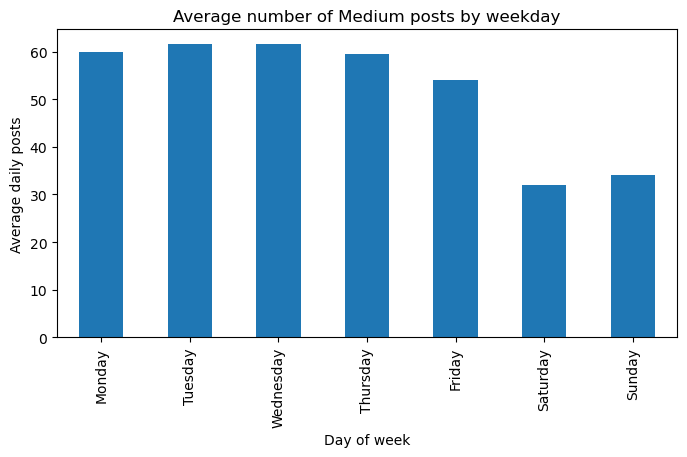

In [24]:
weekday_effect.plot(
    kind="bar",
    title="Average number of Medium posts by weekday",
    ylabel="Average daily posts",
    xlabel="Day of week",
    figsize=(8, 4),
);

The weekday analysis reveals a clear difference in publishing activity across the week.

The average number of recorded posts is highest from Tuesday to Thursday and substantially lower during the weekend. In particular, Saturday and Sunday have roughly half the average daily activity observed on the busiest weekdays.

This pattern suggests that weekly calendar effects may contribute to the short-term fluctuations observed in the daily series. Prophet can explicitly model this type of recurring seasonal behavior through its weekly seasonality component.

However, these averages are computed over the entire study period, during which Medium activity increased substantially. Therefore, they should be interpreted as exploratory evidence of weekly patterns rather than a final estimate of the seasonal effect.

### Monthly aggregation for long-term visualization

Daily observations contain substantial short-term variation. To better understand the long-term evolution of the series, we aggregate the daily counts into monthly totals.

This aggregation is used only for exploratory analysis and visualization. The original daily series will be preserved for forecasting.

In [25]:
monthly_df = (
    daily_df
    .resample("MS")
    ["posts"]
    .sum()
)

display(monthly_df.head())

published
2012-08-01    39
2012-09-01    10
2012-10-01    12
2012-11-01    29
2012-12-01    17
Freq: MS, Name: posts, dtype: int64

In [26]:
plotly_df(
    monthly_df.to_frame(),
    title="Monthly number of Medium posts"
)

The monthly aggregation makes the long-term evolution of the series easier to interpret.

The dominant feature is a strong increasing trend, with the monthly number of recorded posts growing substantially throughout the study period. The growth rate also appears to accelerate over time, indicating that the trend is not simply linear.

While some month-to-month fluctuations are present, no clear yearly seasonal pattern is immediately visible from this visualization. Weekly seasonality showed a clearer calendar effect, which Prophet can model explicitly.

Overall, the exploratory analysis suggests that this forecasting problem contains a strong trend component, possible weekly seasonality, and changing variability over time.

### 3.4 Preparing the data for Prophet

Prophet requires the input data to contain two columns:

- `ds`: the timestamp column;
- `y`: the numeric target value to forecast.

Our validated daily series currently contains the number of retained Medium posts per day. We now convert it into Prophet's required format.

The original daily series is preserved, and a separate dataframe is created for modeling.

In [27]:
from prophet import Prophet

import logging

logging.getLogger().setLevel(logging.ERROR) # it means that we are setting the logging level to ERROR, which means that only error messages will be displayed. This is useful for suppressing less severe log messages (like warnings or informational messages) that might clutter the output when running the Prophet model.

In [28]:
daily_df

,posts
published,
2012-08-15,16
2012-08-16,11
2012-08-17,4
2012-08-18,2
2012-08-19,1
...,...
2017-06-22,441
2017-06-23,421
2017-06-24,277


In [29]:
daily_df.reset_index()

,published,posts
0,2012-08-15,16
1,2012-08-16,11
2,2012-08-17,4
3,2012-08-18,2
4,2012-08-19,1
...,...,...
1772,2017-06-22,441
1773,2017-06-23,421
1774,2017-06-24,277
1775,2017-06-25,253


In [30]:
prophet_df = (
    daily_df
    .reset_index() 
    .rename(
        columns={
            "published": "ds",
            "posts": "y",
        }
    )
)

display(prophet_df.head())
display(prophet_df.tail())

,ds,y
0,2012-08-15,16
1,2012-08-16,11
2,2012-08-17,4
3,2012-08-18,2
4,2012-08-19,1


,ds,y
1772,2017-06-22,441
1773,2017-06-23,421
1774,2017-06-24,277
1775,2017-06-25,253
1776,2017-06-26,207


Before training the model, we split the series chronologically into a training period and a held-out evaluation period.

The model will be fitted only on the historical portion of the data. The final 30 days are reserved as the held-out evaluation period, allowing us to evaluate how well Prophet predicts future observations.

This mimics a real forecasting scenario, where future values are not available at training time.

In [31]:
prediction_size = 30

train_df = prophet_df.iloc[:-prediction_size].copy()
test_df = prophet_df.iloc[-prediction_size:].copy()

print("Training period:")
print(train_df["ds"].min(), "to", train_df["ds"].max())

print("\nHeld-out evaluation period:")
print(test_df["ds"].min(), "to", test_df["ds"].max())

Training period:
2012-08-15 00:00:00 to 2017-05-27 00:00:00

Held-out evaluation period:
2017-05-28 00:00:00 to 2017-06-26 00:00:00


### Fitting the Prophet model

We first fit a baseline Prophet model using the default configuration.

Prophet will automatically estimate:

- the trend component;
- weekly seasonality;
- yearly seasonality;
- uncertainty intervals.

The goal at this stage is to establish a baseline model before considering any additional tuning.


>The default seasonal components are appropriate for this daily forecasting problem. Additional seasonalities, such as a monthly component, can be added if exploratory analysis and validation indicate that they improve forecasting performance.

<span style="font-size:24px; color:hotpink;">

Prophet does not have a built-in "monthly seasonality" component by default.

</span>

In [32]:
m = Prophet()

m.fit(train_df)

16:51:54 - cmdstanpy - INFO - Chain [1] start processing
16:51:54 - cmdstanpy - INFO - Chain [1] done processing


<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

Yes. This is a very good question, because

```python
m = Prophet()
m.fit(train_df)
```

looks almost trivial, but mathematically quite a lot happens underneath.

The key idea is that Prophet assumes your observed series can be decomposed approximately as

$$
\boxed{
y(t)=g(t)+s(t)+h(t)+\varepsilon_t
}
$$

where

$$
g(t)=\text{trend}
$$

$$
s(t)=\text{seasonality}
$$

$$
h(t)=\text{holiday/event effects}
$$

and

$$
\varepsilon_t=\text{unexplained noise}.
$$

In your Medium-post example you didn't supply holidays, so effectively it was closer to

$$
\boxed{
y(t)=g(t)+s_{\text{weekly}}(t)+s_{\text{yearly}}(t)+\varepsilon_t.
}
$$

For your daily dataset covering several years, weekly and yearly seasonalities are natural default Prophet components.

## 1. `m = Prophet()` does not fit anything yet

When you write

```python
m = Prophet()
```

you are essentially saying:

> Create a model having Prophet's default mathematical structure and default priors.

By default the trend is **piecewise linear**.

A simple linear trend would just be

$$
g(t)=kt+m
$$

where

* $k$ = slope
* $m$ = intercept.

But Prophet doesn't assume the same slope forever.

Instead, it introduces possible **changepoints**.

Suppose there are changepoints

$$
s_1,s_2,\dots,s_S.
$$

At each changepoint, the slope is allowed to change by some amount

$$
\delta_j.
$$

Define

$$
a_j(t)=
\begin{cases}
1 & t\ge s_j\\
0 & t<s_j.
\end{cases}
$$

Then the effective slope at time $t$ becomes roughly

$$
k+\sum_{j=1}^{S}a_j(t)\delta_j.
$$

In vector notation,

$$
k+\mathbf a(t)^T\boldsymbol\delta.
$$

So Prophet's trend is conceptually:

$$
\boxed{
\text{initial slope}
+
\text{slope changes activated after changepoints}.
}
$$

This is why the trend can bend rather than being one straight regression line.

## 2. Prophet has to make the trend continuous

There is a subtle mathematical issue.

Imagine the slope suddenly changes at some changepoint $s_j$.

If we simply changed the slope from $k$ to $k+\delta_j$, the line could jump vertically.

Prophet doesn't want that.

So it also adjusts the intercept at each changepoint.

The actual piecewise-linear formulation can be written as

$$
\boxed{
g(t)
=
\left(k+\mathbf a(t)^T\boldsymbol\delta\right)t
+
\left(m+\mathbf a(t)^T\boldsymbol\gamma\right)
}
$$

where $\boldsymbol\gamma$ contains intercept adjustments chosen so that the pieces connect continuously.

So visually:

$$
\text{line}_1
\longrightarrow
\text{line}_2
\longrightarrow
\text{line}_3
$$

may have different slopes, but there are no artificial jumps between them.

This is what you saw in your Prophet trend component: a smooth continuous trend whose **slope changes at certain locations**.

It is not an exponential curve. It is essentially several linear segments connected together.

# 3. But Prophet doesn't want every changepoint to matter

This part is especially important.

If Prophet allowed every possible slope change to be large, it could massively overfit.

So Prophet regularizes the slope changes:

$$
\delta_j \sim \operatorname{Laplace}(0,\tau).
$$

The Laplace distribution is sharply concentrated around zero.

Conceptually, this says:

> Most slope changes should be close to zero unless the data provide enough evidence that a real change is needed.

This is analogous to **L1 regularization / Lasso**.

Remember Lasso?

$$
\min_\beta
\left[
\text{error}
+
\lambda\sum_j|\beta_j|
\right].
$$

Prophet's changepoint regularization has very similar behavior.

Small $\delta_j$'s tend to be pushed toward zero.

That means Prophet might start with many candidate changepoints but effectively use only some of them strongly.

And this is connected to:

```python
changepoint_prior_scale
```

A larger value means:

$$
\text{less shrinkage}
\Rightarrow
\text{more flexible trend}
$$

while a smaller value means:

$$
\text{more shrinkage}
\Rightarrow
\text{smoother trend}.
$$

# 4. Then comes seasonality

This is one of the nicest mathematical parts of Prophet.

Prophet represents seasonality using a **Fourier series**.

Suppose we have a seasonal pattern with period $P$.

For weekly seasonality on daily observations,

$$
P=7.
$$

Prophet represents the seasonal component approximately as

$$
s(t)
=
\sum_{n=1}^{N}
\left[
a_n
\cos\left(\frac{2\pi nt}{P}\right)
+
b_n
\sin\left(\frac{2\pi nt}{P}\right)
\right].
$$

So it builds features like

$$
\sin\left(\frac{2\pi t}{7}\right),
\qquad
\cos\left(\frac{2\pi t}{7}\right),
$$

then

$$
\sin\left(\frac{4\pi t}{7}\right),
\qquad
\cos\left(\frac{4\pi t}{7}\right),
$$

and so on.

Why use several sine/cosine waves?

Because one sine wave can only produce something simple like:

$$
\sim\sim\sim\sim
$$

but combining several harmonics can produce a much richer shape.

For example, instead of forcing:

$$
\text{Monday}
<
\text{Tuesday}
<
\text{Wednesday}
$$

into a simple sinusoid, multiple Fourier terms let Prophet learn an irregular weekly pattern.

That is why your weekly component could say approximately:

$$
\text{Tue/Wed high}
$$

$$
\text{Mon/Thu moderately high}
$$

$$
\text{Sat/Sun strongly low}.
$$

It is the **sum of Fourier basis functions** producing that curve.

# 5. Mathematically this starts looking like regression

This is one of the useful insights.

Suppose Prophet constructs Fourier features

$$
X_1(t),X_2(t),\dots,X_p(t).
$$

Then seasonality can be written much more compactly:

$$
\boxed{
s(t)=\mathbf X(t)\boldsymbol\beta.
}
$$

That's basically regression.

You have

$$
\begin{bmatrix}
\sin(\cdots) &
\cos(\cdots) &
\sin(\cdots) &
\cos(\cdots)
\end{bmatrix}
$$

as features, and Prophet learns coefficients

$$
\beta_1,\beta_2,\ldots,\beta_p.
$$

So underneath Prophet, a big part of seasonality is essentially:

$$
\boxed{\text{feature engineering with Fourier bases + regularized regression}.}
$$

That should feel quite familiar after your Part 1 work.

# 6. Prophet can do the same thing for yearly seasonality

For yearly seasonality,

$$
P\approx365.25\text{ days}.
$$

So features look like

$$
\sin\left(\frac{2\pi t}{365.25}\right),
\quad
\cos\left(\frac{2\pi t}{365.25}\right),
$$

along with higher harmonics:

$$
\sin\left(\frac{4\pi t}{365.25}\right),
\quad
\cos\left(\frac{4\pi t}{365.25}\right),
$$

etc.

Those coefficients combine to produce the yearly curve you saw in

```python
m.plot_components(forecast)
```

So Prophet isn't literally saying:

> May = +11.

Instead it estimates Fourier coefficients, and when those sine/cosine terms are evaluated around May, their sum might produce approximately

$$
s_{\text{yearly}}(t)\approx +11.
$$

# 7. Then Prophet assumes observation noise

After trend and seasonality are added together, actual observations won't land exactly on the model.

So Prophet assumes approximately

$$
y_t
=
g(t)+s(t)+h(t)+\epsilon_t
$$

with

$$
\epsilon_t\sim N(0,\sigma^2).
$$

Therefore,

$$
\boxed{
y_t
\sim
N\left(
g(t)+s(t)+h(t),
\sigma^2
\right).
}
$$

The model tries to learn $\sigma$ as well.

Conceptually:

$$
\text{prediction}
=
\text{structured signal}
+
\text{random residual variation}.
$$

# 8. Now we finally arrive at `.fit(train_df)`

When you execute

```python
m.fit(train_df)
```

Prophet gets observations

$$
(t_1,y_1),
(t_2,y_2),
\dots,
(t_n,y_n).
$$

It transforms the dates into its internal time representation and constructs the model matrix containing things such as:

$$
\text{time}
$$

$$
\text{changepoint indicators}
$$

$$
\text{weekly Fourier features}
$$

$$
\text{yearly Fourier features}.
$$

Then it needs to estimate parameters such as

$$
k,\quad m,\quad
\delta_1,\ldots,\delta_S,\quad
\beta_1,\ldots,\beta_p,\quad
\sigma.
$$

So conceptually `.fit()` means:

$$
\boxed{
\text{Find parameter values that make the observed training data likely,
while respecting Prophet's regularizing priors.}
}
$$

# 9. This is not ordinary least squares

There is a Bayesian flavor here.

Prophet specifies priors such as

$$
\delta_j\sim\operatorname{Laplace}(0,\tau)
$$

for changepoint adjustments, and typically Gaussian-type priors for seasonal coefficients.

Bayes' rule says

$$
p(\theta\mid y)
\propto
p(y\mid\theta)p(\theta),
$$

where

$$
\theta
=
(k,m,\boldsymbol\delta,\boldsymbol\beta,\sigma,\ldots).
$$

The first term,

$$
p(y\mid\theta),
$$

asks:

> How well do these parameter values explain the observations?

The second,

$$
p(\theta),
$$

asks:

> How plausible are these parameters according to the priors?

With Prophet's default fitting behavior, it does **not** normally perform full MCMC Bayesian posterior sampling.

Instead, it finds approximately a **MAP estimate**:

$$
\boxed{
\hat\theta_{\text{MAP}}
=
\arg\max_\theta
p(\theta\mid y)
}
$$

or equivalently,

$$
\hat\theta_{\text{MAP}}
=
\arg\min_\theta
\left[
-\log p(y\mid\theta)
-\log p(\theta)
\right].
$$

So there is a very direct connection to regularized machine learning:

$$
\boxed{
\text{fit to data}
+
\text{penalty/priors controlling complexity}.
}
$$

# 10. You can think of the whole fitting problem approximately like this

Prophet is trying to find:

$$
k,m,\boldsymbol\delta,\boldsymbol\beta
$$

such that

$$
y_t
\approx
g(t)+X(t)\beta
$$

while avoiding unnecessarily complicated trends and seasonalities.

Very loosely:

$$
\boxed{
\min
\left[
\sum_t
\left(
y_t-\hat y_t
\right)^2
+
\lambda_1\sum_j|\delta_j|
+
\lambda_2\sum_k\beta_k^2
\right]
}
$$

This is not the literal complete Prophet objective, but it's an excellent mental model.

It says:

$$
\text{prediction error}
+
\text{trend-complexity penalty}
+
\text{seasonality-complexity penalty}.
$$

# 11. A tiny conceptual example

Imagine these observed values:

$$
100,\;103,\;105,\;107,\;110,\;108,\;104,\ldots
$$

Prophet might learn:

### Trend

$$
g(t)\approx100+1.5t
$$

initially, but later detect a slope change:

$$
1.5\rightarrow2.1.
$$

### Weekly seasonality

Suppose weekends tend to have lower values:

$$
s(\text{Mon})=+5
$$

$$
s(\text{Tue})=+8
$$

$$
\cdots
$$

$$
s(\text{Sat})=-15
$$

$$
s(\text{Sun})=-17.
$$

Then on a Saturday where the underlying trend is

$$
g(t)=200,
$$

Prophet might predict

$$
\hat y_t
=
200-15
=
185.
$$

Add other seasonal terms and effects and you get the final

```python
yhat
```

# 12. Then when you later call `predict()`

Suppose you subsequently write

```python
future = m.make_future_dataframe(periods=30)

forecast = m.predict(future)
```

the main point is that **the learned parameters are no longer being refit**.

Prophet evaluates the learned mathematical functions at new times.

For some future $t^*$,

$$
\hat y(t^*)
=
\hat g(t^*)
+
\hat s(t^*)
+
\hat h(t^*).
$$

For weekly seasonality, it knows the date and therefore computes the corresponding Fourier values.

For trend, it extrapolates the final piecewise-linear trajectory.

So:

```python
fit()
```

means

$$
\boxed{\text{learn the parameters}}
$$

whereas

```python
predict()
```

means

$$
\boxed{\text{plug new times into the learned functions}}.
$$


## The most useful mental picture

I would think about default Prophet as roughly:

$$
\boxed{
\text{Piecewise-linear regression}
+
\text{Fourier regression}
+
\text{regularization}
+
\text{probabilistic noise model}
}
$$

rather than thinking of Prophet as some mysterious forecasting algorithm.

And actually, after everything you learned in Part 1, most of the pieces should now look familiar:

$$
\text{trend modeling}
$$

*

$$
\text{basis-function feature engineering}
$$

*

$$
\text{regularized parameter estimation}
$$

*

$$
\text{forecast extrapolation}.
$$

The mathematically most interesting next thing to unpack would probably be **exactly how Prophet constructs the piecewise-linear trend with changepoints**, because we can derive the formula for $\gamma_j=-s_j\delta_j$ and literally prove why it keeps the trend continuous.

----

**Not supplying holidays does not make your Prophet model wrong**.

It just means your model was:

$$
y(t)=g(t)+s(t)+\varepsilon_t
$$

instead of

$$
y(t)=g(t)+s(t)+h(t)+\varepsilon_t.
$$

So you simply chose **not to include an explicit holiday/event component**.

That is perfectly valid when holidays are not clearly relevant to the target.

For your Medium-post dataset, the target was the **number of posts published per day**. The key question is:

> Do specific holidays create systematic, repeated changes in posting volume that are strong enough and stable enough to model explicitly?

We did not have evidence for that.

Prophet does **not require holidays**. Holidays are optional regressors/components. You add them only when there is a defensible reason.

For example, suppose you had an e-commerce sales series. Then events like:

$$
\text{Black Friday}
$$

$$
\text{Christmas}
$$

$$
\text{New Year's Day}
$$

might have large, repeatable effects. In that setting, omitting them could leave predictable structure in the residuals.

But for Medium publication counts, it's much less obvious that something like Christmas should have a consistent effect across years.

There is another subtle point: your yearly seasonality can already capture some recurring calendar behavior.

Suppose publishing tends to decrease around late December every year. Even without a holiday table, Prophet's yearly Fourier component might learn something like

$$
s_{\text{yearly}}(\text{late December})<0.
$$

But that is different from explicitly modeling Christmas.

Yearly seasonality says:

> “There tends to be a recurring pattern around this part of the year.”

A holiday regressor says:

> “This particular named event produces an effect on this day, perhaps with a window around it.”

So the two can overlap somewhat, but they represent different ideas.

For example, with holidays you might specify Christmas and allow:

$$
h(t)=\beta_{\text{Christmas}}
$$

on December 25, perhaps also December 24–26.

Without holiday regressors, Prophet instead has to absorb any recurring December behavior through yearly seasonality or residual noise.

### Why we were right not to automatically add holidays

This connects directly to the methodological discipline you used throughout Part 2.

We didn't want to say:

> Prophet supports holidays, therefore let's add holidays.

That would be adding complexity because the library offers it rather than because the data justify it.

We would first want evidence such as:

* obvious recurring spikes/drops around particular holidays;
* residual structure concentrated around those dates;
* domain knowledge suggesting publication behavior should change;
* improvement under rolling-origin evaluation when the holiday component is added.

Then we could compare:

$$
M_0:
\quad
y(t)=g(t)+s(t)+\varepsilon_t
$$

against

$$
M_1:
\quad
y(t)=g(t)+s(t)+h(t)+\varepsilon_t
$$

using the **same rolling-origin folds**.

If $M_1$ consistently improved out-of-sample forecasting, then holidays would earn their place.

If not, we would leave them out.

So the principle is:

$$
\boxed{\text{Optional component missing} \neq \text{incomplete model}}
$$

Rather:

$$
\boxed{
\text{Include a component only when its assumptions and predictive value are justified.}
}
$$

In fact, blindly adding every available Prophet component would arguably make the analysis **less** rigorous, not more.

</details>

The Prophet model has now been trained using only the historical training period.

During fitting, Prophet estimated the parameters describing the underlying structure of the series, including:

- the long-term trend component;
- recurring seasonal patterns (weekly and yearly).

When generating forecasts, Prophet also produces uncertainty intervals associated with its predictions, which are available in the forecast output.

However, fitting the model only learns these patterns from historical data. The next step is to use the fitted model to generate predictions for future dates.

To evaluate the baseline forecasting performance, we reserve the final 30 days of the series as the held-out evaluation period.

The model is trained only on the earlier observations and then used to forecast this held-out evaluation period. The predicted values are compared with the actual observations to measure how well Prophet generalizes to future dates.

At this stage, we focus on establishing a baseline model rather than performing extensive model selection. Therefore, a separate validation set is not introduced yet. If additional model tuning or comparison between different configurations is performed later, a validation strategy would be appropriate.

> The uncertainty intervals (`yhat_lower`, `yhat_upper`) are generated when you call: `forecast = m.predict(future)`.So, Prophet estimates uncertainty intervals when generating forecasts.

**Next: Generating predictions from the fitted model.**

<details>
<summary><span style="color:red"> 

More on Prophet uncertainty intervals:

</span></summary>

Prophet’s uncertainty intervals are generated by **simulating many plausible future outcomes**, rather than by taking something simple like

$$
\hat y \pm 1.96\,SE.
$$

For the default Prophet model, the forecast is approximately

$$
y(t)=g(t)+s(t)+h(t)+\varepsilon_t.
$$

The uncertainty around future $y(t)$ mainly comes from two sources by default:

$$
\boxed{\text{future trend uncertainty}+\text{observation noise}}
$$

and, if you enable full Bayesian sampling, also from uncertainty in the seasonal coefficients.

### 1. Observation noise

Prophet assumes residual noise approximately like

$$
\varepsilon_t\sim N(0,\sigma_{\text{obs}}^2).
$$

During fitting, it estimates $\sigma_{\text{obs}}$.

So even if Prophet somehow knew the future trend and seasonality perfectly, it would still say:

$$
y_{t+h}
=
\hat y_{t+h}
+
\varepsilon_{t+h}.
$$

Different simulated future paths therefore receive different random residuals.

### 2. The more interesting part: future trend uncertainty

Recall Prophet's piecewise-linear trend:

$$
g(t)
=
\left(k+\mathbf a(t)^T\boldsymbol\delta\right)t
+
\left(m+\mathbf a(t)^T\boldsymbol\gamma\right).
$$

Here the $\delta_j$'s are historical slope changes at changepoints.

Suppose Prophet learned historically that the slope sometimes changes by amounts such as

$$
\delta_1,\delta_2,\ldots,\delta_S.
$$

When forecasting beyond the observed data, Prophet obviously cannot know:

> Will another changepoint happen next month?

or

> How large will the slope change be?

So it makes an assumption:

$$
\boxed{
\text{future trend changes will occur with approximately the same
frequency and magnitude as historical trend changes.}
}
$$

Then it **simulates possible future changepoints**.

One simulated future trend might look like

$$
g^{(1)}(t)
$$

with almost no future slope change.

Another might be

$$
g^{(2)}(t)
$$

with a positive slope change.

Another:

$$
g^{(3)}(t)
$$

with a negative change.

And so on.

Therefore, far into the future, those trajectories spread apart:

$$
g^{(1)}(t),\quad
g^{(2)}(t),\quad
\ldots,\quad
g^{(M)}(t).
$$

This is why Prophet's intervals generally widen as the forecast horizon grows.

### 3. It generates many simulated forecasts

Conceptually, for simulation $m$,

$$
y^{(m)}(t)
=
g^{(m)}(t)
+
s(t)
+
h(t)
+
\varepsilon_t^{(m)}.
$$

Do this many times:

$$
y^{(1)}(t),
y^{(2)}(t),
\dots,
y^{(M)}(t).
$$

Now Prophet has an empirical distribution of plausible predictions for each future date.

For example, imagine that at one future day it gets:

$$
181,\;187,\;190,\;193,\;196,\;201,\;205,\ldots
$$

Then it can take quantiles of that distribution.

### 4. `interval_width=0.80`

By default:

```python
m = Prophet()
```

uses approximately

```python
interval_width=0.8
```

So Prophet takes roughly the:

$$
10\text{th percentile}
$$

and

$$
90\text{th percentile}
$$

of its simulated predictive distribution.

Thus:

```python
forecast["yhat_lower"]
```

is approximately

$$
Q_{0.10}
$$

and

```python
forecast["yhat_upper"]
```

is approximately

$$
Q_{0.90}.
$$

Together these form the nominal **80% uncertainty interval**.

So if:

```text
yhat       = 210
yhat_lower = 170
yhat_upper = 250
```

Prophet is essentially giving you:

$$
\hat y=210
$$

with a nominal 80% predictive uncertainty range of

$$
[170,250].
$$


<details>
<summary><span style="color:red"> 

nominal vs empirical

</span></summary>

Here, **nominal** means:

> **the interval is designed or labeled to have 80% coverage according to the model’s assumptions**.

So when Prophet gives a **nominal 80% uncertainty interval**, it means:

$$
\boxed{\text{The model aims for about $80\%$ of future observations to fall inside the interval.}}
$$

It does **not** mean that you have already verified that 80% actually do.

That verified quantity is called **empirical coverage**.

For example, suppose you have 100 future observations and an 80% nominal interval.

The model's intended target is:

$$
80 \text{ out of } 100
$$

inside the interval.

But after testing, maybe you observe:

$$
73 \text{ out of } 100.
$$

Then:

$$
\text{nominal coverage}=80\%
$$

but

$$
\text{empirical coverage}=73\%.
$$

Or maybe you observe 91 out of 100:

$$
\text{empirical coverage}=91\%.
$$

So:

$$
\boxed{
\text{nominal} = \text{what the interval is supposed to represent}
}
$$

whereas

$$
\boxed{
\text{empirical} = \text{what actually happened on held-out data}
}
$$

That distinction was important in your Prophet notebook because you had a nominal 80% interval, but in one held-out run the observed coverage was 90%.

That does **not** turn it into a “90% interval.” It remains an 80% nominal interval whose empirical coverage on that particular sample happened to be 90%.

</details>

## But here's an important subtlety

With the default:

```python
m = Prophet()
```

Prophet usually performs a **MAP fit**, not full posterior MCMC sampling.

That means the fitted seasonality coefficients such as

$$
\beta_1,\beta_2,\ldots
$$

are essentially treated as fixed at their estimated values when producing the default uncertainty.

So, approximately:

$$
\boxed{
\text{Default uncertainty}
=
\text{trend uncertainty}
+
\text{observation noise}
}
$$

rather than

$$
\text{uncertainty about absolutely every model parameter}.
$$

If you instead use something like

```python
m = Prophet(mcmc_samples=300)
```

Prophet performs full Bayesian posterior sampling.

Then you can also propagate uncertainty in things such as the seasonal coefficients:

$$
\boldsymbol\beta
$$

through the forecast.

Conceptually that becomes:

$$
y^{(m)}(t)
=
g^{(m)}(t)
+
s^{(m)}(t)
+
h^{(m)}(t)
+
\varepsilon^{(m)}_t.
$$

That's a much more fully Bayesian treatment.

## Why `changepoint_prior_scale` affects interval width

There's a very interesting consequence.

Suppose you increase:

```python
changepoint_prior_scale
```

Then Prophet permits larger historical slope changes:

$$
|\delta_j| \uparrow.
$$

But Prophet uses the historical trend changes as evidence about what future changes might look like.

Therefore:

$$
\text{larger historical allowed changes}
$$

lead to

$$
\text{larger simulated future trend changes}
$$

which usually lead to

$$
\boxed{\text{wider forecast uncertainty intervals}.}
$$

So excessive trend flexibility can produce both overfitting **and** very wide future uncertainty.

## Relating this directly to your Part 2 notebook

This is exactly why we were careful to call these:

> **Prophet uncertainty intervals**

rather than automatically calling them classical 80% confidence intervals.

And why you actually checked **empirical coverage**.

If the nominal interval is 80%, then ideally, across genuinely unseen observations,

$$
P(y_t\in[L_t,U_t])\approx0.80.
$$

You computed something like

$$
\text{coverage}
=
\frac{
\#\{t:y_t\in[yhat\_lower_t,yhat\_upper_t]\}
}{
N
}.
$$

That is much more informative than simply trusting the label “80%”.

In your final Box–Cox Prophet run, for example, the held-out 30-day coverage happened to be

$$
\frac{27}{30}=90\%
$$

in that execution.

That did **not** mean Prophet had a perfectly calibrated 90% interval. The nominal interval was still 80%; you observed 90% empirical coverage on one small 30-day evaluation window.

### The compact mental model

Think of Prophet doing this:

$$
\boxed{
\begin{array}{c}
\text{Fit trend + seasonal structure}\\
\downarrow\\
\text{Imagine many plausible future trend changes}\\
\downarrow\\
\text{Add random observation noise}\\
\downarrow\\
\text{Generate many possible future }y\text{'s}\\
\downarrow\\
\text{Take quantiles}\\
\downarrow\\
[yhat\_lower,\;yhat\_upper]
\end{array}
}
$$

The most important assumption underneath all of this is:

$$
\boxed{
\text{Future trend changes behave roughly like historical trend changes.}
}
$$

That assumption—not a magical universal probability guarantee—is what gives Prophet much of its future trend uncertainty.

</details>

### Generating the forecast

After fitting the model, we use it to generate predictions for the required dates.

Prophet's `make_future_dataframe()` method creates a dataframe containing:

- all historical dates used during training;
- additional future dates for which forecasts are required.

Including the historical dates allows Prophet to return both:

- fitted values for the training period;
- forecasts for the held-out evaluation period.

The final 30 days correspond to the held-out evaluation period defined earlier.

In [33]:
future = m.make_future_dataframe(
    periods=prediction_size,
    freq="D",
)

forecast = m.predict(future)

display(
    forecast.tail()
)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1772,2017-06-22,240.336743,225.748088,271.498754,240.206570,240.430890,9.155984,9.155984,9.155984,6.988410,6.988410,6.988410,2.167573,2.167573,2.167573,0.0,0.0,0.0,249.492727
1773,2017-06-23,240.770308,220.974757,269.719163,240.612274,240.871887,3.988735,3.988735,3.988735,1.754500,1.754500,1.754500,2.234234,2.234234,2.234234,0.0,0.0,0.0,244.759042
1774,2017-06-24,241.203872,201.174809,248.859651,241.025619,241.315883,-16.122463,-16.122463,-16.122463,-18.415178,-18.415178,-18.415178,2.292715,2.292715,2.292715,0.0,0.0,0.0,225.081409
1775,2017-06-25,241.637437,206.264755,251.193143,241.444028,241.759485,-14.159100,-14.159100,-14.159100,-16.498946,-16.498946,-16.498946,2.339846,2.339846,2.339846,0.0,0.0,0.0,227.478337
1776,2017-06-26,242.071002,229.824491,274.240612,241.851660,242.204548,9.915048,9.915048,9.915048,7.542215,7.542215,7.542215,2.372833,2.372833,2.372833,0.0,0.0,0.0,251.986050


<details>
<summary><span style="color:red"> 

more on this:

</span></summary>

The easiest way to read this table is to remember Prophet’s additive model:

$$
\boxed{\hat y(t)=g(t)+s(t)}
$$

and in your case,

$$
\boxed{
\hat y(t)
=
g(t)
+
s_{\text{weekly}}(t)
+
s_{\text{yearly}}(t)
}
$$

because you did not add holidays or extra regressors, and your seasonalities are additive.

For example, on **2017-06-22**:

$$
240.336743+6.988410+2.167573
=
249.492726
$$

which is exactly your:

$$
\texttt{yhat}=249.492727.
$$

Here is what each column means.

| Column                             | Meaning                                        | Mathematical interpretation                          |
| ---------------------------------- | ---------------------------------------------- | ---------------------------------------------------- |
| `ds`                               | Date/time being predicted                      | $t$                                                |
| `trend`                            | Estimated underlying trend                     | $g(t)$                                             |
| `weekly`                           | Weekly seasonal contribution                   | $s_{\text{weekly}}(t)$                             |
| `yearly`                           | Yearly seasonal contribution                   | $s_{\text{yearly}}(t)$                             |
| `additive_terms`                   | Sum of all additive components                 | $s_{\text{weekly}}(t)+s_{\text{yearly}}(t)+\cdots$ |
| `multiplicative_terms`             | Multiplicative seasonal/regressor contribution | $m(t)$                                             |
| `yhat`                             | Final point prediction                         | $g(t)(1+m(t))+\text{additive terms}$               |
| `trend_lower`                      | Lower simulated bound for trend                | lower quantile of possible $g(t)$                  |
| `trend_upper`                      | Upper simulated bound for trend                | upper quantile of possible $g(t)$                  |
| `yhat_lower`                       | Lower uncertainty bound for prediction         | lower predictive quantile of $y(t)$                |
| `yhat_upper`                       | Upper uncertainty bound for prediction         | upper predictive quantile of $y(t)$                |
| `weekly_lower/upper`               | Bounds for weekly component                    | uncertainty bounds for $s_{\text{weekly}}(t)$      |
| `yearly_lower/upper`               | Bounds for yearly component                    | uncertainty bounds for $s_{\text{yearly}}(t)$      |
| `additive_terms_lower/upper`       | Bounds around total additive contribution      | bounds for $s(t)$                                  |
| `multiplicative_terms_lower/upper` | Bounds around multiplicative contribution      | bounds for $m(t)$                                  |

### `trend`

For June 22:

```text
trend = 240.336743
```

This means Prophet's piecewise-linear trend says:

$$
g(t)\approx240.34
$$

posts/day before weekly/yearly effects are added.

This is the long-term level Prophet thinks the series has reached.

### `weekly`

For June 22:

```text
weekly = 6.988410
```

So that particular weekday contributes approximately

$$
+6.99
$$

posts relative to the underlying trend.

On June 24:

```text
weekly = -18.415178
```

so the weekday effect pulls the prediction down by approximately

$$
18.42
$$

posts.

That is why weekends in your forecast are much lower.

Mathematically, remember that Prophet created this from Fourier terms:

$$
s_{\text{weekly}}(t)
=
\sum_{n=1}^{N}
\left[
a_n\cos\left(\frac{2\pi nt}{7}\right)
+
b_n\sin\left(\frac{2\pi nt}{7}\right)
\right].
$$

You don't see those individual Fourier coefficients here. You see their final sum.

### `yearly`

For June 22:

```text
yearly = 2.167573
```

meaning the time of year contributes roughly

$$
+2.17
$$

posts.

Again, underneath this is a Fourier series, now with yearly period:

$$
s_{\text{yearly}}(t)
=
\sum_{n=1}^{N}
\left[
a_n\cos\left(\frac{2\pi nt}{365.25}\right)
+
b_n\sin\left(\frac{2\pi nt}{365.25}\right)
\right].
$$

## `additive_terms`

This is especially simple in your model:

$$
\boxed{
\text{additive\_terms}
=
\text{weekly}
+
\text{yearly}
}
$$

For June 22:

$$
6.988410+2.167573
=
9.155983.
$$

And your table says:

```text
additive_terms = 9.155984
```

The tiny difference is just rounding.

For Saturday June 24:

$$
-18.415178+2.292715
=
-16.122463.
$$

Exactly what appears in `additive_terms`.

## `multiplicative_terms`

Yours is:

```text
0.0
```

because you are using additive seasonality.

In the general Prophet formula:

$$
\boxed{
\hat y(t)
=
g(t)\left[1+m(t)\right]
+
a(t)
}
$$

where

* $g(t)$ = trend
* $m(t)$ = multiplicative terms
* $a(t)$ = additive terms.

Since yours has

$$
m(t)=0,
$$

you get

$$
\hat y(t)
=
g(t)+a(t).
$$

So in your exact model:

$$
\boxed{
\hat y(t)
=
\text{trend}
+
\text{weekly}
+
\text{yearly}.
}
$$

# `yhat`

This is the actual Prophet point forecast.

For June 25:

$$
g(t)=241.637437
$$

$$
s_{\text{weekly}}(t)=-16.498946
$$

$$
s_{\text{yearly}}(t)=2.339846.
$$

Therefore:

$$
\hat y(t)
=
241.637437
-16.498946
+2.339846
$$

$$
=
227.478337.
$$

Exactly:

```text
yhat = 227.478337
```

So `yhat` really isn't mysterious at all.

It is literally Prophet assembling its estimated components.

# `trend_lower` and `trend_upper`

For June 26:

```text
trend       = 242.071002
trend_lower = 241.856655
trend_upper = 242.199077
```

So Prophet's central trend estimate is

$$
242.07,
$$

while its simulated future trend trajectories produce a range around that value.

Conceptually:

$$
g^{(1)}(t),g^{(2)}(t),\ldots,g^{(M)}(t)
$$

are simulated, and quantiles of those values give approximately:

$$
[\texttt{trend\_lower},\texttt{trend\_upper}].
$$

Notice this range is pretty narrow here because these dates aren't very far beyond the end of the training data.


# `yhat_lower` and `yhat_upper`

These are much wider.

For June 26:

```text
yhat       = 251.986050
yhat_lower = 230.111409
yhat_upper = 274.605778
```

Why is this much wider than the trend interval?

Because `yhat` uncertainty includes more than uncertainty about the trend. It also incorporates the model's expected unexplained observation variation.

Conceptually Prophet simulates:

$$
y^{(m)}(t)
=
g^{(m)}(t)
+
s(t)
+
\epsilon_t^{(m)}
$$

and then takes quantiles of all those simulated future $y$'s.

So:

$$
\boxed{
\texttt{trend\_lower/upper}
\neq
\texttt{yhat\_lower/upper}
}
$$

because the latter are uncertainty intervals for the **actual observation**, not merely the underlying trend.

## Why are `weekly_lower = weekly = weekly_upper`?

You may have noticed:

```text
weekly       = 6.988410
weekly_lower = 6.988410
weekly_upper = 6.988410
```

Same with `yearly`.

That's because with your default MAP fit, Prophet is effectively treating those fitted seasonal coefficients as fixed when producing its standard uncertainty simulation.

So it doesn't propagate substantial posterior uncertainty about

$$
\beta_{\text{weekly}}
$$

or

$$
\beta_{\text{yearly}}
$$

in the default fit.

Hence:

$$
s_{\text{weekly,lower}}(t)
=
s_{\text{weekly}}(t)
=
s_{\text{weekly,upper}}(t).
$$

If you ran full Bayesian estimation using `mcmc_samples`, you could get uncertainty in those seasonal components too.


## One final thing about `make_future_dataframe()`

When you did:

```python
future = m.make_future_dataframe(
    periods=prediction_size,
    freq="D",
)
```

Prophet did not create **only** the future dates.

By default it includes:

$$
\boxed{\text{historical training dates}+\text{new future dates}.}
$$

Then:

```python
forecast = m.predict(future)
```

generates all these columns for both the historical period and the newly added future period.

Because you displayed:

```python
forecast.tail()
```

you are seeing the **last five dates of the 30-day future period**, June 22–26.

So the central mathematical relationship to keep in your head when looking at this table is simply:

$$
\boxed{
\texttt{yhat}
=
\texttt{trend}
+
\texttt{weekly}
+
\texttt{yearly}
}
$$

for your particular Prophet model.

And around that central estimate, `yhat_lower` and `yhat_upper` represent the simulated predictive uncertainty.


</details>

In [34]:
future

,ds
0,2012-08-15
1,2012-08-16
2,2012-08-17
3,2012-08-18
4,2012-08-19
...,...
1772,2017-06-22
1773,2017-06-23
1774,2017-06-24
1775,2017-06-25


The resulting dataframe contains the model predictions and additional information about the estimated components.

The main forecast value is stored in the `yhat` column, while `yhat_lower` and `yhat_upper` represent the uncertainty interval around the prediction.

The dataframe also includes the estimated trend and seasonal components used to construct the forecast.

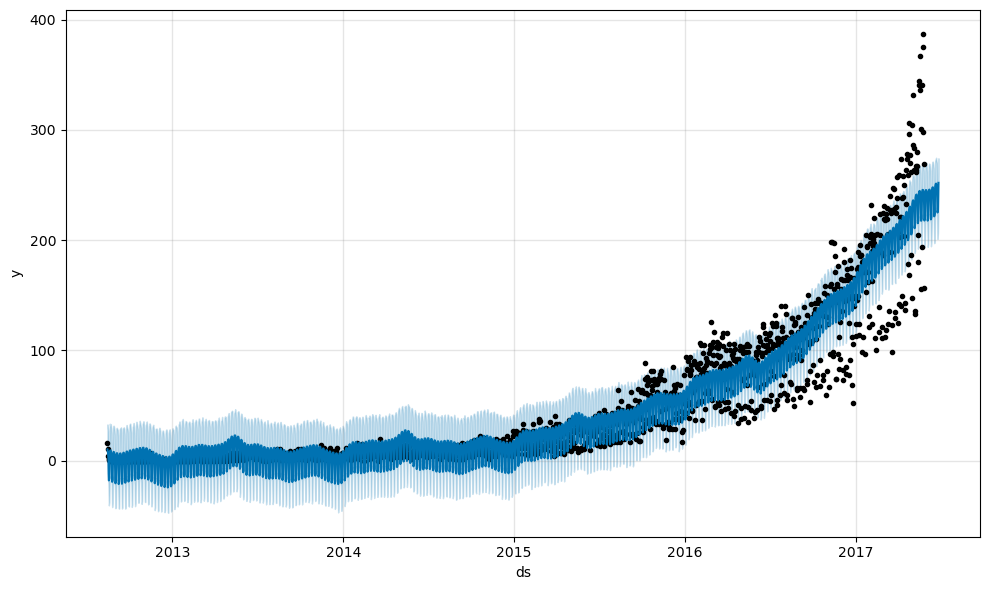

In [35]:
m.plot(forecast);

The forecast plot shows that Prophet captures the dominant upward trend of the series.

The model follows the long-term increase in Medium publishing activity, while the daily observations continue to fluctuate around the estimated trend. These short-term deviations represent variation that is not fully explained by the model components.

The uncertainty interval represents the range of possible values estimated by Prophet around its predictions. It provides information about the uncertainty associated with the model's forecasts.

Because Prophet's default additive model is not constrained to non-negative values, it can produce negative fitted values in the sparse early portion of this count series. These negative values do not occur in the held-out 30-day evaluation period and therefore do not affect the reported baseline MAE or RMSE, but they represent a limitation of the unconstrained baseline model for low-count observations.

Although this visualization provides insight into the model behavior, visual inspection alone is not sufficient to evaluate forecasting performance. We therefore compare the predictions on the held-out evaluation period with the actual observed values using quantitative metrics.

### 3.5 Forecast quality evaluation

To evaluate the baseline Prophet model, we compare the predictions for the held-out 30-day evaluation period with the actual observed values.

The forecast dataframe contains the model predictions, but not the original observations. Therefore, we combine the forecast output with the corresponding historical values.

The evaluation focuses only on the final 30 days that were not used during training.

In [36]:
def make_comparison_dataframe(historical, forecast):
    """
    Combine Prophet predictions with observed values.

    Returns a dataframe containing:
    - y: actual observations
    - yhat: predictions
    - yhat_lower/yhat_upper: uncertainty intervals
    """
    
    return (
        forecast
        .set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]]
        .join(
            historical.set_index("ds")[["y"]]
        )
    )

In [37]:
cmp_df = make_comparison_dataframe(
    prophet_df,
    forecast
)

display(cmp_df.tail())

,yhat,yhat_lower,yhat_upper,y
ds,,,,
2017-06-22,249.492727,225.748088,271.498754,441
2017-06-23,244.759042,220.974757,269.719163,421
2017-06-24,225.081409,201.174809,248.859651,277
2017-06-25,227.478337,206.264755,251.193143,253
2017-06-26,251.986050,229.824491,274.240612,207


The resulting dataframe contains both the actual values and Prophet's predictions, allowing direct comparison between observed and forecasted post counts.

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


test_cmp = cmp_df.tail(prediction_size) # selects the last `prediction_size` rows, i.e. our held-out forecast period.


mae = mean_absolute_error(
    test_cmp["y"],
    test_cmp["yhat"]
)

rmse = np.sqrt(
    mean_squared_error(
        test_cmp["y"],
        test_cmp["yhat"]
    )
)


print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 91.58
RMSE: 104.64


<details>
<summary><span style="color:red"> 
More on this:  
</span></summary>

```python
from sklearn.metrics import mean_absolute_error, mean_squared_error
```

imports two error metrics.

```python
test_cmp = cmp_df.tail(prediction_size)
```

selects the last `prediction_size` rows, i.e. our held-out forecast period.

Then:

```python
mae = mean_absolute_error(
    test_cmp["y"],
    test_cmp["yhat"]
)
```

computes

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat y_i|
$$

So MAE tells you the average absolute forecasting error in the original unit: here, roughly **number of posts per day**.

Then:

```python
rmse = np.sqrt(
    mean_squared_error(
        test_cmp["y"],
        test_cmp["yhat"]
    )
)
```

computes

$$
RMSE=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}(y_i-\hat y_i)^2
}
$$

RMSE penalizes large errors more strongly than MAE because the errors are squared first.

Finally:

```python
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
```

prints both metrics rounded to 2 decimal places.

So, very simply:

$$
\boxed{\text{MAE = typical absolute error}}
$$

$$
\boxed{\text{RMSE = error metric that punishes large misses more heavily}}
$$


</details>

The baseline model achieves the following errors on the held-out 30-day evaluation period:

- **MAE:** approximately **91.58 posts**
- **RMSE:** approximately **104.64 posts**

MAE measures the average absolute difference between the predicted and actual number of posts. In this case, the model's predictions differ from the observed values by about 92 posts per day on average.

RMSE gives more weight to larger forecasting errors, which makes it useful for identifying whether the model occasionally produces larger deviations.

These metrics provide an objective evaluation of forecast performance and are more reliable than visual inspection alone.

### 3.6 Visual inspection of forecast performance



In [39]:
forecast_plot_df = (
    cmp_df
    .tail(100)
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=forecast_plot_df.index,
        y=forecast_plot_df["y"],
        name="Actual"
    )
)

fig.add_trace(
    go.Scatter(
        x=forecast_plot_df.index,
        y=forecast_plot_df["yhat"],
        name="Forecast"
    )
)

fig.add_trace(
    go.Scatter(
        x=forecast_plot_df.index,
        y=forecast_plot_df["yhat_upper"],
        line=dict(width=0),
        showlegend=False
    )
)

fig.add_trace(
    go.Scatter(
        x=forecast_plot_df.index,
        y=forecast_plot_df["yhat_lower"],
        fill="tonexty",
        line=dict(width=0),
        name="Uncertainty interval"
    )
)

fig.update_layout(
    title="Prophet forecast vs actual observations",
    yaxis_title="Posts"
)

fig.show()

<details>
<summary><span style="color:red"> 

More on this cell: 

</span></summary>

This block makes a Plotly chart comparing the actual daily post counts with Prophet’s forecasts and its uncertainty interval for the **last 100 observations**.

```python
forecast_plot_df = (
    cmp_df
    .tail(100)
)
```

This simply selects the last 100 rows of `cmp_df`:

$$
\text{forecast\_plot\_df}
=
\text{last 100 observations}.
$$

So the chart is zoomed into the end of the series rather than plotting the entire dataset.

```python
fig = go.Figure()
```

creates an empty Plotly figure. Then you add several layers, called **traces**.

### Actual observations

```python
fig.add_trace(
    go.Scatter(
        x=forecast_plot_df.index,
        y=forecast_plot_df["y"],
        name="Actual"
    )
)
```

plots the true values:

$$
(t,\;y_t)
$$

where:

* $t$ = date
* $y_t$ = actual number of posts on that date.

So this is your observed time series.

### Prophet forecasts

```python
fig.add_trace(
    go.Scatter(
        x=forecast_plot_df.index,
        y=forecast_plot_df["yhat"],
        name="Forecast"
    )
)
```

plots Prophet's point predictions:

$$
(t,\;\hat y_t).
$$

For your additive Prophet model,

$$
\hat y_t
=
g(t)
+
s_{\text{weekly}}(t)
+
s_{\text{yearly}}(t).
$$

So visually you're comparing

$$
y_t
\quad\text{vs}\quad
\hat y_t.
$$

### Upper uncertainty boundary

```python
fig.add_trace(
    go.Scatter(
        x=forecast_plot_df.index,
        y=forecast_plot_df["yhat_upper"],
        line=dict(width=0),
        showlegend=False
    )
)
```

plots the upper uncertainty bound:

$$
U_t=\texttt{yhat\_upper}_t.
$$

But:

```python
line=dict(width=0)
```

makes the actual boundary line invisible.

This trace is mainly there so Plotly knows where the top of the shaded region should be.

### Lower uncertainty boundary

```python
fig.add_trace(
    go.Scatter(
        x=forecast_plot_df.index,
        y=forecast_plot_df["yhat_lower"],
        fill="tonexty",
        line=dict(width=0),
        name="Uncertainty interval"
    )
)
```

adds the lower boundary:

$$
L_t=\texttt{yhat\_lower}_t.
$$

The important part is:

```python
fill="tonexty"
```

which tells Plotly:

> Fill the area between this trace and the previous trace.

The previous trace was `yhat_upper`, so Plotly shades:

$$
\boxed{
L_t\le y_t\le U_t
}
$$

or visually:

$$
\boxed{
[\texttt{yhat\_lower},\texttt{yhat\_upper}]
}
$$

which is Prophet's nominal uncertainty interval.

### Labels

```python
fig.update_layout(
    title="Prophet forecast vs actual observations",
    yaxis_title="Posts"
)
```

just sets the title and labels the vertical axis.

Finally:

```python
fig.show()
```

renders the interactive Plotly graph.

So mathematically the chart contains three main things:

$$
\boxed{\text{Actual: } y_t}
$$

$$
\boxed{\text{Forecast: } \hat y_t}
$$

and

$$
\boxed{
\text{Uncertainty band: }
[L_t,U_t]
=
[\texttt{yhat\_lower}_t,\texttt{yhat\_upper}_t]
}
$$

The reason the last two uncertainty traces look a bit strange in code is simply that Plotly needs **two invisible boundary curves** in order to shade the region between them.


</details>

<details>
<summary><span style="color:red"> 
Why does the uncertainty interval in this Prophet forecast appear to have an almost constant width over time instead of widening as the forecast horizon increases?
</span></summary>

Exactly — and your plot is behaving this way for a good reason.

The main reason is that in your default additive Prophet model, the uncertainty interval is dominated by **observation noise whose variance is assumed roughly constant over time**.

Your model is approximately

$$
y_t=g(t)+s(t)+\varepsilon_t,
$$

with

$$
\varepsilon_t\sim N(0,\sigma_{\text{obs}}^2).
$$

The important part is:

$$
\boxed{\sigma_{\text{obs}}^2 \text{ is essentially one constant noise variance}}
$$

rather than something that grows as the level of the series grows.

So, very approximately, the predictive uncertainty at time $t$ is

$$
\operatorname{Var}(y_t)
\approx
\sigma_{\text{obs}}^2
+
\operatorname{Var}(g(t)).
$$

In your plot, the first term is much larger:

$$
\sigma_{\text{obs}}^2
\gg
\operatorname{Var}(g(t)).
$$

Therefore,

$$
\text{predictive SD}
\approx \sigma_{\text{obs}}
$$

and the interval width stays approximately constant.

For an idealized normal 80% interval, you can mentally picture something like

$$
\hat y_t
\pm
1.28\sigma_{\text{obs}},
$$

so the total width would be approximately

$$
2(1.28)\sigma_{\text{obs}},
$$

which doesn't depend much on $t$.

### But didn't we say Prophet uncertainty widens into the future?

Yes. That comes from the second part:

$$
\operatorname{Var}(g(t)).
$$

As Prophet forecasts farther beyond the training data, uncertainty about future changepoints increases, so

$$
\operatorname{Var}(g(t))
\uparrow
$$

and therefore the interval should gradually widen.

But your forecast horizon is only **30 days**. Over such a short horizon, the additional trend uncertainty is relatively small compared with the already-large observation noise.

You actually saw this in the table you showed earlier. On June 26:

$$
\texttt{trend\_lower}=241.86
$$

and

$$
\texttt{trend\_upper}=242.20,
$$

which is only about

$$
0.34
$$

apart.

But:

$$
\texttt{yhat\_lower}=230.11
$$

and

$$
\texttt{yhat\_upper}=274.61,
$$

a width of roughly

$$
44.5.
$$

So most of that purple band's width is **not uncertainty about the trend**. It's predictive/observation uncertainty.

There is another important detail in your exact graph. You plotted:

```python
cmp_df.tail(100)
```

but only the final **30 days** were actually beyond the training period. Roughly the first 70 days shown are historical dates on which Prophet was fitted, while only the last 30 are the held-out forecasting period.

So most of this plot isn't even moving increasingly far into the future.

### And this relates directly to why we later tried Box–Cox

Look at your actual blue series.

As its level rises, its fluctuations appear to get substantially larger:

$$
\text{higher level}
\quad\Rightarrow\quad
\text{larger variability}.
$$

But baseline additive Prophet is roughly assuming:

$$
\boxed{\operatorname{Var}(\varepsilon_t)=\sigma^2=\text{constant}.}
$$

That's why its purple band doesn't expand along with those increasingly large blue fluctuations.

This was one of the motivations for investigating a variance-stabilizing transformation such as Box–Cox in your notebook.

So your observation is actually pointing at something statistically meaningful:

$$
\boxed{
\text{Nearly constant Prophet interval width}
\longleftrightarrow
\text{roughly constant residual-noise assumption}
}
$$

while your data visually suggested that the variance itself increased with the series level.

And that tension is one of the reasons the original-scale baseline Prophet struggled so badly with the later high-variance observations.

</details>

The visualization shows how the baseline Prophet model tracks the observed daily post counts during the held-out evaluation period.

The model captures the overall upward trend and reproduces the general weekly seasonal pattern, including the recurring decreases in activity during weekends. However, the forecast is smoother than the actual observations and does not fully capture the magnitude of daily fluctuations, especially the larger peaks.

These deviations indicate that part of the day-to-day variability remains unexplained by the baseline model. This is expected because Prophet models systematic components such as trend and seasonality, while individual daily variations may contain unpredictable noise.

The quantitative error metrics and this visualization together provide a baseline assessment of Prophet's forecasting performance and highlight potential areas for future model improvement.

<span style="font-size:24px; color:hotpink;">

Our motivation for trying the Box–Cox transformation:  

Prophet’s default model is additive, and its observation model assumes approximately Gaussian residual noise with a constant scale:

$$
y_t = g(t) + s(t) + \epsilon_t,
\qquad
\epsilon_t \sim \mathcal N(0,\sigma^2)
$$

So if our series shows **variance increasing with the level**, larger fluctuations when daily post counts are larger, the constant-variance Gaussian noise assumption is less plausible on the raw scale.

That gives us a strong reason to try Box–Cox:

> Since Prophet’s default formulation is additive and models the unexplained observation noise with a Gaussian distribution having a roughly constant variance, the increasing variability observed as daily post counts grew suggested that the raw scale might not be ideal for modeling. I therefore applied a Box–Cox transformation, which can compress larger values more strongly than smaller ones and help stabilize the variance, making the series more compatible with Prophet’s additive, constant-variance formulation. The transformation parameter will be estimated using the training data only, and forecasts will be inverse-transformed back to the original scale for evaluation.

Note that **“Prophet assumes normal noise” alone is not enough reason to use Box–Cox**. Our actual motivation is:

$$
\boxed{
\text{increasing variance with level}
+
\text{Prophet's additive/constant-variance noise structure}
\rightarrow
\text{try Box-Cox}
}
$$

Also, Box–Cox is not primarily about forcing the **raw observations themselves** to look normally distributed. Its more relevant purpose here is making the modeling relationship and residual variance more regular.


</span>

## 4. Stabilizing variance with a Box–Cox transformation

The baseline Prophet model successfully captured the dominant upward trend and recurring weekly pattern. However, the forecast visualization showed that the variability of the series increases with its level, and larger peaks were not fully captured.

One possible approach for addressing this behavior is to transform the target variable before modeling. A variance-stabilizing transformation can reduce the influence of large values and make the scale of fluctuations more consistent over time.

In this section, we apply the Box–Cox transformation, retrain Prophet on the transformed series, and then transform the predictions back to the original scale for evaluation.

The Box–Cox transformation is a family of monotonic transformations commonly used to stabilize variance.

For a positive time series $y$, it is defined as:

$$
y^{(\lambda)}
=
\begin{cases}
\dfrac{y^\lambda-1}{\lambda}, & \lambda \neq 0\\
\ln(y), & \lambda=0
\end{cases}
$$

The parameter $\lambda$ controls the type of transformation and is estimated from the data.

After fitting the model, predictions must be transformed back to the original scale before comparing them with the actual observations.

### Handling zero values before Box–Cox transformation

The standard Box–Cox transformation requires strictly positive values. However, the daily Medium post series contains zero-count days.

To make the transformation applicable, we add a constant offset before applying Box–Cox:

$$
y' = y + 1
$$

After forecasting, the inverse transformation is applied and the offset is removed to return predictions to the original post-count scale.

<details>
<summary><span style="color:red"> 

More on Box–Cox transformation:

</span></summary>

The Box–Cox transformation has a very nice history because it was not invented as “just another formula for transforming data.” It came from a deeper statistical question:

> **On what scale does a simple statistical model become a reasonable description of the data?**

The transformation was introduced by statisticians **George E. P. Box and David R. Cox** in their 1964 paper *“An Analysis of Transformations”* in the *Journal of the Royal Statistical Society, Series B*.

Before Box and Cox, statisticians were already using transformations such as

$$
\log(y),\qquad \sqrt{y},\qquad \frac{1}{y},
$$

usually because a transformation could make a relationship more linear, stabilize variance, or make residuals look more normal. John Tukey had also developed the idea of a **ladder of powers**: instead of thinking of log, square root, reciprocal, etc. as unrelated tricks, view them as members of a broader family of power transformations.

Box and Cox took this idea and made it systematic.

They proposed the family

$$
y^{(\lambda)}
=
\begin{cases}
\dfrac{y^\lambda-1}{\lambda}, & \lambda\neq0,\\[6pt]
\log y, & \lambda=0.
\end{cases}
$$

The remarkable thing is that many familiar transformations are approximately contained inside this one family:

$$
\lambda=1
\quad\Rightarrow\quad
y^{(\lambda)}=y-1
$$

which is essentially no transformation apart from an irrelevant shift,

$$
\lambda=\frac12
$$

gives something related to

$$
\sqrt y,
$$

while

$$
\lambda=0
$$

gives

$$
\log y,
$$

and

$$
\lambda=-1
$$

is related to the reciprocal transformation.

So instead of saying:

> “Maybe I should try a log. Maybe a square root. Maybe a reciprocal.”

Box and Cox said, roughly:

> **Let the data help us choose the power.**

That is the key philosophical contribution.

### Why transform the data at all?

Suppose the original process behaves like this:

$$
\operatorname{Var}(Y_t)
\text{ increases as }
E[Y_t]
\text{ increases}.
$$

For example:

* when the series level is around 20, fluctuations might be $\pm 5$;
* when the level reaches 200, fluctuations might be $\pm 50$.

On the original scale, a model assuming approximately constant noise variance,

$$
\varepsilon_t\sim N(0,\sigma^2),
$$

is struggling because

$$
\sigma^2
$$

is clearly not constant.

The Box–Cox philosophy is:

> Perhaps the process isn't inherently badly behaved. Perhaps we're simply looking at it on the wrong scale.

If you take a logarithm-like transformation, large values are compressed more strongly than small values.

For instance,

$$
10\rightarrow\log(10)\approx2.30
$$

while

$$
100\rightarrow\log(100)\approx4.61
$$

and

$$
1000\rightarrow\log(1000)\approx6.91.
$$

On the raw scale,

$$
1000-100=900,
$$

but on the log scale,

$$
6.91-4.61=2.30.
$$

So multiplicative changes become much more like additive changes.

That is extremely important.

Suppose the true process behaves roughly like

$$
Y_t=T_t\times S_t\times E_t.
$$

Taking logarithms gives

$$
\log Y_t
=
\log T_t+\log S_t+\log E_t.
$$

A complicated multiplicative process has become an additive one.

That connects directly to the philosophy of statistical modeling:

$$
\boxed{
\text{Find a scale on which a simple model becomes adequate.}
}
$$

### Box and Cox's important innovation: estimate $\lambda$

They did not merely provide a collection of transformations.

They proposed estimating

$$
\lambda
$$

from the data using the **likelihood** of the statistical model.

Very loosely, for each possible value of $\lambda$:

$$
\lambda=-1,\;-0.5,\;0,\;0.5,\;1,\ldots
$$

you transform the response,

$$
y\rightarrow y^{(\lambda)},
$$

fit the statistical model, and ask:

> Under which transformation does the assumed model give the most plausible explanation of the observed data?

This leads to something like

$$
\boxed{
\hat\lambda
=
\arg\max_\lambda
L(\lambda)
}
$$

where $L(\lambda)$ is the likelihood after accounting properly for the transformation.

That is what SciPy is doing when you write:

```python
transformed_y, lambda_boxcox = stats.boxcox(y)
```

It doesn't just transform $y$.

It searches for the value of

$$
\lambda
$$

that maximizes the Box–Cox likelihood.

### The philosophy is subtler than “make the data normal”

People often say:

> “Box–Cox makes data normal.”

That's too simplistic.

The deeper goal is to find a transformation that makes the assumptions of a relatively simple statistical model **more reasonable**.

Depending on the problem, that can mean improving:

$$
\text{linearity},
$$

$$
\text{additivity},
$$

$$
\text{constant variance},
$$

and sometimes

$$
\text{approximately normal residuals}.
$$

The important word is **residuals**, not necessarily the raw observations.

You don't necessarily care whether

$$
Y
$$

itself looks normally distributed.

You care whether, after your model explains the systematic structure,

$$
\varepsilon_t
=
y_t-\hat y_t
$$

behaves reasonably according to the model assumptions.

### A useful way to think about it

Imagine your observations look like a widening funnel:

widening funnel:
در آمار و تحلیل داده هم گاهی برای الگویی به کار می‌رود که پراکندگی داده‌ها با افزایش یک متغیر بیشتر می‌شود.

```text
time →

      •
     • •
    •   •
   •     •
  •       •
 •         •
```

The level rises, and the variability rises with it.

A Box–Cox transformation tries to change the vertical ruler itself so that the same data might look more like:

```text
time →

     • •
    •   •
   • • •
  •   •
 • •   •
```

with a more stable spread.

It doesn't change which observation happened before another. It changes the **scale on which differences are measured**.

### This explains your particular result

In your Medium-post series, you noticed that as daily publication counts increased, their variability increased too.

So on the original scale you had something like

$$
\text{higher mean}
\Rightarrow
\text{larger variance}.
$$

Then you estimated

$$
\lambda\approx0.03,
$$

which is extremely close to

$$
\lambda=0.
$$

And because

$$
\lim_{\lambda\to0}
\frac{y^\lambda-1}{\lambda}
=
\log y,
$$

your fitted Box–Cox transformation was telling you:

> **A nearly logarithmic scale seems much more appropriate for this series than the raw-count scale.**

Because your series contained zeros, you actually transformed

$$
y+1,
$$

so approximately:

$$
\boxed{
z_t\approx\log(y_t+1).
}
$$

That's not an arbitrary choice you imposed. The estimated $\lambda$ told you that something close to a log transform was favored by the training data.

### There is also a modeling philosophy behind this

Box and Cox were working in a tradition where one should not immediately throw away a simple model merely because the raw data violate its assumptions.

Instead, ask:

$$
\boxed{
\text{Is there a scientifically meaningful transformation under which the simple model works?}
}
$$

That philosophy differs from a modern approach of simply feeding everything into a highly flexible nonlinear model.

The Box–Cox philosophy is closer to:

$$
\text{simple model}
+
\text{appropriate representation of the data}.
$$

And sometimes changing the representation is more valuable than increasing model complexity.

That's exactly what happened in your notebook:

$$
\text{same Prophet architecture}
$$

but

$$
\text{different target scale}
$$

produced a large improvement.

So the lesson wasn't really:

> “Box–Cox is a magic preprocessing trick.”

It was:

$$
\boxed{
\text{The scale on which you model a phenomenon is itself part of the model.}
}
$$

That is probably the most important philosophical idea behind Box–Cox.

</details>

In [40]:
print("Training zero days:", (train_df["y"] == 0).sum())

Training zero days: 123


The training data contains zero-count days. Therefore, we add a constant offset before applying the Box–Cox transformation:

$$
y' = y + c
$$

where we choose:

$$
c=1
$$

After generating forecasts, the inverse Box–Cox transformation is applied and the offset is removed to return predictions to the original scale.

In [41]:
from scipy import stats
import numpy as np
from scipy.special import inv_boxcox

boxcox_offset = 1

train_boxcox_df = train_df.copy().set_index("ds")

train_boxcox_df["y"], lambda_boxcox = stats.boxcox(
    train_boxcox_df["y"] + boxcox_offset
)

train_boxcox_df.reset_index(inplace=True) # reset_index(inplace=True) is used to convert the index of the DataFrame back into a regular column. After applying the Box-Cox transformation, the "ds" column (which was previously set as the index) is restored as a regular column in the DataFrame. This is important for further analysis or plotting, as it allows us to access the "ds" values directly rather than through the index.

print(f"Estimated lambda: {lambda_boxcox:.4f}")

Estimated lambda: 0.0299


In [42]:
train_df.copy().set_index("ds")

,y
ds,
2012-08-15,16
2012-08-16,11
2012-08-17,4
2012-08-18,2
2012-08-19,1
...,...
2017-05-23,387
2017-05-24,375
2017-05-25,298


In [43]:
train_boxcox_df

,ds,y
0,2012-08-15,2.956558
1,2012-08-16,2.579455
2,2012-08-17,1.648753
3,2012-08-18,1.116838
4,2012-08-19,0.700373
...,...,...
1742,2017-05-23,6.524675
1743,2017-05-24,6.487153
1744,2017-05-25,6.214538
1745,2017-05-26,6.093762


<details>
<summary><span style="color:red"> 
More on this:

</span></summary>

This block applies a **Box–Cox transformation** to the training target `y`, with an offset of 1 so that zeros are allowed.

```python
from scipy import stats
import numpy as np
from scipy.special import inv_boxcox
```

These imports give you:

* `stats.boxcox(...)` to transform the data and estimate the Box–Cox parameter $\lambda$
* `inv_boxcox(...)` to later transform predictions back to the original scale
* `numpy` for numerical work

Then:

```python
boxcox_offset = 1
```

sets a constant offset.

This is needed because Box–Cox requires strictly positive values:

$$
y > 0.
$$

Your daily post series contains zeros, so you transform:

$$
y+1
$$

instead of $y$.

So:

$$
0 \rightarrow 1,
\quad
5 \rightarrow 6,
\quad
100 \rightarrow 101.
$$

Then:

```python
train_boxcox_df = train_df.copy().set_index("ds")
```

makes a copy of the training data and temporarily uses the date column `ds` as the index.

The important line is:

```python
train_boxcox_df["y"], lambda_boxcox = stats.boxcox(
    train_boxcox_df["y"] + boxcox_offset
)
```

This does two things at once.

First, it estimates the best Box–Cox parameter:

$$
\lambda
$$

from the training data.

Second, it transforms every value using:

$$
y^{(\lambda)}
=
\begin{cases}
\dfrac{y^\lambda-1}{\lambda}, & \lambda \neq 0\\[6pt]
\log(y), & \lambda = 0.
\end{cases}
$$

In your case the input is actually:

$$
y+1,
$$

so mathematically:

$$
\boxed{
z_t
=
\frac{(y_t+1)^\lambda-1}{\lambda}
}
$$

for $\lambda\neq0$.

Because your estimated $\lambda$ was close to zero, the transformation behaves approximately like:

$$
z_t \approx \log(y_t+1).
$$

That is why the Box–Cox transformation helped with the increasing variance in your series: large values get compressed more than small ones.

Then:

```python
train_boxcox_df.reset_index(inplace=True)
```

puts `ds` back as a normal column, because Prophet expects columns like:

```text
ds
y
```

Finally:

```python
print(f"Estimated lambda: {lambda_boxcox:.4f}")
```

prints the estimated $\lambda$, rounded to 4 decimal places.

So conceptually, the whole block is:

$$
\boxed{
\text{training } y
\rightarrow
y+1
\rightarrow
\text{estimate }\lambda
\rightarrow
\text{Box–Cox transform}
\rightarrow
\text{fit Prophet on transformed scale}
}
$$

One important detail: estimating $\lambda$ on **`train_df` only** is correct. If you estimated it using the full dataset including the held-out period, that would leak future information into preprocessing.


</details>

The estimated Box–Cox parameter is:

$$
\lambda = 0.0299
$$

which is close to zero. Therefore, the transformation behaves similarly to a logarithmic transformation, reducing the influence of large values and compressing the scale of the series.

The Box–Cox transformation changes the scale of the target variable while preserving the ordering of observations.

We now fit a second Prophet model using the transformed training series. The forecasting procedure remains unchanged; only the target variable provided to the model has been transformed.

In [44]:
m2 = Prophet() # this line creates a new instance of the Prophet class, which is used for time series forecasting. The Prophet model is designed to handle various types of time series data, including those with trends and seasonality. By creating a new instance, we can fit the model to our Box-Cox transformed training data without affecting the original model (m) that was fitted to the untransformed data.

m2.fit(train_boxcox_df) # now we fit the Prophet model on the Box-Cox transformed data.

16:51:56 - cmdstanpy - INFO - Chain [1] start processing
16:51:56 - cmdstanpy - INFO - Chain [1] done processing


<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

Very briefly:

```python
m2 = Prophet()
```

creates a fresh Prophet model with default settings.

Then:

```python
m2.fit(train_boxcox_df)
```

fits that model to the **Box–Cox transformed target**, not the original post counts.

So instead of learning

$$
y_t
$$

directly, Prophet now learns

$$
z_t = \text{BoxCox}(y_t+1).
$$

Mathematically, it fits something like

$$
\boxed{
z_t
=
g(t)
+
s_{\text{weekly}}(t)
+
s_{\text{yearly}}(t)
+
\varepsilon_t
}
$$

where $z_t$ is on the transformed scale.

Prophet estimates:

* the piecewise-linear trend $g(t)$,
* weekly/yearly seasonal effects,
* changepoint adjustments,
* residual noise,

all **on the Box–Cox scale**.

So when you later call:

```python
forecast2 = m2.predict(...)
```

the resulting `yhat`, `yhat_lower`, and `yhat_upper` are also on the transformed scale.

That is why you must later apply `inv_boxcox(...)` and subtract the offset to return to the original units of **posts per day**.

So the flow is:

$$
\boxed{
y
\rightarrow
\text{Box-Cox transform}
\rightarrow
\text{fit Prophet}
\rightarrow
\text{forecast on transformed scale}
\rightarrow
\text{inverse Box-Cox}
}
$$

</details>

### Generating forecasts from the transformed model

The model is used to forecast the same held-out 30-day evaluation period as the baseline model.

After prediction, the transformed forecast values are converted back to the original post-count scale so that they can be compared directly with the observed values.

In [45]:
future2 = m2.make_future_dataframe(
    periods=prediction_size,
    freq="D",
)

forecast2 = m2.predict(future2)

display(
    forecast2[["ds", "yhat"]].tail()
)

,ds,yhat
1772,2017-06-22,6.182957
1773,2017-06-23,6.073952
1774,2017-06-24,5.594486
1775,2017-06-25,5.605519
1776,2017-06-26,6.239135


In [46]:
forecast2_original_scale = forecast2.copy()

for column in [
    "yhat",
    "yhat_lower",
    "yhat_upper"
]:
    
    forecast2_original_scale[column] = (
        inv_boxcox(
            forecast2_original_scale[column],
            lambda_boxcox
        )
        - boxcox_offset
    )

    forecast2_original_scale[column] = (
        forecast2_original_scale[column]
        .clip(lower=0)
    )

display(
    forecast2_original_scale.tail()
)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1772,2017-06-22,5.965535,193.695258,429.068212,5.963876,5.967665,0.217422,0.217422,0.217422,0.145088,0.145088,0.145088,0.072335,0.072335,0.072335,0.0,0.0,0.0,290.137756
1773,2017-06-23,5.968642,173.873134,392.667456,5.966881,5.970937,0.105310,0.105310,0.105310,0.037830,0.037830,0.037830,0.067480,0.067480,0.067480,0.0,0.0,0.0,264.511553
1774,2017-06-24,5.971749,117.360197,258.900935,5.969818,5.974244,-0.377263,-0.377263,-0.377263,-0.439695,-0.439695,-0.439695,0.062432,0.062432,0.062432,0.0,0.0,0.0,175.504329
1775,2017-06-25,5.974856,120.229201,259.727999,5.972519,5.977685,-0.369337,-0.369337,-0.369337,-0.426562,-0.426562,-0.426562,0.057225,0.057225,0.057225,0.0,0.0,0.0,177.180543
1776,2017-06-26,5.977963,206.170948,470.925107,5.975352,5.981078,0.261172,0.261172,0.261172,0.209289,0.209289,0.209289,0.051882,0.051882,0.051882,0.0,0.0,0.0,304.265781


<details>
<summary><span style="color:red"> 

More on this cell:

</span></summary>

This block takes Prophet’s forecasts from the **Box–Cox scale back to the original posts-per-day scale**.

```python
forecast2_original_scale = forecast2.copy()
```

First, you make a copy so that `forecast2` remains unchanged on the transformed scale.

Then:

```python
for column in [
    "yhat",
    "yhat_lower",
    "yhat_upper"
]:
```

you apply the inverse transformation to the three important forecast columns:

* `yhat` → point forecast
* `yhat_lower` → lower uncertainty bound
* `yhat_upper` → upper uncertainty bound

The key part is:

```python
inv_boxcox(
    forecast2_original_scale[column],
    lambda_boxcox
)
```

Earlier you transformed

$$
z=\operatorname{BoxCox}(y+1;\lambda).
$$

Now `inv_boxcox()` reverses that:

$$
z
\longrightarrow
y+1.
$$

Then:

```python
- boxcox_offset
```

subtracts the $+1$ that you originally added.

So mathematically:

$$
\boxed{
\hat y
=
\operatorname{BoxCox}^{-1}(\hat z;\lambda)-1
}
$$

and similarly for the interval bounds:

$$
L_y=
\operatorname{BoxCox}^{-1}(L_z;\lambda)-1
$$

$$
U_y=
\operatorname{BoxCox}^{-1}(U_z;\lambda)-1.
$$

So now the values are interpretable again as approximately **posts per day**, rather than transformed Box–Cox units.

Then this part:

```python
forecast2_original_scale[column] = (
    forecast2_original_scale[column]
    .clip(lower=0)
)
```

says:

> If inverse transformation produces any value below $0$, replace it with $0$.

Mathematically:

$$
\boxed{
x_{\text{clipped}}=\max(0,x)
}
$$

because a negative number of published posts is physically impossible.

Finally:

```python
display(
    forecast2_original_scale.tail()
)
```

shows the last five rows after returning all three forecast columns to the original scale.

So the overall flow is:

$$
\boxed{
\text{Box–Cox-scale forecast}
\rightarrow
\text{inverse Box–Cox}
\rightarrow
\text{subtract offset}
\rightarrow
\text{original posts/day scale}
}
$$

One important methodological note: **the clipping step is an additional modeling choice**, not part of the Box–Cox inverse itself. In the final version of your Part 2 methodology that we previously audited, you intentionally did **not** silently clip predictions during the final evaluation/forecast pipeline, so if this snippet is from an earlier notebook state, that distinction is worth keeping in mind.

</details>

The predictions have now been returned to the original post-count scale.

We evaluate the transformed model using the same held-out 30-day evaluation period and the same error metrics used for the baseline Prophet model. This allows a direct comparison between the original and Box–Cox approaches.

In [47]:
cmp_df2 = make_comparison_dataframe(
    prophet_df,
    forecast2_original_scale
)

test_cmp2 = cmp_df2.tail(prediction_size)

mae2 = mean_absolute_error(
    test_cmp2["y"],
    test_cmp2["yhat"]
)

rmse2 = np.sqrt(
    mean_squared_error(
        test_cmp2["y"],
        test_cmp2["yhat"]
    )
)


print(f"MAE: {mae2:.2f}")
print(f"RMSE: {rmse2:.2f}")

MAE: 62.88
RMSE: 76.01


The Box–Cox transformed model improves forecasting performance compared with the baseline Prophet model on the held-out 30-day evaluation period.

| Model | MAE | RMSE |
|---|---:|---:|
| Baseline Prophet | 91.58 | 104.64 |
| Prophet with Box–Cox transformation | 62.88 | 76.01 |

The Box–Cox transformation reduces MAE from approximately 91.58 posts to 62.88 posts and reduces RMSE from approximately 104.64 posts to 76.01 posts.

This improvement suggests that stabilizing the variance of the target series helps Prophet model the relationship between trend, seasonality, and daily fluctuations more effectively.

However, the transformation should be evaluated together with the forecast visualization, since lower error metrics do not fully describe how the model captures individual peaks and variations.

> The final 30 days are used as a held-out evaluation period for the baseline and Box–Cox experiments.
>
> Because this same period is used to compare modeling approaches, its results should be interpreted as a single holdout comparison rather than as a final untouched estimate of generalization performance. A more robust model comparison would use rolling-origin or time-series cross-validation across multiple forecast origins.

In [48]:
def show_forecast(cmp_df, num_predictions, num_values, title):
    """
    Show recent actual observations together with forecasts and
    uncertainty intervals for the held-out prediction period.
    """

    actual_df = cmp_df.tail(num_values)
    prediction_df = cmp_df.tail(num_predictions)

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=actual_df.index,
            y=actual_df["y"],
            name="Actual",
            mode="lines",
        )
    )

    fig.add_trace(
        go.Scatter(
            x=prediction_df.index,
            y=prediction_df["yhat"],
            name="Forecast",
            mode="lines",
        )
    )

    fig.add_trace(
        go.Scatter(
            x=prediction_df.index,
            y=prediction_df["yhat_upper"],
            mode="lines",
            line=dict(width=0),
            showlegend=False,
        )
    )

    fig.add_trace(
        go.Scatter(
            x=prediction_df.index,
            y=prediction_df["yhat_lower"],
            name="Uncertainty interval",
            mode="lines",
            line=dict(width=0),
            fill="tonexty",
        )
    )

    fig.update_layout(
        title=title,
        xaxis_title="Date",
        yaxis_title="Posts",
    )

    fig.show()

In [49]:
show_forecast(
    cmp_df,
    prediction_size,
    100,
    "Baseline Prophet"
)

show_forecast(
    cmp_df2,
    prediction_size,
    100,
    "Prophet with Box–Cox transformation"
)

<details>
<summary><span style="color:red"> 
More on this:

</span></summary>

This function creates the interactive Plotly chart you used to visually compare the **actual observations with the model forecast during the held-out period**.

The inputs are:

```python
show_forecast(cmp_df, num_predictions, num_values, title)
```

where:

* `cmp_df` contains columns such as `y`, `yhat`, `yhat_lower`, and `yhat_upper`, indexed by date.
* `num_predictions` = number of forecasted/held-out days, e.g. `30`.
* `num_values` = how much recent history you want visible, e.g. `100`.
* `title` = chart title.

### 1. Select the data to display

```python
actual_df = cmp_df.tail(num_values)
prediction_df = cmp_df.tail(num_predictions)
```

Suppose:

```python
num_values = 100
num_predictions = 30
```

Then:

```text
actual_df
└── last 100 days of actual observations

prediction_df
└── last 30 days = held-out forecast period
```

So visually you get something like:

```text
<----------- 100 days displayed ----------->
| historical context | 30-day holdout      |
                     | actual + forecast    |
```

The forecast is therefore shown **only for the prediction period**, rather than plotting fitted Prophet predictions over all 100 days.

### 2. Create an empty Plotly figure

```python
fig = go.Figure()
```

You then add several traces to it.

### 3. Plot the actual observations

```python
fig.add_trace(
    go.Scatter(
        x=actual_df.index,
        y=actual_df["y"],
        name="Actual",
        mode="lines",
    )
)
```

This plots:

$$
x = \text{date}
$$

against

$$
y = \text{actual observed number of posts}.
$$

So this is the real time series for the most recent `num_values` days.

### 4. Plot the model forecast

```python
fig.add_trace(
    go.Scatter(
        x=prediction_df.index,
        y=prediction_df["yhat"],
        name="Forecast",
        mode="lines",
    )
)
```

`yhat` is Prophet's point forecast:

$$
\hat y_t.
$$

But notice that it uses:

```python
prediction_df
```

rather than `actual_df`.

Therefore the forecast line appears only during the final held-out period:

```text
Actual:    ────────────────────────────────────
Forecast:                         ──────────────
                                  ^ holdout only
```

That's an important methodological choice because you aren't visually presenting historical fitted values as if they were forecasts.


### 5. Add the upper uncertainty boundary

```python
fig.add_trace(
    go.Scatter(
        x=prediction_df.index,
        y=prediction_df["yhat_upper"],
        mode="lines",
        line=dict(width=0),
        showlegend=False,
    )
)
```

This contains Prophet's upper uncertainty bound:

$$
\hat y_t^{upper}.
$$

But:

```python
line=dict(width=0)
```

makes the line itself invisible.

It's being added because Plotly needs it as one edge of the shaded uncertainty region.

### 6. Add the lower boundary and fill the region

```python
fig.add_trace(
    go.Scatter(
        x=prediction_df.index,
        y=prediction_df["yhat_lower"],
        name="Uncertainty interval",
        mode="lines",
        line=dict(width=0),
        fill="tonexty",
    )
)
```

This provides the lower bound:

$$
\hat y_t^{lower}.
$$

The clever part is:

```python
fill="tonexty"
```

which means:

> fill the area between this trace and the **previous trace**.

The previous trace was `yhat_upper`, so Plotly shades:

$$
\boxed{
\hat y_t^{lower}
\leq y_t \leq
\hat y_t^{upper}
}
$$

Visually:

```text
upper  ─────────────────
       ░░░░░░░░░░░░░░░░
yhat       ───────────
       ░░░░░░░░░░░░░░░░
lower  ─────────────────
```

The upper and lower boundary lines are hidden, leaving the shaded band.

This is also why **the order of those two traces matters**: `yhat_upper` has to be added immediately before `yhat_lower` for `fill="tonexty"` to shade the intended area.

### 7. Add labels

```python
fig.update_layout(
    title=title,
    xaxis_title="Date",
    yaxis_title="Posts",
)
```

This just sets the chart title and axis labels.

Finally:

```python
fig.show()
```

displays the interactive Plotly figure.

So conceptually, the whole function does:

$$
\boxed{
\text{recent actual history}
+
\text{held-out point forecast}
+
\text{held-out uncertainty interval}
}
$$

and importantly, **the forecast and uncertainty band are restricted to the actual prediction period**, while the longer actual series provides visual context.

</details>

In [50]:
baseline_coverage = (
    (test_cmp["y"] >= test_cmp["yhat_lower"])
    & (test_cmp["y"] <= test_cmp["yhat_upper"])
).mean()

boxcox_coverage = (
    (test_cmp2["y"] >= test_cmp2["yhat_lower"])
    & (test_cmp2["y"] <= test_cmp2["yhat_upper"])
).mean()

print(f"Baseline interval coverage: {baseline_coverage:.1%}")
print(f"Box-Cox interval coverage: {boxcox_coverage:.1%}")

Baseline interval coverage: 3.3%
Box-Cox interval coverage: 90.0%


<details>
<summary><span style="color:red"> 
More on this:
</span></summary>  


This code measures **how often the actual held-out values fall inside each model’s uncertainty interval**.

For the baseline Prophet:

```python
baseline_coverage = (
    (test_cmp["y"] >= test_cmp["yhat_lower"])
    & (test_cmp["y"] <= test_cmp["yhat_upper"])
).mean()
```

The first condition:

```python
test_cmp["y"] >= test_cmp["yhat_lower"]
```

checks, row by row, whether the actual value is above the lower bound.

The second:

```python
test_cmp["y"] <= test_cmp["yhat_upper"]
```

checks whether the actual value is below the upper bound.

The `&` means both must be true:

$$
\hat y_t^{lower} \le y_t \le \hat y_t^{upper}
$$

So for each held-out day you get something like:

```text
True
False
True
True
...
```

Then:

```python
.mean()
```

works because in Python/Pandas:

$$
\text{True}=1,\qquad \text{False}=0
$$

So the average of those Boolean values is simply the fraction of observations covered by the interval.

For example, if 27 out of 30 held-out observations are inside the interval:

$$
\frac{27}{30}=0.90
$$

so:

```python
baseline_coverage = 0.90
```

The Box-Cox block does exactly the same thing:

```python
boxcox_coverage = (
    (test_cmp2["y"] >= test_cmp2["yhat_lower"])
    & (test_cmp2["y"] <= test_cmp2["yhat_upper"])
).mean()
```

but using the **Box-Cox Prophet forecasts** stored in `test_cmp2`.

Finally:

```python
print(f"Baseline interval coverage: {baseline_coverage:.1%}")
print(f"Box-Cox interval coverage: {boxcox_coverage:.1%}")
```

formats the proportions as percentages.

For example:

```text
0.0333  -> 3.3%
0.9000  -> 90.0%
```

In your notebook, the saved execution gave approximately:

```text
Baseline interval coverage: 3.3%
Box-Cox interval coverage: 90.0%
```

So conceptually:

$$
\boxed{
\text{coverage}
=
\frac{
\text{number of actual observations inside the interval}
}{
\text{number of held-out observations}
}
}
$$

The important interpretation is:

* **3.3% coverage** means the baseline Prophet uncertainty interval missed almost all the actual held-out values.
* **90% coverage** means the Box-Cox model’s interval contained 27 of the 30 held-out observations in that execution.

And one subtle point: Prophet’s interval was nominally around **80%**, so 90% here is the **empirical coverage on this one 30-day holdout**, not proof that the model is globally “90% calibrated.”

</details>

The comparison shows that the Box–Cox transformation improves the accuracy of the point forecasts.

The transformed model follows the observed daily fluctuations more closely, which is consistent with the reduction in MAE and RMSE compared with the baseline Prophet model.

However, the uncertainty intervals become wider after applying the transformation. This indicates a trade-off: while the transformation improves the central forecast estimates, it also changes the uncertainty representation of the model.

Over the held-out 30-day evaluation period, only 1 of 30 actual observations (≈3.3%) fall inside the baseline model's uncertainty interval, compared with 27 of 30 (90%) for the Box–Cox model in this execution. Prophet's interval bounds involve stochastic sampling, so this exact Box–Cox count can vary slightly between runs; Prophet's default interval width is 80%, so this is not evidence of perfect calibration, but the Box–Cox model's interval coverage on this single holdout period is consistently much closer to the nominal interval behavior than the baseline's.

Therefore, the Box–Cox transformation improves forecasting performance according to point-error metrics and produces better-calibrated uncertainty intervals on this single holdout comparison, but both accuracy and uncertainty estimates should be considered when evaluating the final model.

## 5. Interpreting Prophet's components

Prophet decomposes its forecast into trend, weekly seasonality, and yearly seasonality components. We now inspect what the already-fitted baseline model (`m`, `forecast`) actually learned for this series.

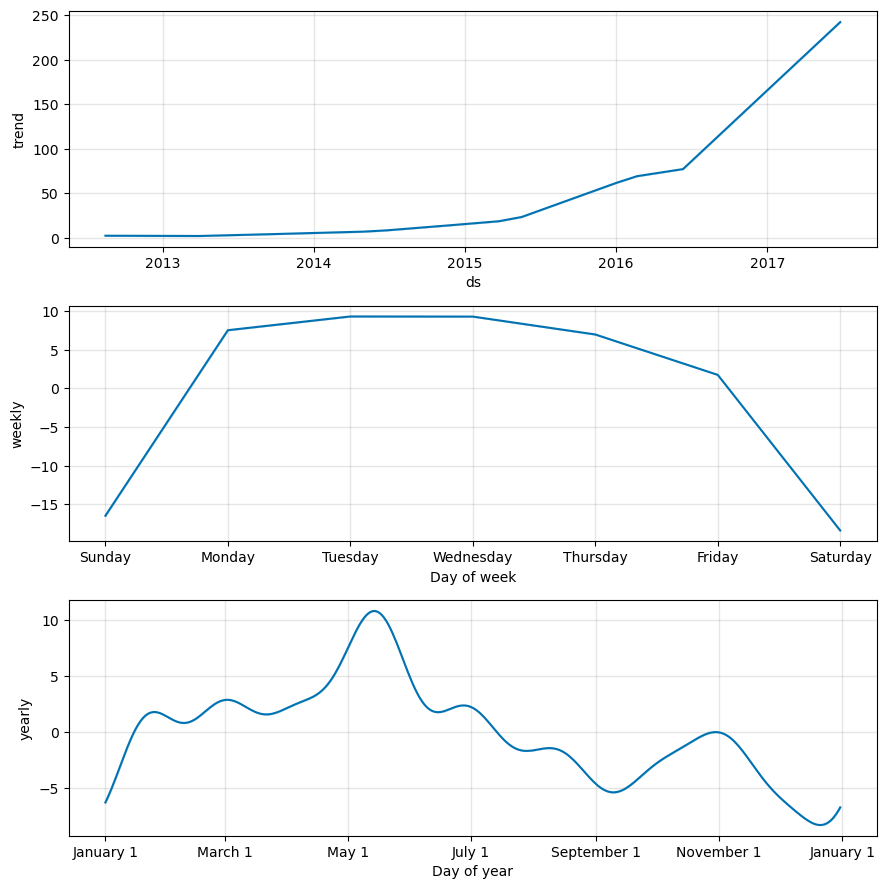

In [51]:
m.plot_components(forecast); # earlier we fitted the Prophet model on the original data (without Box-Cox transformation) and generated forecasts. The `plot_components()` method is used to visualize the different components of the time series model, such as trend, seasonality, and holidays (if any). This helps us understand how each component contributes to the overall forecast.

In [52]:
forecast.groupby(forecast["ds"].dt.year)["trend"].mean()

ds
2012      2.524917
2013      3.580702
2014      9.601592
2015     33.699326
2016     98.987863
2017    203.917305
Name: trend, dtype: float64

In [53]:
forecast.groupby(forecast["ds"].dt.year)["trend"].tail(1) # This line of code is used to extract the last trend value for each year from the forecast DataFrame. The `forecast` DataFrame contains the predicted values generated by the Prophet model, including the trend component. By grouping the data by year using `forecast["ds"].dt.year`, we can analyze how the trend evolves over time. The `.tail(1)` method selects the last row of each group, which corresponds to the final trend value for that year. This information can be useful for understanding long-term trends in the data and making year-over-year comparisons.

138       2.402502
503       5.643505
868      15.671226
1233     61.583360
1599    165.330043
1776    242.071002
Name: trend, dtype: float64

**The component plot shows three fitted components: trend, weekly seasonality, and yearly seasonality.**

**Trend.** The fitted trend accelerates strongly over the observation period. Its yearly average rises from roughly 2.5 posts/day in 2012 to roughly 204 posts/day in 2017, while the fitted trend itself reaches roughly 240 posts/day near the end of the series. The amount by which the trend increases over a year also grows substantially: approximately 3 posts/day over 2013, 10 over 2014, 46 over 2015, and 104 over 2016. Prophet's default trend is piecewise linear, not exponential, so this is best interpreted as an accelerating sequence of increasingly steep linear segments, consistent with the accelerating growth already noted in the monthly-aggregation EDA.

**Weekly seasonality.** The fitted weekly component is a fixed periodic function of day of week: Tuesday and Wednesday are highest (about +9), Monday and Thursday next (about +7), Friday close to neutral (about +2), and the weekend substantially lower (Sunday about −16 and Saturday about −18), giving a peak-to-trough amplitude of about 28 posts/day. Because this fitted weekly seasonal pattern is fixed over time, the same day-of-week effects repeat across the fitted period. The rank ordering (Tue > Wed > Mon > Thu > Fri > Sun > Sat) matches the ordering found in the raw weekday-average EDA earlier in the notebook, so the fitted weekly component is consistent with that earlier descriptive result.

**Yearly seasonality.** The fitted yearly component represents a modest annual cycle, peaking around mid-May (about +11) and reaching its minimum around late December (about −8), for a peak-to-trough amplitude of about 19 posts/day. This is smaller than the weekly amplitude and small relative to the overall change in the fitted trend. That is consistent with the earlier EDA observation that no obvious yearly pattern was visible in the monthly-aggregated series: the annual component is modest relative to the strong underlying trend and changing scale of the series. The fitted model therefore represents a modest annual cycle of this shape. However, the component plot alone does not establish that this is a stable underlying yearly seasonal effect, nor does it provide a causal explanation for the pattern.  

Together, these components also explain the negative baseline predictions disclosed earlier. The model's most negative prediction (`yhat ≈ −24.3`, on 2012-12-22, a Saturday) occurs when the very low early-period trend (`≈ 2.4`) coincides with both the weekly trough (Saturday, `≈ −18.4`) and a point near the yearly trough (`≈ −8.3`). Under Prophet's additive specification,

$$
\hat y_t = \text{trend}_t+\text{weekly}_t+\text{yearly}_t,
$$

so approximately

$$
2.4-18.4-8.3\approx -24.3.
$$

One further distinction: the **plot itself** supports the approximate component shapes and values, but quantities such as the yearly-average trend values, yearly increases, and the exact `2012-12-22` negative prediction come from our underlying `forecast` data rather than being directly readable from the figure.


## 6. Seasonal-naive benchmark

So far, the baseline and Box–Cox Prophet models have only been compared against each other. To give their MAE/RMSE values a meaningful reference point, we add a seasonal-naive benchmark: the final 7 observed values from the training period, repeated cyclically across the full 30-day held-out horizon. This uses only information available at the same forecast origin as both Prophet models — no held-out observation is ever used to predict a later held-out date — and is evaluated on the identical held-out period and metrics.

<details>
<summary><span style="color:red"> 

More on this section:

</span></summary>

The purpose of this section is to answer a very important forecasting question:

> **Are my sophisticated Prophet models actually doing better than a very simple forecasting rule?**

Until this point, we had only compared:

$$
\text{Baseline Prophet}
\quad \text{vs.} \quad
\text{Box-Cox Prophet}
$$

and found that Box-Cox Prophet improved the errors:

$$
91.58 \rightarrow 62.88 \quad \text{MAE}
$$

But that only tells us:

> Box-Cox Prophet is better than baseline Prophet.

It does **not** tell us whether Prophet is actually useful compared with a simple baseline.

That is why we introduce the seasonal-naive benchmark.

### What does “naive” mean?

A **naive forecast** uses a very simple rule rather than fitting a sophisticated statistical model.

The simplest naive forecast is:

$$
\hat y_{t+1}=y_t
$$

meaning:

> “Tomorrow will be the same as today.”

But our data have a strong **weekly pattern**. Mondays behave differently from Saturdays, Tuesdays differently from Sundays, etc.

So an ordinary naive forecast isn't the most sensible simple benchmark.

Instead we use a **seasonal naive forecast**.

For weekly seasonality:

$$
\boxed{\hat y_t = y_{t-7}}
$$

In words:

> predict a day using the observation from the same weekday one week earlier.

So:

* next Monday → use previous Monday
* next Tuesday → use previous Tuesday
* …
* next Sunday → use previous Sunday

### What our implementation does

Suppose the last seven observations in our training data were:

```text
Monday     180
Tuesday    205
Wednesday  200
Thursday   190
Friday     170
Saturday   110
Sunday     120
```

The seasonal-naive forecast simply repeats them:

```text
Forecast week 1:
180, 205, 200, 190, 170, 110, 120

Forecast week 2:
180, 205, 200, 190, 170, 110, 120

Forecast week 3:
180, 205, 200, 190, 170, 110, 120
...
```

That is what our description means by:

> “the final 7 observed values from the training period, repeated cyclically across the full 30-day held-out horizon.”

Graphically:

$$
\underbrace{[y_{T-6},\ldots,y_T]}_{\text{last training week}}
$$

gets repeated as:

$$
[y_{T-6},\ldots,y_T,
y_{T-6},\ldots,y_T,
y_{T-6},\ldots]
$$

until we have 30 predictions.

### Why this is useful

Imagine our results were:

$$
\text{Prophet MAE}=62.88
$$

and a trivial seasonal-naive model had:

$$
\text{MAE}=100
$$

Then Prophet would clearly be adding forecasting value.

But in our actual case:

$$
\begin{aligned}
\text{Baseline Prophet MAE} &= 91.58\\
\text{Box-Cox Prophet MAE} &= 62.88\\
\text{Seasonal-naive MAE} &= 49.03
\end{aligned}
$$

and:

$$
\begin{aligned}
\text{Baseline Prophet RMSE} &= 104.64\\
\text{Box-Cox Prophet RMSE} &= 76.01\\
\text{Seasonal-naive RMSE} &= 63.99
\end{aligned}
$$

So we learned something much more interesting:

$$
\boxed{\text{Box-Cox improved Prophet substantially}}
$$

but, on this particular 30-day holdout,

$$
\boxed{\text{a very simple weekly seasonal rule still produced lower errors.}}
$$

That is exactly why benchmarks are important in ML and forecasting.

A sophisticated model shouldn't merely look impressive; it should demonstrate **forecasting skill relative to a sensible simple baseline**.

### Why not use the actual previous week inside the test period?

This part of our paragraph is especially important:

> “no held-out observation is ever used to predict a later held-out date”

Suppose we're forecasting 30 days ahead all at once on May 28.

We know everything through May 27, but nothing after that.

For day 8 of the test period, it would be tempting to write:

$$
\hat y_{T+8}=y_{T+1}
$$

because $T+1$ is exactly one week earlier.

But $y_{T+1}$ is itself in our **held-out period**. At the original forecast origin, we didn't know it yet.

That would leak future information.

Instead we take only the **last seven known training observations** and cycle them repeatedly. Therefore the benchmark has exactly the same information available as Prophet at the forecast origin.

So the whole rationale of Section 6 is:

$$
\boxed{
\text{Prophet vs Prophet}
\quad\longrightarrow\quad
\text{Prophet vs a meaningful simple benchmark}
}
$$

And “seasonal-naive” essentially means:

> **Assume the seasonal pattern repeats, without fitting a model.**

For our daily dataset with strong weekly seasonality, that means repeating the last observed week.


</details>


<span style="font-size:24px; color:hotpink;">

“seasonal-naive” essentially means:

> **Assume the seasonal pattern repeats, without fitting a model.**

For our daily dataset with strong weekly seasonality, that means repeating the last observed week.

</span>

In [54]:
season_length = 7

last_observed_week = train_df["y"].iloc[-season_length:].to_numpy()

seasonal_naive_predictions = np.tile(
    last_observed_week,
    int(np.ceil(len(test_df) / season_length)),
)[: len(test_df)]

naive_cmp = pd.DataFrame(
    {
        "ds": test_df["ds"].to_numpy(),
        "y": test_df["y"].to_numpy(),
        "yhat": seasonal_naive_predictions,
    }
).set_index("ds")

print("Number of seasonal-naive predictions:", len(naive_cmp))
print("Forecast date range:", naive_cmp.index.min(), "to", naive_cmp.index.max())

alignment_check = pd.DataFrame(
    {
        "prediction_date": test_df["ds"].iloc[:season_length].to_numpy(),
        "prediction_weekday": test_df["ds"].iloc[:season_length].dt.day_name().to_numpy(),
        "source_train_date": train_df["ds"].iloc[-season_length:].to_numpy(),
        "source_weekday": train_df["ds"].iloc[-season_length:].dt.day_name().to_numpy(),
        "source_value_used_as_prediction": last_observed_week,
    }
)
display(alignment_check)


Number of seasonal-naive predictions: 30
Forecast date range: 2017-05-28 00:00:00 to 2017-06-26 00:00:00


,prediction_date,prediction_weekday,source_train_date,source_weekday,source_value_used_as_prediction
0,2017-05-28,Sunday,2017-05-21,Sunday,194
1,2017-05-29,Monday,2017-05-22,Monday,341
2,2017-05-30,Tuesday,2017-05-23,Tuesday,387
3,2017-05-31,Wednesday,2017-05-24,Wednesday,375
4,2017-06-01,Thursday,2017-05-25,Thursday,298
5,2017-06-02,Friday,2017-05-26,Friday,269
6,2017-06-03,Saturday,2017-05-27,Saturday,157


<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

Briefly, this code builds the **7-day seasonal-naive forecast** for the 30-day test period and then verifies that weekdays line up correctly.

```python
season_length = 7
```

Because the seasonality is weekly:

$$
s = 7
$$

days.

```python
last_observed_week = train_df["y"].iloc[-season_length:].to_numpy()
```

This takes the **last 7 observed target values from the training set**.

Conceptually:

```text
[last Monday, last Tuesday, ..., last Sunday]
```

These become the pattern you repeat.

Then:

```python
seasonal_naive_predictions = np.tile(
    last_observed_week,
    int(np.ceil(len(test_df) / season_length)),
)[: len(test_df)]
```

`np.tile()` repeats that last week enough times to cover the entire test period.

If the test set has 30 days:

$$
\left\lceil \frac{30}{7} \right\rceil = 5
$$

so the 7-day pattern is repeated 5 times, producing 35 values, and:

```python
[: len(test_df)]
```

cuts it back to exactly 30 predictions.

So:

$$
[7\text{-day pattern}]
\rightarrow
[7\text{-day pattern repeated}]
\rightarrow
30\text{ forecasts}
$$

Next:

```python
naive_cmp = pd.DataFrame(
    {
        "ds": test_df["ds"].to_numpy(),
        "y": test_df["y"].to_numpy(),
        "yhat": seasonal_naive_predictions,
    }
).set_index("ds")
```

creates a comparison table containing:

* `ds` = forecast date
* `y` = actual held-out value
* `yhat` = seasonal-naive prediction

The two `print()` statements simply confirm that you produced the expected number of predictions and that their dates cover the correct test period.

Finally:

```python
alignment_check = pd.DataFrame(...)
```

is a **sanity check**.

It compares the first 7 prediction dates with the 7 training dates whose values were used to forecast them.

For example, you want:

```text
prediction Monday  <- previous Monday
prediction Tuesday <- previous Tuesday
...
```

The columns:

```python
"prediction_weekday"
"source_weekday"
```

let you visually confirm that the weekdays match.

So the whole block does:

$$
\boxed{
\text{take last training week}
\rightarrow
\text{repeat it across test horizon}
\rightarrow
\text{build comparison table}
\rightarrow
\text{verify weekday alignment}
}
$$

The `alignment_check` is not part of the forecasting model itself; it is there to verify that our seasonal-naive implementation is correctly aligned.


</details>

In [55]:
mae_naive = mean_absolute_error(naive_cmp["y"], naive_cmp["yhat"])
rmse_naive = np.sqrt(mean_squared_error(naive_cmp["y"], naive_cmp["yhat"]))

print(f"MAE: {mae_naive:.2f}")
print(f"RMSE: {rmse_naive:.2f}")

comparison_table = pd.DataFrame(
    {
        "MAE": [mae_naive, mae, mae2],
        "RMSE": [rmse_naive, rmse, rmse2],
    },
    index=[
        "Seasonal naive (7-day)",
        "Baseline Prophet",
        "Prophet with Box\u2013Cox transformation",
    ],
).round(2)

display(comparison_table)


MAE: 49.03
RMSE: 63.99


,MAE,RMSE
Seasonal naive (7-day),49.03,63.99
Baseline Prophet,91.58,104.64
Prophet with Box–Cox transformation,62.88,76.01


On this held-out 30-day evaluation period, the seasonal-naive benchmark achieves lower MAE and RMSE than both Prophet models. Baseline Prophet does not outperform it: baseline's MAE (91.58) and RMSE (104.64) are roughly 43 and 41 points higher than the seasonal-naive benchmark's (49.03 and 63.99). Box–Cox Prophet narrows this gap substantially relative to baseline but also does not outperform the seasonal-naive benchmark here, with MAE and RMSE roughly 14 and 12 points higher.

On this held-out evaluation period, then, neither Prophet configuration provides a point-accuracy advantage over a rule that simply repeats the most recently observed week. This does not mean Prophet or the Box–Cox transformation are without value — Box–Cox still represents a clear improvement over the unmodified baseline — but it does mean the notebook cannot yet claim that either Prophet model outperforms a very simple reference forecast for this series. As with the baseline-vs-Box–Cox comparison, this result reflects a single 30-day window and should not be generalized further from here.

> “Point-accuracy advantage” means one model makes more accurate single-value predictions than another model. So if Model A has lower MAE/RMSE than Model B, you can say Model A has a point-accuracy advantage.

## 7. Rolling-origin robustness evaluation

The single final-holdout comparison above reflects only one 30-day forecast origin. To check whether the baseline-vs-Box–Cox result, and the seasonal-naive comparison from Step 2, hold up elsewhere in the series, we repeat the same three-model comparison — seasonal naive, baseline Prophet, and Prophet with Box–Cox — over 5 additional, non-overlapping 30-day forecast origins drawn entirely from before the final held-out period, using an expanding training window and fresh per-fold model fits (including a fresh Box–Cox lambda estimated from each fold's own training data).

In [56]:
# Deterministic, formula-based fold selection (fixed before any model is fit or inspected).
#
# Eligible range: from the denser post-2015 portion of the series (2015-01-01, per the
# earlier zero-day audit showing every day has at least one record from 2015 onward)
# through the latest possible 30-day window that still ends strictly before the
# already-approved final held-out period (2017-05-28 -> 2017-06-26).
#
# 5 validation-window starts are placed at evenly spaced offsets across that eligible
# range and snapped to the first day of their month, purely for clean, auditable
# boundaries -- not tuned in any way based on model performance.

horizon = 30
n_folds = 5

eligible_start = pd.Timestamp("2015-01-01")
final_holdout_start = pd.Timestamp("2017-05-28")
last_valid_start = final_holdout_start - pd.Timedelta(days=horizon)

span_days = (last_valid_start - eligible_start).days
offsets = np.linspace(0, span_days, n_folds)
raw_starts = [eligible_start + pd.Timedelta(days=int(round(o))) for o in offsets]
validation_starts = [pd.Timestamp(year=d.year, month=d.month, day=1) for d in raw_starts]

fold_rows = []
for i, val_start in enumerate(validation_starts, start=1):
    val_end = val_start + pd.Timedelta(days=horizon - 1)
    train_start = prophet_df["ds"].min()
    forecast_origin = val_start - pd.Timedelta(days=1)
    n_train = int((prophet_df["ds"] < val_start).sum())
    n_val = int(((prophet_df["ds"] >= val_start) & (prophet_df["ds"] <= val_end)).sum())
    fold_rows.append(
        {
            "fold": i,
            "training_start": train_start,
            "forecast_origin": forecast_origin,
            "validation_start": val_start,
            "validation_end": val_end,
            "n_train": n_train,
            "n_val": n_val,
        }
    )

fold_design = pd.DataFrame(fold_rows)

# structural verification, before any model is fit
assert len(fold_design) == n_folds
assert (fold_design["n_val"] == horizon).all(), "every validation window must have exactly 30 daily observations"
assert (fold_design["validation_end"] < final_holdout_start).all(), "no fold may overlap the final held-out period"
assert fold_design["n_train"].is_monotonic_increasing, "training history must expand across folds"
# non-overlap between consecutive folds
assert (fold_design["validation_start"].iloc[1:].to_numpy() > fold_design["validation_end"].iloc[:-1].to_numpy()).all()

display(fold_design)


,fold,training_start,forecast_origin,validation_start,validation_end,n_train,n_val
0,1,2012-08-15,2014-12-31,2015-01-01,2015-01-30,869,30
1,2,2012-08-15,2015-07-31,2015-08-01,2015-08-30,1081,30
2,3,2012-08-15,2016-01-31,2016-02-01,2016-03-01,1265,30
3,4,2012-08-15,2016-08-31,2016-09-01,2016-09-30,1478,30
4,5,2012-08-15,2017-03-31,2017-04-01,2017-04-30,1690,30


<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

This block is where we **design the 5 rolling-origin validation folds before fitting any models**. Its purpose is to make our model comparison more robust than relying on just one 30-day holdout.

The overall idea is:

$$
\boxed{
\text{Choose 5 historical forecast origins}
\rightarrow
\text{train only on the past}
\rightarrow
\text{forecast the next 30 days}
}
$$

and do that in a deterministic way so the folds were **not chosen because they happened to make a model look good**.

### 1. Define the forecasting setup

```python
horizon = 30
n_folds = 5
```

Each validation window contains:

$$
30 \text{ days}
$$

and we want:

$$
5 \text{ different forecast origins}.
$$

So later each model will effectively be tested five times instead of once.

### 2. Define where validation folds are allowed

```python
eligible_start = pd.Timestamp("2015-01-01")
```

We deliberately start from 2015 because our earlier data audit showed that from 2015 onward there were **no zero-record days**.

So we use the denser part of the series for these validation folds.

Then:

```python
final_holdout_start = pd.Timestamp("2017-05-28")
```

This is the beginning of the final 30-day holdout we had already used earlier.

We don't want our new rolling-origin validation folds to overlap it.

Then:

```python
last_valid_start = final_holdout_start - pd.Timedelta(days=horizon)
```

Since:

```text
final holdout starts: 2017-05-28
horizon:             30 days
```

the latest allowable earlier validation start is approximately:

```text
2017-04-28
```

A 30-day validation window beginning there ends before May 28.

So our eligible range is approximately:

$$
2015\text{-}01\text{-}01
\quad\rightarrow\quad
2017\text{-}04\text{-}28.
$$

### 3. Spread five folds across that range

```python
span_days = (last_valid_start - eligible_start).days
```

This computes the number of days between the earliest and latest allowed starts.

Then:

```python
offsets = np.linspace(0, span_days, n_folds)
```

`np.linspace()` divides that entire interval into evenly spaced positions.

With five folds, conceptually:

```text
start          25%          50%          75%          end
  |-------------|-------------|-------------|-------------|
 fold 1        fold 2        fold 3        fold 4        fold 5
```

So we aren't manually choosing dates based on model performance.

That's what the comment means by:

> deterministic, formula-based fold selection

### 4. Convert those offsets into dates

```python
raw_starts = [
    eligible_start + pd.Timedelta(days=int(round(o)))
    for o in offsets
]
```

Each numerical offset becomes an actual date.

So if an offset were, for example, `210` days: 

$$
2015\text{-}01\text{-}01 + 210\text{ days}
$$

would produce the corresponding candidate validation start.


### 5. Snap each start to the first day of its month

```python
validation_starts = [
    pd.Timestamp(year=d.year, month=d.month, day=1)
    for d in raw_starts
]
```

Suppose one raw date was:

```text
2015-08-05
```

we change it to:

```text
2015-08-01
```

This isn't done because August 1 produces better results. It is just to make the fold boundaries clean and easy to audit.

This process ultimately gave you validation starts like:

```text
2015-01-01
2015-08-01
2016-02-01
2016-09-01
2017-04-01
```

## 6. Construct information for each fold

```python
fold_rows = []
```

This will hold one dictionary describing each fold.

Then:

```python
for i, val_start in enumerate(validation_starts, start=1):
```

loops over our five validation starts.

For every fold:

```python
val_end = val_start + pd.Timedelta(days=horizon - 1)
```

Because the first day counts as day 1, a 30-day window ends:

$$
30-1=29
$$

days later.

So:

```text
2015-01-01 -> 2015-01-30
```

is exactly 30 observations.

### 7. Define the expanding training period

```python
train_start = prophet_df["ds"].min()
```

Every fold begins training from the beginning of the dataset.

That's why this is an **expanding-window** design.

Conceptually:

```text
Fold 1:
TRAIN ────────────────| VALIDATE

Fold 2:
TRAIN ───────────────────────────| VALIDATE

Fold 3:
TRAIN ─────────────────────────────────────| VALIDATE
```

The training set keeps getting larger.

We aren't using a fixed-size rolling training window.

### 8. Define the forecast origin

```python
forecast_origin = val_start - pd.Timedelta(days=1)
```

The forecast origin is simply the last day before the validation period.

For example:

```text
training ends / forecast origin: 2015-07-31
validation starts:              2015-08-01
```

This expresses the real forecasting question:

> Standing on July 31, how accurately can I predict the next 30 days?

### 9. Count training observations

```python
n_train = int((prophet_df["ds"] < val_start).sum())
```

This counts every observation before the validation start.

Notice:

```python
< val_start
```

not:

```python
<= val_start
```

So the first validation observation is **not included in training**.

That's essential for avoiding leakage.

### 10. Count validation observations

```python
n_val = int(
    (
        (prophet_df["ds"] >= val_start)
        & (prophet_df["ds"] <= val_end)
    ).sum()
)
```

This counts observations inside:

$$
[\text{validation start},\text{validation end}]
$$

which should always equal:

$$
30.
$$

### 11. Store the fold definition

```python
fold_rows.append(
    {
        "fold": i,
        "training_start": train_start,
        "forecast_origin": forecast_origin,
        "validation_start": val_start,
        "validation_end": val_end,
        "n_train": n_train,
        "n_val": n_val,
    }
)
```

So each row describes something like:

```text
Fold:               2
Training start:     2012-08-15
Forecast origin:    2015-07-31
Validation start:   2015-08-01
Validation end:     2015-08-30
Training samples:   1081
Validation samples: 30
```

Then:

```python
fold_design = pd.DataFrame(fold_rows)
```

turns all five dictionaries into a table.

# The assertions

These are **sanity checks**. They don't fit any model; they verify that our experimental design is valid.

### Exactly five folds

```python
assert len(fold_design) == n_folds
```

Checks:

$$
\text{number of generated folds}=5.
$$


### Every validation window has 30 days

```python
assert (fold_design["n_val"] == horizon).all()
```

Checks:

$$
n_{\text{validation}}=30
$$

for every fold.

### No validation fold overlaps the final holdout

```python
assert (
    fold_design["validation_end"] < final_holdout_start
).all()
```

Every rolling-validation period must finish before:

```text
2017-05-28
```

so our final holdout remains separate.

### Training sets must grow

```python
assert fold_design["n_train"].is_monotonic_increasing
```

Checks that:

$$
n_{\text{train},1}
<
n_{\text{train},2}
<
\cdots
<
n_{\text{train},5}
$$

which confirms the intended expanding-window setup.


### Validation periods must not overlap

```python
assert (
    fold_design["validation_start"].iloc[1:].to_numpy()
    >
    fold_design["validation_end"].iloc[:-1].to_numpy()
).all()
```

This compares:

```text
start of fold 2 > end of fold 1
start of fold 3 > end of fold 2
...
```

so no two validation windows overlap.

Finally:

```python
display(fold_design)
```

shows us the complete experimental design before any forecasting model is fitted.

### The big picture

This block is essentially saying:

> “Before looking at model performance, I will objectively choose five historical points in time. At each point, I will pretend I am standing there, train only on information available up to that date, and evaluate forecasts for the following 30 days.”

So instead of trusting only:

$$
\boxed{\text{one 30-day holdout}}
$$

we later obtain:

$$
\boxed{\text{five separate 30-day forecasting experiments}}
$$

which gives us much stronger evidence about whether Prophet, Box-Cox Prophet, or seasonal naive performs consistently across different periods.
</details>

In [57]:
fold_rows

[{'fold': 1,
  'training_start': Timestamp('2012-08-15 00:00:00'),
  'forecast_origin': Timestamp('2014-12-31 00:00:00'),
  'validation_start': Timestamp('2015-01-01 00:00:00'),
  'validation_end': Timestamp('2015-01-30 00:00:00'),
  'n_train': 869,
  'n_val': 30},
 {'fold': 2,
  'training_start': Timestamp('2012-08-15 00:00:00'),
  'forecast_origin': Timestamp('2015-07-31 00:00:00'),
  'validation_start': Timestamp('2015-08-01 00:00:00'),
  'validation_end': Timestamp('2015-08-30 00:00:00'),
  'n_train': 1081,
  'n_val': 30},
 {'fold': 3,
  'training_start': Timestamp('2012-08-15 00:00:00'),
  'forecast_origin': Timestamp('2016-01-31 00:00:00'),
  'validation_start': Timestamp('2016-02-01 00:00:00'),
  'validation_end': Timestamp('2016-03-01 00:00:00'),
  'n_train': 1265,
  'n_val': 30},
 {'fold': 4,
  'training_start': Timestamp('2012-08-15 00:00:00'),
  'forecast_origin': Timestamp('2016-08-31 00:00:00'),
  'validation_start': Timestamp('2016-09-01 00:00:00'),
  'validation_end': Ti

In [58]:
season_length = 7
boxcox_offset = 1

fold_results = []
negative_prediction_log = []

for _, fold_row in fold_design.iterrows(): # that _ is a common convention in Python to indicate that the variable is intentionally unused. In this case, we are iterating over the rows of the fold_design DataFrame, but we don't need the index of each row, so we use _ as a placeholder for it.
    fold_num = fold_row["fold"]
    val_start = fold_row["validation_start"]
    val_end = fold_row["validation_end"]

    fold_train = prophet_df[prophet_df["ds"] < val_start].reset_index(drop=True)
    fold_val = prophet_df[
        (prophet_df["ds"] >= val_start) & (prophet_df["ds"] <= val_end)
    ].reset_index(drop=True)

    assert len(fold_val) == horizon
    assert (fold_val["ds"].to_numpy() == pd.date_range(val_start, val_end, freq="D").to_numpy()).all()

    # ---- Model 1: seasonal naive (7-day), training data only ----
    last_observed_week = fold_train["y"].iloc[-season_length:].to_numpy()
    naive_yhat = np.tile(
        last_observed_week, int(np.ceil(horizon / season_length))
    )[:horizon]

    # weekday alignment must hold by construction (validation starts the day after training ends)
    assert (
        fold_val["ds"].iloc[:season_length].dt.day_name().to_numpy()
        == fold_train["ds"].iloc[-season_length:].dt.day_name().to_numpy()
    ).all()

    mae_naive = mean_absolute_error(fold_val["y"], naive_yhat)
    rmse_naive = np.sqrt(mean_squared_error(fold_val["y"], naive_yhat))
    fold_results.append(
        {
            "fold": fold_num,
            "forecast_origin": fold_row["forecast_origin"],
            "model": "Seasonal naive (7-day)",
            "MAE": mae_naive,
            "RMSE": rmse_naive,
            "lambda_boxcox": np.nan,
        }
    )

    # ---- Model 2: baseline Prophet, fresh fit on this fold's training data only ----
    m_fold = Prophet()
    m_fold.fit(fold_train)
    future_fold = m_fold.make_future_dataframe(periods=horizon, freq="D")
    forecast_fold = m_fold.predict(future_fold)
    baseline_yhat = forecast_fold.tail(horizon)["yhat"].to_numpy()

    n_neg_baseline = int((baseline_yhat < 0).sum())
    if n_neg_baseline > 0:
        negative_prediction_log.append(
            {
                "fold": fold_num,
                "model": "Baseline Prophet",
                "n_negative": n_neg_baseline,
                "min_value": float(baseline_yhat.min()),
            }
        )

    mae_baseline = mean_absolute_error(fold_val["y"], baseline_yhat)
    rmse_baseline = np.sqrt(mean_squared_error(fold_val["y"], baseline_yhat))
    fold_results.append(
        {
            "fold": fold_num,
            "forecast_origin": fold_row["forecast_origin"],
            "model": "Baseline Prophet",
            "MAE": mae_baseline,
            "RMSE": rmse_baseline,
            "lambda_boxcox": np.nan,
        }
    )

    # ---- Model 3: Box-Cox Prophet, lambda re-estimated from this fold's training data only ----
    fold_train_boxcox = fold_train.copy()
    fold_train_boxcox["y"], lambda_fold = stats.boxcox(fold_train_boxcox["y"] + boxcox_offset)

    m2_fold = Prophet()
    m2_fold.fit(fold_train_boxcox)
    future2_fold = m2_fold.make_future_dataframe(periods=horizon, freq="D")
    forecast2_fold = m2_fold.predict(future2_fold)

    boxcox_yhat_transformed = forecast2_fold.tail(horizon)["yhat"].to_numpy()
    boxcox_yhat_raw = inv_boxcox(boxcox_yhat_transformed, lambda_fold) - boxcox_offset

    n_neg_boxcox = int((boxcox_yhat_raw < 0).sum())
    if n_neg_boxcox > 0:
        negative_prediction_log.append(
            {
                "fold": fold_num,
                "model": "Prophet + Box-Cox (pre-clip)",
                "n_negative": n_neg_boxcox,
                "min_value": float(boxcox_yhat_raw.min()),
            }
        )

    # same clip(lower=0) rule already used in the approved single-holdout Box-Cox pipeline
    # boxcox_yhat = np.clip(boxcox_yhat_raw, a_min=0, a_max=None)
    boxcox_yhat = boxcox_yhat_raw

    mae_boxcox = mean_absolute_error(fold_val["y"], boxcox_yhat)
    rmse_boxcox = np.sqrt(mean_squared_error(fold_val["y"], boxcox_yhat))
    fold_results.append(
        {
            "fold": fold_num,
            "forecast_origin": fold_row["forecast_origin"],
            "model": "Prophet + Box-Cox",
            "MAE": mae_boxcox,
            "RMSE": rmse_boxcox,
            "lambda_boxcox": lambda_fold,
        }
    )

fold_results_df = pd.DataFrame(fold_results)
display(fold_results_df.round(3))

print()
print("Box-Cox lambda by fold:")
display(
    fold_results_df.loc[fold_results_df["model"] == "Prophet + Box-Cox", ["fold", "lambda_boxcox"]]
    .round(4)
    .reset_index(drop=True)
)

print()
if negative_prediction_log:
    print("Negative point predictions encountered inside a validation window:")
    display(pd.DataFrame(negative_prediction_log))
else:
    print("No negative point predictions were produced by any model in any validation window.")


16:51:57 - cmdstanpy - INFO - Chain [1] start processing
16:51:57 - cmdstanpy - INFO - Chain [1] done processing
16:51:58 - cmdstanpy - INFO - Chain [1] start processing
16:51:58 - cmdstanpy - INFO - Chain [1] done processing
16:51:58 - cmdstanpy - INFO - Chain [1] start processing
16:51:58 - cmdstanpy - INFO - Chain [1] done processing
16:51:58 - cmdstanpy - INFO - Chain [1] start processing
16:51:59 - cmdstanpy - INFO - Chain [1] done processing
16:51:59 - cmdstanpy - INFO - Chain [1] start processing
16:51:59 - cmdstanpy - INFO - Chain [1] done processing
16:51:59 - cmdstanpy - INFO - Chain [1] start processing
16:51:59 - cmdstanpy - INFO - Chain [1] done processing
16:52:00 - cmdstanpy - INFO - Chain [1] start processing
16:52:00 - cmdstanpy - INFO - Chain [1] done processing
16:52:00 - cmdstanpy - INFO - Chain [1] start processing
16:52:00 - cmdstanpy - INFO - Chain [1] done processing
16:52:01 - cmdstanpy - INFO - Chain [1] start processing
16:52:01 - cmdstanpy - INFO - Chain [1]

,fold,forecast_origin,model,MAE,RMSE,lambda_boxcox
0,1,2014-12-31,Seasonal naive (7-day),6.200,7.559,NaN
1,1,2014-12-31,Baseline Prophet,6.024,7.633,NaN
2,1,2014-12-31,Prophet + Box-Cox,6.616,8.110,0.239
3,2,2015-07-31,Seasonal naive (7-day),8.033,11.014,NaN
4,2,2015-07-31,Baseline Prophet,8.479,10.462,NaN
5,2,2015-07-31,Prophet + Box-Cox,5.454,7.383,0.125
6,3,2016-01-31,Seasonal naive (7-day),13.667,17.776,NaN
7,3,2016-01-31,Baseline Prophet,20.521,24.366,NaN
8,3,2016-01-31,Prophet + Box-Cox,12.732,16.523,0.035
9,4,2016-08-31,Seasonal naive (7-day),11.467,15.212,NaN



Box-Cox lambda by fold:


,fold,lambda_boxcox
0,1,0.2385
1,2,0.1246
2,3,0.0349
3,4,0.0264
4,5,0.0353



No negative point predictions were produced by any model in any validation window.


<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

This is the block that actually **runs the rolling-origin experiment** we designed in the previous section.

For each of our 5 historical folds, it:

$$
\boxed{
\text{builds training/validation data}
\rightarrow
\text{fits 3 forecasting approaches}
\rightarrow
\text{computes MAE/RMSE}
\rightarrow
\text{stores the results}
}
$$

The three approaches are:

$$
\text{Seasonal naive}
,\quad
\text{Baseline Prophet}
,\quad
\text{Box-Cox Prophet}.
$$

### 1. Set constants and create result containers

```python
season_length = 7
boxcox_offset = 1

fold_results = []
negative_prediction_log = []
```

`season_length = 7` means our seasonal-naive benchmark assumes a **weekly cycle**.

`boxcox_offset = 1` is needed because Box-Cox requires positive values:

$$
y \ge 0
\quad\Rightarrow\quad
y+1>0.
$$

`fold_results` will collect MAE/RMSE for every model in every fold.

`negative_prediction_log` records any negative forecasts, since negative post counts are physically impossible.

## 2. Loop through the five folds

```python
for _, fold_row in fold_design.iterrows():
```

This goes through the `fold_design` table you created previously.

For each fold:

```python
fold_num = fold_row["fold"]
val_start = fold_row["validation_start"]
val_end = fold_row["validation_end"]
```

we retrieve:

* fold number
* validation start
* validation end.

Conceptually:

```text
Fold 1 → train on past → predict next 30 days
Fold 2 → more training data → predict next 30 days
...
Fold 5 → even more training data → predict next 30 days
```

## 3. Construct the training and validation sets

```python
fold_train = prophet_df[
    prophet_df["ds"] < val_start
].reset_index(drop=True)
```

Everything **before** the validation period becomes training data.

Then:

```python
fold_val = prophet_df[
    (prophet_df["ds"] >= val_start)
    & (prophet_df["ds"] <= val_end)
].reset_index(drop=True)
```

selects exactly the 30 validation days.

So for a hypothetical fold:

```text
                     forecast origin
                           ↓
TRAIN ─────────────────────| VALIDATION ──────────
                           |<------ 30 days ------>
```

Crucially, nothing from validation is used for fitting.

## 4. Verify the validation window

```python
assert len(fold_val) == horizon
```

Checks that there are exactly:

$$
30
$$

validation observations.

Then:

```python
assert (
    fold_val["ds"].to_numpy()
    == pd.date_range(val_start, val_end, freq="D").to_numpy()
).all()
```

checks that those observations form a **complete daily sequence**.

So we're not accidentally evaluating something like:

```text
Jan 1
Jan 2
Jan 4   ← Jan 3 missing
Jan 5
```

The validation data must have every calendar day.

# Model 1: Seasonal naive

```python
last_observed_week = (
    fold_train["y"]
    .iloc[-season_length:]
    .to_numpy()
)
```

Take the final seven known observations before the forecast origin.

Then:

```python
naive_yhat = np.tile(
    last_observed_week,
    int(np.ceil(horizon / season_length))
)[:horizon]
```

repeat that weekly pattern until we have 30 forecasts.

So:

$$
[y_{T-6},\ldots,y_T]
$$

becomes:

$$
[y_{T-6},\ldots,y_T,
y_{T-6},\ldots,y_T,\ldots]
$$

for 30 days.

### Verify weekday alignment

```python
assert (
    fold_val["ds"].iloc[:season_length]
    .dt.day_name()
    .to_numpy()
    ==
    fold_train["ds"].iloc[-season_length:]
    .dt.day_name()
    .to_numpy()
).all()
```

This verifies that:

```text
forecast Monday  ← training Monday
forecast Tuesday ← training Tuesday
...
```

So we're actually implementing the intended weekly seasonal-naive rule.


### Calculate seasonal-naive errors

```python
mae_naive = mean_absolute_error(
    fold_val["y"],
    naive_yhat
)
```

calculates:

$$
MAE=
\frac1n\sum_{t=1}^{n}|y_t-\hat y_t|.
$$

And:

```python
rmse_naive = np.sqrt(
    mean_squared_error(
        fold_val["y"],
        naive_yhat
    )
)
```

calculates:

$$
RMSE=
\sqrt{
\frac1n
\sum_{t=1}^{n}
(y_t-\hat y_t)^2
}.
$$

Then:

```python
fold_results.append(...)
```

stores the results.

For the naive model:

```python
"lambda_boxcox": np.nan
```

because Box-Cox isn't involved.


# Model 2: Baseline Prophet

Now we create a **completely new Prophet model for this fold**:

```python
m_fold = Prophet()
m_fold.fit(fold_train)
```

This is important.

We do **not** reuse the Prophet model that was fitted earlier in the notebook.

Each historical experiment must act as though we're genuinely standing at that point in time:

$$
\boxed{\text{fit only on information available then}}
$$

Then:

```python
future_fold = m_fold.make_future_dataframe(
    periods=horizon,
    freq="D"
)
```

creates dates consisting of:

```text
training history + next 30 future days
```

and:

```python
forecast_fold = m_fold.predict(future_fold)
```

generates Prophet predictions.


### Extract only the actual future forecasts

```python
baseline_yhat = (
    forecast_fold
    .tail(horizon)["yhat"]
    .to_numpy()
)
```

Since `forecast_fold` includes predictions for historical dates too, we take only:

```python
.tail(30)
```

which corresponds to the 30 validation dates.

So:

$$
\text{entire Prophet forecast}
\rightarrow
\boxed{\text{future 30-day portion}}
$$


## 5. Check for negative baseline predictions

```python
n_neg_baseline = int(
    (baseline_yhat < 0).sum()
)
```

counts how many validation forecasts are negative.

If there are any:

```python
if n_neg_baseline > 0:
```

we save:

```python
{
    "fold": fold_num,
    "model": "Baseline Prophet",
    "n_negative": n_neg_baseline,
    "min_value": float(baseline_yhat.min()),
}
```

So later we can inspect whether Prophet generated impossible negative post counts.

Notice that we **don't alter them here**. We're just recording them.

Then we calculate MAE/RMSE and store them exactly as we did for seasonal naive.


# Model 3: Box-Cox Prophet

Now we make a copy of this fold's training data:

```python
fold_train_boxcox = fold_train.copy()
```

and apply Box-Cox:

```python
fold_train_boxcox["y"], lambda_fold = stats.boxcox(
    fold_train_boxcox["y"] + boxcox_offset
)
```

There are two important things happening.

First:

$$
y \rightarrow y+1
$$

so all observations are strictly positive.

Second, `stats.boxcox()` estimates a new:

$$
\lambda_{\text{fold}}
$$

from **this fold's training data only**.

That's methodologically important.

We are **not** estimating one $\lambda$ using the complete dataset and then carrying it backward into earlier validation periods.

Instead:

```text
Fold 1 training → estimate λ₁
Fold 2 training → estimate λ₂
Fold 3 training → estimate λ₃
...
```

which avoids leakage.

## 6. Fit a fresh Prophet on the transformed scale

```python
m2_fold = Prophet()
m2_fold.fit(fold_train_boxcox)
```

Prophet is therefore modeling:

$$
z_t = \operatorname{BoxCox}(y_t+1)
$$

rather than raw post counts.

Then:

```python
future2_fold = m2_fold.make_future_dataframe(
    periods=horizon,
    freq="D"
)

forecast2_fold = m2_fold.predict(future2_fold)
```

makes the 30-day forecast.


## 7. Extract and inverse-transform the predictions

```python
boxcox_yhat_transformed = (
    forecast2_fold.tail(horizon)["yhat"].to_numpy()
)
```

These forecasts are still on the Box-Cox scale:

$$
\hat z_t.
$$

So:

```python
boxcox_yhat_raw = (
    inv_boxcox(
        boxcox_yhat_transformed,
        lambda_fold
    )
    - boxcox_offset
)
```

converts them back to the original scale:

$$
\hat z_t
\xrightarrow{\text{inverse Box-Cox}}
\hat y_t+1
\xrightarrow{-1}
\hat y_t.
$$

Now we once again have predicted **posts per day**.


## 8. Check for negative Box-Cox predictions

```python
n_neg_boxcox = int(
    (boxcox_yhat_raw < 0).sum()
)
```

and, if necessary, log:

```python
fold number
number of negatives
most negative prediction
```

This lets us audit whether the inverse-transformed model still generated impossible values.


## 9. Calculate Box-Cox errors

After deciding which predictions are being evaluated:

```python
mae_boxcox = mean_absolute_error(
    fold_val["y"],
    boxcox_yhat
)
```

and:

```python
rmse_boxcox = np.sqrt(
    mean_squared_error(
        fold_val["y"],
        boxcox_yhat
    )
)
```

calculate validation error.

Then we store:

```python
{
    "fold": fold_num,
    "forecast_origin": ...,
    "model": "Prophet + Box-Cox",
    "MAE": ...,
    "RMSE": ...,
    "lambda_boxcox": lambda_fold,
}
```

Unlike the other models, we save the fold-specific $\lambda$, which lets us see how the estimated transformation changes as more historical data become available.

# After all five folds finish

```python
fold_results_df = pd.DataFrame(fold_results)
```

turns everything into one table.

Since we have:

$$
5\text{ folds}
\times
3\text{ models}
=
15\text{ results},
$$

we should get 15 rows.

Something conceptually like:

| Fold | Model             | MAE | RMSE |      λ |
| ---- | ----------------- | --: | ---: | -----: |
| 1    | Seasonal naive    | ... |  ... |    NaN |
| 1    | Baseline Prophet  | ... |  ... |    NaN |
| 1    | Prophet + Box-Cox | ... |  ... | 0.2385 |
| 2    | Seasonal naive    | ... |  ... |    NaN |
| ...  | ...               | ... |  ... |    ... |

Then:

```python
display(fold_results_df.round(3))
```

shows the results rounded to three decimals.

## 10. Display the Box-Cox λ values separately

```python
fold_results_df.loc[
    fold_results_df["model"] == "Prophet + Box-Cox",
    ["fold", "lambda_boxcox"]
]
```

selects only Box-Cox rows and displays:

```text
Fold 1 → λ₁
Fold 2 → λ₂
...
Fold 5 → λ₅
```

In our saved run they were approximately:

$$
0.2385,\;
0.1246,\;
0.0349,\;
0.0264,\;
0.0353.
$$

We can see that later folds increasingly favored a transformation close to:

$$
\lambda=0
$$

which corresponds approximately to a log transformation.

But that's descriptive; we shouldn't interpret the changing $\lambda$ by itself as evidence that one forecasting model is better.


## 11. Report negative predictions

Finally:

```python
if negative_prediction_log:
```

checks whether anything was recorded.

If yes:

```python
display(pd.DataFrame(negative_prediction_log))
```

shows which model/fold generated negatives.

Otherwise:

```python
print(
    "No negative point predictions were produced "
    "by any model in any validation window."
)
```

confirms there were none.


### What this entire cell is doing

The previous cell said:

> “Here are the five historical situations in which I will test my models.”

This cell now says:

> “At each of those historical points, I will fit every model using only information that would have been available at that time, forecast the same next 30 days, and compare their MAE and RMSE.”

So the experiment is:

$$
\begin{array}{c}
\text{Fold 1}\\
\text{Fold 2}\\
\text{Fold 3}\\
\text{Fold 4}\\
\text{Fold 5}
\end{array}
\quad
\times
\quad
\begin{array}{c}
\text{Seasonal naive}\\
\text{Baseline Prophet}\\
\text{Box-Cox Prophet}
\end{array}
$$

giving:

$$
\boxed{15\text{ model–fold evaluations}}
$$

This is the actual implementation of the **rolling-origin / expanding-window model comparison** that our earlier notebook text said would be more reliable than judging the models from a single 30-day holdout.

</details>

In [59]:
agg = (
    fold_results_df
    .groupby("model")[["MAE", "RMSE"]]
    .agg(["mean", "median"])
)
agg.columns = ["_".join(c) for c in agg.columns]
agg = agg.round(2)

best_mae_counts = (
    fold_results_df
    .loc[fold_results_df.groupby("fold")["MAE"].idxmin(), "model"]
    .value_counts()
    .rename("folds_with_lowest_MAE")
)
best_rmse_counts = (
    fold_results_df
    .loc[fold_results_df.groupby("fold")["RMSE"].idxmin(), "model"]
    .value_counts()
    .rename("folds_with_lowest_RMSE")
)

summary_table = (
    agg
    .join(best_mae_counts)
    .join(best_rmse_counts)
    .fillna(0)
)
summary_table[["folds_with_lowest_MAE", "folds_with_lowest_RMSE"]] = summary_table[
    ["folds_with_lowest_MAE", "folds_with_lowest_RMSE"]
].astype(int)

display(summary_table)

# fold_results_df.groupby("fold")["MAE"].idxmin() means that we are grouping the fold_results_df DataFrame by the "fold" column and then finding the index of the minimum value in the "MAE" column for each group. This gives us the index of the row with the lowest MAE for each fold. We then use this index to select the corresponding rows from the original DataFrame, which allows us to see which model had the lowest MAE for each fold. Finally, we count how many times each model had the lowest MAE across all folds using value_counts() and rename the resulting Series to "folds_with_lowest_MAE".



,MAE_mean,MAE_median,RMSE_mean,RMSE_median,folds_with_lowest_MAE,folds_with_lowest_RMSE
model,,,,,,
Baseline Prophet,20.54,17.10,24.36,20.61,1,0
Prophet + Box-Cox,14.24,10.31,17.40,13.34,3,3
Seasonal naive (7-day),13.03,11.47,16.90,15.21,1,2


In [60]:
agg = (
    fold_results_df
    .groupby("model")[["MAE", "RMSE"]]
    .agg(["mean", "median"])
)
agg

MAE                  RMSE           
                             mean     median       mean     median
model                                                             
Baseline Prophet        20.540592  17.104160  24.363344  20.606284
Prophet + Box-Cox       14.239512  10.313247  17.401244  13.338471
Seasonal naive (7-day)  13.026667  11.466667  16.904725  15.211837

In [61]:
agg.columns

MultiIndex([( 'MAE',   'mean'),
            ( 'MAE', 'median'),
            ('RMSE',   'mean'),
            ('RMSE', 'median')],
           )

In [62]:
agg.columns = ["_".join(c) for c in agg.columns]
agg.columns

Index(['MAE_mean', 'MAE_median', 'RMSE_mean', 'RMSE_median'], dtype='object')

In [63]:
fold_results_df.groupby("fold")["RMSE"].idxmin()

fold
1     0
2     5
3     8
4    11
5    12
Name: RMSE, dtype: int64

In [64]:
fold_results_df.loc[fold_results_df.groupby("fold")["RMSE"].idxmin(), "model"]

0     Seasonal naive (7-day)
5          Prophet + Box-Cox
8          Prophet + Box-Cox
11         Prophet + Box-Cox
12    Seasonal naive (7-day)
Name: model, dtype: object

<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

This block takes the **15 individual fold/model results** we created earlier and turns them into a compact model-comparison summary.

Conceptually:

$$
\boxed{
\text{15 raw fold results}
\rightarrow
\text{average/median performance}
+
\text{number of fold wins}
}
$$

By “number of fold wins,” I mean: *How many of the 5 validation folds did a particular model achieve the lowest error among the three models?*

### 1. Compute mean and median MAE/RMSE for each model

```python
agg = (
    fold_results_df
    .groupby("model")[["MAE", "RMSE"]]
    .agg(["mean", "median"])
)
```

Our `fold_results_df` has one row per:

$$
\text{fold} \times \text{model}
$$

So with 5 folds and 3 models:

$$
5 \times 3 = 15 \text{ rows}.
$$

This code groups those rows by model and calculates, across the 5 folds:

* mean MAE
* median MAE
* mean RMSE
* median RMSE

So for each model we get something like:

$$
\text{MAE}_{mean}
,\quad
\text{MAE}_{median}
,\quad
\text{RMSE}_{mean}
,\quad
\text{RMSE}_{median}.
$$

The mean tells us the average error across folds.

The median tells us the middle fold performance and is less sensitive to one unusually bad fold.


### 2. Flatten the column names

After this:

```python
.agg(["mean", "median"])
```

Pandas creates hierarchical column names like:

```text
("MAE", "mean")
("MAE", "median")
("RMSE", "mean")
("RMSE", "median")
```

Then:

```python
agg.columns = ["_".join(c) for c in agg.columns]
```

turns them into simpler names:

```text
MAE_mean
MAE_median
RMSE_mean
RMSE_median
```

Then:

```python
agg = agg.round(2)
```

rounds those summary values to 2 decimal places.

# 3. Count which model had the lowest MAE in each fold

```python
best_mae_counts = (
    fold_results_df
    .loc[fold_results_df.groupby("fold")["MAE"].idxmin(), "model"]
    .value_counts()
    .rename("folds_with_lowest_MAE")
)
```

This looks complicated, but the logic is simple.

First:

```python
fold_results_df.groupby("fold")["MAE"].idxmin()
```

finds the row index with the **smallest MAE inside each fold**.

So for each fold:

```text
Fold 1 → which model has lowest MAE?
Fold 2 → which model has lowest MAE?
...
Fold 5 → which model has lowest MAE?
```

Then:

```python
.loc[..., "model"]
```

extracts the model name from those winning rows.

We might get something like:

```text
Baseline Prophet
Prophet + Box-Cox
Prophet + Box-Cox
Prophet + Box-Cox
Seasonal naive (7-day)
```

Then:

```python
.value_counts()
```

counts how many times each model won.

So conceptually:

```text
Prophet + Box-Cox      3
Seasonal naive         1
Baseline Prophet       1
```

meaning Box-Cox had the lowest MAE in 3 of the 5 folds.

Finally:

```python
.rename("folds_with_lowest_MAE")
```

just gives that result column a clear name.


# 4. Do the same for RMSE

```python
best_rmse_counts = (
    fold_results_df
    .loc[fold_results_df.groupby("fold")["RMSE"].idxmin(), "model"]
    .value_counts()
    .rename("folds_with_lowest_RMSE")
)
```

This is identical logic, but now the "winner" in each fold is the model with the smallest RMSE.

So we get:

$$
\text{number of folds where each model had lowest RMSE}.
$$

In our notebook, the pattern was approximately:

```text
Box-Cox Prophet → 3 RMSE wins
Seasonal naive → 2 RMSE wins
Baseline Prophet → 0 RMSE wins
```

# 5. Combine everything into one table

```python
summary_table = (
    agg
    .join(best_mae_counts)
    .join(best_rmse_counts)
    .fillna(0)
)
```

This joins the average/median metrics with the fold-win counts.

So the final structure is approximately:

| Model             | MAE mean | MAE median | RMSE mean | RMSE median | Lowest MAE folds | Lowest RMSE folds |
| ----------------- | -------: | ---------: | --------: | ----------: | ---------------: | ----------------: |
| Seasonal naive    |      ... |        ... |       ... |         ... |              ... |               ... |
| Baseline Prophet  |      ... |        ... |       ... |         ... |              ... |               ... |
| Prophet + Box-Cox |      ... |        ... |       ... |         ... |              ... |               ... |

The:

```python
.fillna(0)
```

is needed because if a model never wins any fold, `value_counts()` won't create an entry for it.

For example, if baseline Prophet never has the lowest RMSE, its RMSE win count would otherwise be missing (`NaN`).

We convert that missing value to:

```text
0
```

which is what it actually means here.


## 6. Convert the win counts to integers

```python
summary_table[["folds_with_lowest_MAE", "folds_with_lowest_RMSE"]] = summary_table[
    ["folds_with_lowest_MAE", "folds_with_lowest_RMSE"]
].astype(int)
```

Without this, because of `fillna(0)`, Pandas might display counts like:

```text
3.0
1.0
0.0
```

But these are counts, so:

```text
3
1
0
```

is more appropriate.


Finally:

```python
display(summary_table)
```

shows the finished summary.

### Why we're doing this

Looking at 15 individual rows can make it hard to see the overall pattern.

This summary gives us two complementary views:

$$
\boxed{\text{Typical performance}}
$$

through:

* mean MAE/RMSE
* median MAE/RMSE

and:

$$
\boxed{\text{Consistency across origins}}
$$

through:

* number of MAE wins
* number of RMSE wins.

That distinction is useful.

For example, in our results:

* seasonal naive had the **lowest mean errors overall**
* Box-Cox Prophet had the **lowest median errors**
* Box-Cox Prophet also won more individual folds on MAE
* rankings changed depending on the forecast origin

So the table helps us avoid making a simplistic claim like:

> "Model X is always best."

Instead, it shows that performance varies across time, which is exactly the point of doing rolling-origin evaluation in the first place.


</details>

Across the 5 rolling-origin folds (forecast origins 2014-12-31 through 2017-03-31), Box–Cox Prophet outperforms baseline Prophet on both MAE and RMSE in four of the five folds. Fold 1 is the only exception, where baseline Prophet is slightly better than Box–Cox Prophet (MAE 6.02 vs. 6.62; RMSE 7.63 vs. 8.11). Across all five folds, Box–Cox Prophet also has lower mean and median MAE/RMSE than baseline Prophet.

Looking across all three models, seasonal naive has the lowest mean MAE and RMSE (13.03 and 16.90), while Box–Cox Prophet has the lowest median MAE and RMSE (10.31 and 13.34). Baseline Prophet has the highest mean and median values for both metrics. The difference between the mean and median summaries is influenced substantially by fold 5, where both Prophet models incur much larger absolute errors than seasonal naive.

Neither Prophet specification consistently beats the seasonal-naive benchmark. By MAE, baseline Prophet is the weakest of the three models in folds 2–5; by RMSE, it is the weakest in folds 3–5. In fold 1, baseline Prophet has the lowest MAE by a small margin (6.02 vs. 6.20 for seasonal naive), while seasonal naive has the slightly lower RMSE (7.56 vs. 7.63). Box–Cox Prophet outperforms seasonal naive on both metrics in folds 2–4, but seasonal naive performs better in folds 1 and 5.

The model ordering therefore changes across forecast origins. Box–Cox Prophet has the lowest MAE in 3 of the 5 folds and the lowest RMSE in 3; seasonal naive has the lowest MAE in 1 fold and the lowest RMSE in 2; baseline Prophet has the lowest MAE in 1 fold and the lowest RMSE in none.

The original final-holdout ordering — seasonal naive best, Box–Cox Prophet second, and baseline Prophet worst — matches the exact ordering of only one rolling-origin fold: fold 5, the most recent fold before the final held-out period. It differs from folds 2–4, where Box–Cox Prophet produces the lowest MAE and RMSE. The final holdout therefore resembles the most recent rolling-origin result, but it should not be treated as representative of all historical forecast origins.

One scale caveat is important. Because the series has a strong, accelerating trend, the different folds occur at substantially different absolute post-count levels. Raw MAE and RMSE values therefore should not be interpreted as directly comparable measures of forecasting difficulty across folds. Their mean and median across folds are useful descriptive summaries, but later high-level periods can contribute disproportionately to the mean. The most defensible comparisons are the relative performance of the three models **within the same fold**, together with how often those within-fold rankings recur across forecast origins.

## 8. Selecting the Prophet specification

The rolling-origin evaluation above, rather than the single final held-out period, provides the primary evidence for choosing between the two Prophet variants evaluated so far. As a quick check directly against those rolling-origin results (not a new experiment):

In [65]:
mae_by_fold_model = fold_results_df.pivot(index="fold", columns="model", values="MAE")

boxcox_beats_baseline = (
    mae_by_fold_model["Prophet + Box-Cox"] < mae_by_fold_model["Baseline Prophet"]
).sum()

boxcox_beats_naive = (
    mae_by_fold_model["Prophet + Box-Cox"] < mae_by_fold_model["Seasonal naive (7-day)"]
).sum()

print(
    f"Box-Cox Prophet has lower fold MAE than baseline Prophet in "
    f"{boxcox_beats_baseline} of {len(mae_by_fold_model)} rolling-origin folds."
)
print(
    f"Box-Cox Prophet has lower fold MAE than seasonal naive in "
    f"{boxcox_beats_naive} of {len(mae_by_fold_model)} rolling-origin folds."
)


Box-Cox Prophet has lower fold MAE than baseline Prophet in 4 of 5 rolling-origin folds.
Box-Cox Prophet has lower fold MAE than seasonal naive in 3 of 5 rolling-origin folds.


In [66]:
fold_results_df

,fold,forecast_origin,model,MAE,RMSE,lambda_boxcox
0,1,2014-12-31,Seasonal naive (7-day),6.200000,7.558659,NaN
1,1,2014-12-31,Baseline Prophet,6.024431,7.632671,NaN
2,1,2014-12-31,Prophet + Box-Cox,6.616160,8.109746,0.238517
3,2,2015-07-31,Seasonal naive (7-day),8.033333,11.013628,NaN
4,2,2015-07-31,Baseline Prophet,8.479350,10.462017,NaN
5,2,2015-07-31,Prophet + Box-Cox,5.453855,7.383123,0.124554
6,3,2016-01-31,Seasonal naive (7-day),13.666667,17.776389,NaN
7,3,2016-01-31,Baseline Prophet,20.520505,24.366264,NaN
8,3,2016-01-31,Prophet + Box-Cox,12.732002,16.522649,0.034947
9,4,2016-08-31,Seasonal naive (7-day),11.466667,15.211837,NaN


In [67]:
fold_results_df.pivot(index="fold", columns="model", values="MAE")

model,Baseline Prophet,Prophet + Box-Cox,Seasonal naive (7-day)
fold,,,
1,6.024431,6.616160,6.200000
2,8.479350,5.453855,8.033333
3,20.520505,12.732002,13.666667
4,17.104160,10.313247,11.466667
5,50.574515,36.082297,25.766667


<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

This block is a **quick count of how often Box–Cox Prophet has lower MAE than the other two models across the 5 rolling-origin folds**.

It does not fit any new models. It only reuses the results already stored in `fold_results_df`.

### 1. Reshape the results into a comparison table

```python
mae_by_fold_model = fold_results_df.pivot(
    index="fold",
    columns="model",
    values="MAE"
)
```

Before the pivot, your data look conceptually like:

```text
fold   model                    MAE
1      Seasonal naive           6.20
1      Baseline Prophet         6.02
1      Prophet + Box-Cox        6.62
2      Seasonal naive           8.03
2      Baseline Prophet         8.48
2      Prophet + Box-Cox        5.45
...
```

`pivot()` rearranges that into:

| Fold | Baseline Prophet | Prophet + Box-Cox | Seasonal naive |
| ---- | ---------------: | ----------------: | -------------: |
| 1    |             6.02 |              6.62 |           6.20 |
| 2    |             8.48 |              5.45 |           8.03 |
| 3    |            20.52 |             12.73 |          13.67 |
| 4    |            17.10 |             10.31 |          11.47 |
| 5    |            50.58 |             36.08 |          25.77 |

Now each row is one fold, making direct model-to-model comparisons easy.

### 2. Count how often Box–Cox beats baseline Prophet

```python
boxcox_beats_baseline = (
    mae_by_fold_model["Prophet + Box-Cox"]
    < mae_by_fold_model["Baseline Prophet"]
).sum()
```

The comparison:

```python
mae_by_fold_model["Prophet + Box-Cox"] < mae_by_fold_model["Baseline Prophet"]
```

is performed separately for every fold.

Using your results:

```text
Fold 1: 6.62 < 6.02   → False
Fold 2: 5.45 < 8.48   → True
Fold 3: 12.73 < 20.52 → True
Fold 4: 10.31 < 17.10 → True
Fold 5: 36.08 < 50.58 → True
```

So you get:

```text
False, True, True, True, True
```

Then `.sum()` works because:

$$
\text{True}=1,\qquad \text{False}=0
$$

Therefore:

$$
0+1+1+1+1=4
$$

and:

```python
boxcox_beats_baseline = 4
```

So Box-Cox Prophet has lower MAE than baseline Prophet in:

$$
\boxed{4/5\text{ folds}}
$$

### 3. Count how often Box–Cox beats seasonal naive

```python
boxcox_beats_naive = (
    mae_by_fold_model["Prophet + Box-Cox"]
    < mae_by_fold_model["Seasonal naive (7-day)"]
).sum()
```

Exactly the same idea:

```text
Fold 1: 6.62 < 6.20   → False
Fold 2: 5.45 < 8.03   → True
Fold 3: 12.73 < 13.67 → True
Fold 4: 10.31 < 11.47 → True
Fold 5: 36.08 < 25.77 → False
```

Therefore:

$$
0+1+1+1+0=3
$$

so:

```python
boxcox_beats_naive = 3
```

Thus Box-Cox Prophet has lower MAE than seasonal naive in:

$$
\boxed{3/5\text{ folds}}
$$

### 4. Print the results

The first:

```python
print(
    f"Box-Cox Prophet has lower fold MAE than baseline Prophet in "
    f"{boxcox_beats_baseline} of {len(mae_by_fold_model)} rolling-origin folds."
)
```

prints:

```text
Box-Cox Prophet has lower fold MAE than baseline Prophet in 4 of 5 rolling-origin folds.
```

And the second prints:

```text
Box-Cox Prophet has lower fold MAE than seasonal naive in 3 of 5 rolling-origin folds.
```

So the entire block is simply checking:

$$
\boxed{
\text{How consistently does Box-Cox Prophet win on MAE?}
}
$$

The answer is:

$$
\text{vs baseline Prophet: }4/5
$$

$$
\text{vs seasonal naive: }3/5
$$

And that's why this is described as a **“quick check directly against the rolling-origin results”** rather than a new experiment: all the forecasts and errors were already computed; this code merely summarizes them.


</details>

Between baseline and Box–Cox Prophet, the rolling-origin evidence favors Box–Cox: it has lower MAE than baseline Prophet in 4 of the 5 folds (the only exception, fold 1, is a small absolute difference), lower mean MAE/RMSE (14.24/17.40 vs. 20.54/24.36), and lower median MAE/RMSE (10.31/13.34 vs. 17.10/20.61) across the five folds. Looking at within-fold wins across all three models, Box–Cox Prophet has the lowest MAE and RMSE in 3 of the 5 folds, compared with baseline Prophet's 1 MAE win and 0 RMSE wins. This consistency across multiple expanding-window forecast origins — rather than the single final held-out comparison — is the primary basis for the decision. The final held-out 30-day result (Box–Cox MAE 62.88/RMSE 76.01 vs. baseline's 91.58/104.64) is directionally consistent with this conclusion but is treated only as supplementary context, since that period has already been inspected repeatedly in earlier analyses and is therefore not a pristine model-selection set.

**Decision:** Among the two Prophet specifications evaluated, the Box–Cox variant is the better-supported choice for the remainder of this notebook.

**Preferred Prophet specification vs. best forecasting approach overall.** These are different questions, and the evidence does not support answering the second one in Prophet's favor. Seasonal naive remains a strong, legitimate benchmark: it has the lowest mean MAE and mean RMSE of all three models across the five rolling-origin folds (13.03/16.90), it beats Box–Cox Prophet on both metrics in 2 of the 5 folds, including by a substantial margin in the most recent fold, and the model ranking changes with the forecast origin. Box–Cox Prophet's advantage over seasonal naive appears in its lower median errors and greater number of within-fold wins, rather than in a clear and consistent victory. The notebook therefore cannot claim that Prophet, even after the Box–Cox transformation, consistently outperforms this simple benchmark — only that, among the two Prophet configurations evaluated, Box–Cox is the better-supported specification to carry forward.

**Tuning decision.** No Prophet hyperparameter search is performed in this notebook. The rolling-origin evaluation has already been used to compare the baseline and Box–Cox Prophet specifications, and only five historical forecast origins are available. Searching over parameters such as `changepoint_prior_scale`, `seasonality_prior_scale`, or `seasonality_mode` on those same folds would add another layer of model selection and increase the risk of adapting the model too closely to a limited validation set. In addition, the final 30-day holdout has already been inspected repeatedly, so it cannot serve as a pristine independent test set for evaluating a newly tuned specification.

The analyses performed so far also do not provide a strong reason to prioritize any particular Prophet hyperparameter. The fitted trend and seasonal components are broadly consistent with the earlier EDA, while the increasing variability with the level of the series provided a concrete motivation for trying the Box–Cox transformation. Increasing variance alone, however, does not justify `seasonality_mode="multiplicative"`; that would require evidence that the amplitude of the seasonal effects themselves increases with the level of the series. For the scope of this notebook, the more defensible choice is therefore to retain Prophet's default hyperparameters, carry forward the better-supported Box–Cox specification, and refit it on the full historical series.

## 9. Refitting the selected Prophet model on the full history

The preceding model-selection analysis selected Prophet with the Box–Cox transformation as the preferred Prophet specification, based primarily on the rolling-origin validation evidence. No Prophet hyperparameter search was performed: the five rolling-origin folds had already been used for model comparison, and the final 30-day holdout had been inspected repeatedly, leaving no pristine independent evaluation set for an additional round of tuning.

With model selection complete, we now refit the selected specification — default `Prophet()` applied to the Box–Cox-transformed target, with an offset of 1 to accommodate zero-count days — using all 1,777 daily historical observations, including the 30-day period used for the earlier held-out comparison.

Using the full history at this stage is appropriate because the purpose is no longer model selection or performance estimation, but fitting the final forecasting model with all information available through the end of the observed series. The earlier held-out observations can therefore be returned to the training data before forecasting dates beyond the historical sample.

The Box–Cox parameter $\lambda$ is re-estimated from the complete historical series rather than reused from the earlier train/holdout split or from any rolling-origin fold, because the transformation should now be estimated from the same full dataset on which the final model is fitted.

This is a fitting step only: no new MAE or RMSE is reported from this refit. The resulting model is used in the next section to generate forecasts beyond the end of the complete historical series.

In [68]:
prophet_df

,ds,y
0,2012-08-15,16
1,2012-08-16,11
2,2012-08-17,4
3,2012-08-18,2
4,2012-08-19,1
...,...,...
1772,2017-06-22,441
1773,2017-06-23,421
1774,2017-06-24,277
1775,2017-06-25,253


In [69]:
boxcox_offset

1

In [70]:
full_boxcox_df = prophet_df.copy()

full_boxcox_df["y"], lambda_boxcox_full = stats.boxcox(
    full_boxcox_df["y"] + boxcox_offset
)

print(f"Observations used: {len(full_boxcox_df):,}")
print(f"Training period: {full_boxcox_df['ds'].min()} to {full_boxcox_df['ds'].max()}")
print(f"Full-history Box–Cox lambda: {lambda_boxcox_full:.4f}")


Observations used: 1,777
Training period: 2012-08-15 00:00:00 to 2017-06-26 00:00:00
Full-history Box–Cox lambda: 0.0247


In [71]:
full_boxcox_df

,ds,y
0,2012-08-15,2.934890
1,2012-08-16,2.562894
2,2012-08-17,1.641916
3,2012-08-18,1.113681
4,2012-08-19,0.699126
...,...,...
1772,2017-06-22,6.574339
1773,2017-06-23,6.520533
1774,2017-06-24,6.038298
1775,2017-06-25,5.934637


In [72]:
final_prophet_model = Prophet()
final_prophet_model.fit(full_boxcox_df)


16:52:02 - cmdstanpy - INFO - Chain [1] start processing
16:52:02 - cmdstanpy - INFO - Chain [1] done processing


## 10. Forecasting beyond the complete historical series

The complete modeled daily series ends on 2017-06-26. The raw export also contains a small number of records from 2017-06-27, but that date was deliberately excluded earlier because it represents only a partial calendar day rather than a complete daily observation.

Using the already-fitted `final_prophet_model` from the previous section and its full-history Box–Cox parameter, `lambda_boxcox_full`, we now generate a 30-day forecast beyond the end of the complete modeled history, covering 2017-06-27 through 2017-07-26. This uses the same 30-day horizon adopted throughout the notebook's evaluation design.

No complete daily target series is available for this forecast period, so these predictions are presented as an out-of-sample forecast relative to the available historical data, not as another evaluation. Consequently, no MAE or RMSE can be computed for this horizon.

In [73]:
final_future = final_prophet_model.make_future_dataframe(
    periods=30,
    freq="D",
)

final_forecast_transformed = final_prophet_model.predict(final_future)

print("final_future rows:", len(final_future))
print("final_forecast_transformed rows:", len(final_forecast_transformed))
print("final_forecast_transformed date range:", final_forecast_transformed["ds"].min(), "to", final_forecast_transformed["ds"].max())


final_future rows: 1807
final_forecast_transformed rows: 1807
final_forecast_transformed date range: 2012-08-15 00:00:00 to 2017-07-26 00:00:00


In [74]:
final_forecast_original_scale = final_forecast_transformed.copy()

for column in ["yhat", "yhat_lower", "yhat_upper"]:
    final_forecast_original_scale[column] = (
        inv_boxcox(
            final_forecast_original_scale[column],
            lambda_boxcox_full,
        )
        - boxcox_offset
    )

# sanity: transformed-space source is unchanged, and trend/weekly/yearly were not touched
print("final_forecast_transformed still transformed-scale (yhat sample):", final_forecast_transformed["yhat"].tail(3).tolist())
print("final_forecast_original_scale (yhat sample):", final_forecast_original_scale["yhat"].tail(3).tolist())
print("trend column identical between the two (not inverse-transformed):",
      (final_forecast_transformed["trend"].to_numpy() == final_forecast_original_scale["trend"].to_numpy()).all())


final_forecast_transformed still transformed-scale (yhat sample): [6.150644248804696, 6.1784311937970235, 6.2006513026115435]
final_forecast_original_scale (yhat sample): [305.5083364321626, 312.987835459128, 319.09669953392654]
trend column identical between the two (not inverse-transformed): True


<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

This block takes the **final Prophet forecast, which is still on the Box–Cox-transformed scale**, and converts only the quantities that need to be interpreted as post counts back to the original scale.

It starts with:

```python
final_forecast_original_scale = final_forecast_transformed.copy()
```

This makes a copy so that:

* `final_forecast_transformed` stays untouched on the transformed scale;
* `final_forecast_original_scale` can be modified for interpretation and plotting.

That separation is useful because you can always compare the transformed and original-scale results.

Then:

```python
for column in ["yhat", "yhat_lower", "yhat_upper"]:
```

loops over the three forecast quantities you care about:

* `yhat` = point forecast
* `yhat_lower` = lower uncertainty bound
* `yhat_upper` = upper uncertainty bound

For each one:

```python
inv_boxcox(
    final_forecast_original_scale[column],
    lambda_boxcox_full,
) - boxcox_offset
```

undoes the transformation.

Earlier you transformed:

$$
y \rightarrow y+1
$$

and then applied Box–Cox:

$$
z = BC_\lambda(y+1)
$$

So now you reverse that:

$$
\hat z
\rightarrow
BC_\lambda^{-1}(\hat z)
\rightarrow
\hat y+1
\rightarrow
\hat y.
$$

That is why you subtract:

```python
boxcox_offset
```

which is `1`.

So conceptually:

$$
\boxed{
\text{transformed forecast}
\rightarrow
\text{inverse Box-Cox}
\rightarrow
\text{original posts/day scale}
}
$$

Importantly, there is **no clipping here**. Negative values, if any, are not silently changed to zero.

The interesting part is that you only inverse-transform:

```python
["yhat", "yhat_lower", "yhat_upper"]
```

and you deliberately do **not** inverse-transform columns such as:

```python
trend
weekly
yearly
```

Why? Because those components are additive on the **Box–Cox scale**:

$$
\hat z_t
=
\text{trend}_t
+
\text{weekly}_t
+
\text{yearly}_t.
$$

But the inverse Box–Cox transformation is nonlinear, so in general:

$$
BC^{-1}(a+b)
\neq
BC^{-1}(a)+BC^{-1}(b).
$$

Therefore, you cannot separately inverse-transform `trend`, `weekly`, and `yearly` and expect them to sum to the original-scale forecast.

That is why you inverse-transform the **complete forecast** `yhat`, but leave the components on the transformed scale.

The print statements are just sanity checks.

First:

```python
print(
    "final_forecast_transformed still transformed-scale (yhat sample):",
    final_forecast_transformed["yhat"].tail(3).tolist()
)
```

confirms that the original DataFrame was not modified.

Then:

```python
print(
    "final_forecast_original_scale (yhat sample):",
    final_forecast_original_scale["yhat"].tail(3).tolist()
)
```

shows the same forecasts after converting them back into approximately **posts per day**.

Finally:

```python
(
    final_forecast_transformed["trend"].to_numpy()
    ==
    final_forecast_original_scale["trend"].to_numpy()
).all()
```

checks that the `trend` column is exactly unchanged.

If it prints:

```text
True
```

that confirms:

> only `yhat`, `yhat_lower`, and `yhat_upper` were inverse-transformed; the Prophet component columns remained on the transformed scale.

So the overall purpose is:

$$
\boxed{
\text{preserve transformed forecast}
+
\text{create original-scale copy}
+
\text{inverse-transform forecast and interval only}
+
\text{verify components were untouched}
}
$$


</details>

In [75]:
last_history_date = prophet_df["ds"].max()
print("last_history_date:", last_history_date)

final_future_forecast = (
    final_forecast_original_scale
    .loc[
        final_forecast_original_scale["ds"] > last_history_date,
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ]
    .copy()
)

print("rows:", len(final_future_forecast))
print("first date:", final_future_forecast["ds"].min())
print("last date:", final_future_forecast["ds"].max())
print("dates unique:", final_future_forecast["ds"].is_unique)
print("dates monotonic increasing:", final_future_forecast["ds"].is_monotonic_increasing)

for col in ["yhat", "yhat_lower", "yhat_upper"]:
    vals = final_future_forecast[col]
    n_neg = int((vals < 0).sum())
    n_nonfinite = int((~np.isfinite(vals)).sum())
    print(f"{col}: min={vals.min():.3f} max={vals.max():.3f} negative_count={n_neg} non_finite_count={n_nonfinite}")

display(final_future_forecast)


last_history_date: 2017-06-26 00:00:00
rows: 30
first date: 2017-06-27 00:00:00
last date: 2017-07-26 00:00:00
dates unique: True
dates monotonic increasing: True
yhat: min=173.581 max=341.280 negative_count=0 non_finite_count=0
yhat_lower: min=114.186 max=232.324 negative_count=0 non_finite_count=0
yhat_upper: min=255.957 max=515.155 negative_count=0 non_finite_count=0


,ds,yhat,yhat_lower,yhat_upper
1777,2017-06-27,337.937917,232.324369,505.169562
1778,2017-06-28,341.280051,229.196199,515.154737
1779,2017-06-29,312.513888,208.108115,474.322126
1780,2017-06-30,283.976459,185.121175,426.710104
1781,2017-07-01,186.791468,125.096805,278.969815
1782,2017-07-02,188.420855,125.688110,289.673301
1783,2017-07-03,323.833046,214.437495,465.115111
1784,2017-07-04,328.794304,222.623044,484.830653
1785,2017-07-05,331.762893,228.203301,492.013875
1786,2017-07-06,303.526752,202.324381,450.649117


<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

This block isolates the **genuinely future 30-day forecast** from the full Prophet output and then performs several sanity checks on it.

First:

```python
last_history_date = prophet_df["ds"].max()
```

finds the last date in your observed historical series.

In your notebook, that is:

$$
\boxed{2017\text{-}06\text{-}26}
$$

Then:

```python
print("last_history_date:", last_history_date)
```

simply confirms that date.

Next:

```python
final_future_forecast = (
    final_forecast_original_scale
    .loc[
        final_forecast_original_scale["ds"] > last_history_date,
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ]
    .copy()
)
```

This is the most important part.

`final_forecast_original_scale` contains Prophet predictions for both:

* the historical dates, and
* the 30 newly generated future dates.

The condition:

```python
final_forecast_original_scale["ds"] > last_history_date
```

keeps only dates **after June 26, 2017**.

So conceptually:

$$
\text{full Prophet output}
=
\text{historical fitted dates}
+
\text{future dates}
$$

becomes:

$$
\boxed{\text{future dates only}}
$$

You also keep only:

```python
["ds", "yhat", "yhat_lower", "yhat_upper"]
```

because those are the quantities needed for the final forecast:

* `ds` = date
* `yhat` = point forecast
* `yhat_lower` = lower uncertainty bound
* `yhat_upper` = upper uncertainty bound

The `.copy()` creates an independent DataFrame rather than a view of the original one.

Then:

```python
print("rows:", len(final_future_forecast))
```

checks that you got exactly:

$$
\boxed{30\text{ forecast rows}}
$$

as expected.

These:

```python
print("first date:", final_future_forecast["ds"].min())
print("last date:", final_future_forecast["ds"].max())
```

verify the forecast horizon.

You expect:

```text
first date: 2017-06-27
last date:  2017-07-26
```

which confirms that the forecast covers exactly the intended 30-day period.

Next:

```python
print("dates unique:", final_future_forecast["ds"].is_unique)
```

checks that no date appears twice.

You want:

```text
True
```

Then:

```python
print(
    "dates monotonic increasing:",
    final_future_forecast["ds"].is_monotonic_increasing
)
```

checks that the dates are correctly ordered:

```text
Jun 27
Jun 28
Jun 29
...
Jul 26
```

rather than being shuffled.

After that, you inspect each forecast column:

```python
for col in ["yhat", "yhat_lower", "yhat_upper"]:
```

For each one:

```python
vals = final_future_forecast[col]
```

selects the values.

Then:

```python
n_neg = int((vals < 0).sum())
```

counts negative values.

That matters because the target is a **daily post count**, so negative values would be physically impossible.

Next:

```python
n_nonfinite = int((~np.isfinite(vals)).sum())
```

checks for invalid numerical values such as:

* `NaN`
* `+inf`
* `-inf`

You want:

$$
\boxed{0}
$$

for `non_finite_count`.

Finally:

```python
print(
    f"{col}: min={vals.min():.3f} "
    f"max={vals.max():.3f} "
    f"negative_count={n_neg} "
    f"non_finite_count={n_nonfinite}"
)
```

reports, for each column:

* minimum value
* maximum value
* number of negative values
* number of invalid/non-finite values

For example, conceptually:

```text
yhat:
min = lowest point forecast
max = highest point forecast
negative_count = 0
non_finite_count = 0
```

This is essentially an **integrity check** before you plot or interpret the final forecast.

At the end:

```python
display(final_future_forecast)
```

shows the actual 30-row forecast table.

So the whole block does:

$$
\boxed{
\text{identify last observed date}
\rightarrow
\text{keep only future predictions}
\rightarrow
\text{verify 30 correct dates}
\rightarrow
\text{check numerical validity}
\rightarrow
\text{display final forecast}
}
$$

The key idea is that this ensures your final table contains **only forecasts beyond the modeled historical series**, not historical fitted values mixed together with future predictions.


</details>

In [76]:
history_plot_df = prophet_df.tail(100)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=history_plot_df["ds"],
        y=history_plot_df["y"],
        name="Historical actual",
        mode="lines",
    )
)

fig.add_trace(
    go.Scatter(
        x=final_future_forecast["ds"],
        y=final_future_forecast["yhat"],
        name="Forecast",
        mode="lines",
    )
)

fig.add_trace(
    go.Scatter(
        x=final_future_forecast["ds"],
        y=final_future_forecast["yhat_upper"],
        mode="lines",
        line=dict(width=0),
        showlegend=False,
    )
)

fig.add_trace(
    go.Scatter(
        x=final_future_forecast["ds"],
        y=final_future_forecast["yhat_lower"],
        name="Uncertainty interval",
        mode="lines",
        line=dict(width=0),
        fill="tonexty",
    )
)

fig.add_vline(x=last_history_date, line_dash="dash", line_color="gray")

fig.update_layout(
    title="Forecast beyond the complete historical series (2017-06-27 to 2017-07-26)",
    xaxis_title="Date",
    yaxis_title="Posts",
)

fig.show()


<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

This block creates the **final visualization of our future forecast**, showing the last 100 observed days for context and then the 30-day forecast beyond the historical series.

First:

```python
history_plot_df = prophet_df.tail(100)
```

takes the **last 100 actual historical observations** from our dataset.

So the plot will show:

$$
\boxed{\text{100 historical days} + \text{30 forecast days}}
$$

### 1. Create an empty Plotly figure

```python
fig = go.Figure()
```

We then add the historical observations, forecast, uncertainty interval, and forecast boundary.

### 2. Plot the historical actual values

```python
fig.add_trace(
    go.Scatter(
        x=history_plot_df["ds"],
        y=history_plot_df["y"],
        name="Historical actual",
        mode="lines",
    )
)
```

This plots the actual observed daily post counts for the final 100 days of history:

$$
x=\text{date},\qquad y=\text{actual posts}.
$$

An important detail is that these are **real observations**, not Prophet fitted values.

### 3. Plot the future point forecast

```python
fig.add_trace(
    go.Scatter(
        x=final_future_forecast["ds"],
        y=final_future_forecast["yhat"],
        name="Forecast",
        mode="lines",
    )
)
```

This plots Prophet's point predictions:

$$
\hat y_t
$$

for the 30 future dates only:

$$
2017\text{-}06\text{-}27
\rightarrow
2017\text{-}07\text{-}26.
$$

So visually:

```text
Historical actual
────────────────────────────|

                             Forecast
                             ───────────────
```

The forecast does not extend backward over the historical region.

### 4. Add the upper uncertainty boundary

```python
fig.add_trace(
    go.Scatter(
        x=final_future_forecast["ds"],
        y=final_future_forecast["yhat_upper"],
        mode="lines",
        line=dict(width=0),
        showlegend=False,
    )
)
```

This adds the upper bound:

$$
\hat y_t^{upper}
$$

but:

```python
line=dict(width=0)
```

makes the line itself invisible.

It is mainly there to define the top edge of the shaded uncertainty region.

### 5. Add the lower boundary and shade the interval

```python
fig.add_trace(
    go.Scatter(
        x=final_future_forecast["ds"],
        y=final_future_forecast["yhat_lower"],
        name="Uncertainty interval",
        mode="lines",
        line=dict(width=0),
        fill="tonexty",
    )
)
```

This adds the lower bound:

$$
\hat y_t^{lower}.
$$

The important part is:

```python
fill="tonexty"
```

which tells Plotly:

> fill the area between this trace and the trace immediately before it.

Since the previous trace is `yhat_upper`, Plotly shades:

$$
\boxed{
\hat y_t^{lower}
\le y_t \le
\hat y_t^{upper}
}
$$

for the 30-day forecast horizon.

### 6. Mark where history ends

```python
fig.add_vline(
    x=last_history_date,
    line_dash="dash",
    line_color="gray"
)
```

This draws a vertical dashed line at:

$$
2017\text{-}06\text{-}26
$$

which is the last complete historical date.

That gives us a very clear boundary:

```text
historical data          future forecast
───────────────────────|────────────────────
                       ^
                  2017-06-26
```

Everything to the left is observed history; everything to the right is forecast.

### 7. Add labels

```python
fig.update_layout(
    title="Forecast beyond the complete historical series (2017-06-27 to 2017-07-26)",
    xaxis_title="Date",
    yaxis_title="Posts",
)
```

This sets the chart title and axis labels.

Finally:

```python
fig.show()
```

displays the interactive Plotly chart.

So the overall visualization is:

$$
\boxed{
\text{last 100 actual observations}
+
\text{history/forecast boundary}
+
\text{30-day point forecast}
+
\text{forecast uncertainty interval}
}
$$

And methodologically, one nice feature is that we **do not plot historical fitted predictions as though they were forecasts**. The historical section contains actual observations only, while `yhat` appears strictly after the end of the complete observed series.


</details>

<details>
<summary><span style="color:red"> 

**Based on this plot, doesn’t it look like the model is systematically underpredicting compared with the recent actual values? Or would that be an invalid conclusion because the historical actuals and future forecasts refer to different dates?**


</span></summary>


Not from **this particular plot**. The visual may give that impression, but it cannot establish systematic underprediction.

The reason is that the blue line and red line refer to **different dates**:

```text
Historical actuals                  Future forecasts
Mar 2017 ───────── Jun 26 | Jun 27 ───────── Jul 26
        blue              |          red
```

There are **no actual observations plotted for June 27–July 26**. So when you see, for example, recent actual weekday peaks around 400–440 while the future forecast peaks around 300–340, you are comparing:

$$
y_t \text{ from an earlier period}
$$

with

$$
\hat y_{t+h} \text{ from a later period}.
$$

That tells you that the model is forecasting a **lower level than some of the immediately preceding observations**, but it does **not** tell you that the forecasts are too low.

“Systematic underprediction” has a specific meaning. You would need actual and predicted values for the **same dates** and repeatedly observe:

$$
y_t > \hat y_t.
$$

Equivalently, if you define the signed residual as

$$
e_t = y_t-\hat y_t,
$$

systematic underprediction would show up as residuals being predominantly positive or having a clearly positive average.

Our final plot deliberately does not provide that comparison:

$$
\text{June 27--July 26 actuals} \quad \text{are unavailable as a complete daily target series}.
$$

So I would **not** write:

> “The model systematically underpredicts the actual values.”

Instead, we can accurately say:

> **The future point forecasts lie below many of the high weekday observations seen near the end of the historical series. This reflects the trajectory extrapolated by the fitted model, but because complete actual observations are unavailable for the forecast horizon, the plot cannot establish whether these forecasts are systematically too low.**

There is actually an important methodological point here. If we want to investigate whether Prophet **systematically underpredicts**, our rolling-origin validation predictions or our earlier 30-day held-out predictions are the right place to do it. We could calculate a signed-error/bias metric such as:

$$
\text{Mean Error}
=
\frac{1}{n}\sum_{t=1}^{n}(y_t-\hat y_t).
$$

With that convention:

* $ME>0$ → forecasts tend to be **too low**;
* $ME<0$ → forecasts tend to be **too high**;
* $ME\approx0$ → little average directional bias.

That would give us actual evidence for or against the impression we're getting from this final plot.

</details>

This is a historical forecasting demonstration from the 2017-06-26 data cutoff, not a forecast of present-day Medium activity. No complete daily target series is available beyond 2017-06-26 for this 30-day horizon, so the forecast cannot be evaluated with MAE or RMSE.

All 30 future point forecasts and interval bounds are positive and finite. The point forecasts range from roughly 174 to 341 posts/day. The forecast preserves the weekly pattern identified in the earlier component analysis: Tuesday and Wednesday tend to be highest, Thursday is also relatively high, and weekends are substantially lower. This weekly structure repeats throughout the forecast horizon.

Comparing matched weekdays across the horizon also shows a mild decline over much of the forecast period rather than a continuation of the strong historical growth. For example, Wednesday forecasts decline from roughly 341 posts on 2017-06-28 to roughly 319 on 2017-07-26, while Saturday forecasts decline from roughly 187 to 174. This pattern reflects the combined extrapolated trend and seasonal components of the fitted Prophet model after the forecast is mapped back to the original scale; the point forecast alone does not identify any single component as the sole cause.

The uncertainty interval is wider on many higher-forecast dates and narrower on lower-forecast dates, and it is visibly asymmetric around `yhat`. This is consistent with forecasting on the Box–Cox-transformed scale and then applying the nonlinear inverse transformation back to the original post-count scale. The exact interval width also reflects Prophet's predictive uncertainty on the transformed scale, so the changing width should not be attributed to the inverse transformation alone.

Finally, the model was trained on a Box–Cox-transformed target, and the `yhat`, `yhat_lower`, and `yhat_upper` values shown here were mapped back to the original scale using the same direct inverse-transformation convention used throughout the notebook. Because the inverse Box–Cox transformation is nonlinear, directly inverse-transforming the transformed-scale point forecast does not generally yield the conditional mean of the predictive distribution on the original scale. No conditional-mean adjustment is applied to the forecast reported above, preserving consistency with the earlier holdout and rolling-origin evaluations.

The following subsection illustrates how the point forecast would change if the forecasting target were instead defined as the expected number of posts on the original scale. This is presented as a methodological extension only: it does not replace the forecast above or revise any of the earlier model-comparison results.

<details>
<summary><span style="color:red"> 

More on the last paragraph:

</span></summary>

The key idea is that **Box–Cox changes the scale on which Prophet makes its prediction**, and converting that prediction back is not perfectly neutral because the inverse transformation is nonlinear.

In your notebook, Prophet is effectively forecasting on a transformed scale:

$$
z_t = \operatorname{BoxCox}(y_t+1).
$$

Suppose Prophet predicts some central value on that transformed scale:

$$
\hat z_t.
$$

You convert it back with:

$$
\hat y_t
=
\operatorname{BoxCox}^{-1}(\hat z_t)-1.
$$

That gives you a perfectly legitimate point prediction on the original posts/day scale. The subtlety is about what statistical quantity that prediction represents.

For a nonlinear function $f^{-1}$, in general:

$$
f^{-1}\big(E[Z]\big)
\neq
E\big[f^{-1}(Z)\big].
$$

In words:

> **Transforming the average back is not generally the same as averaging the values after transforming them back.**

A log transformation makes this easier to see. Box–Cox in your model had $\lambda$ close to zero, so it behaves roughly like a log transform. Imagine:

$$
Z=\log(Y).
$$

If the model predicts:

$$
E[Z]=5,
$$

simply back-transforming gives:

$$
e^5\approx148.
$$

But if there is uncertainty around $Z=5$, say some plausible transformed values are:

$$
4,\quad5,\quad6,
$$

their original-scale values are:

$$
e^4\approx55,\qquad
e^5\approx148,\qquad
e^6\approx403.
$$

Their average on the original scale is:

$$
\frac{55+148+403}{3}\approx202,
$$

not 148.

So:

$$
e^{E[Z]} \neq E[e^Z].
$$

The same principle applies to your inverse Box–Cox transformation.

That is what this sentence means:

> “the inverse-transformed point forecast should not automatically be interpreted as an unbiased estimate of the conditional mean on the original scale.”

It is saying: your back-transformed `yhat` is a valid forecast, but you should **not automatically claim that it equals the expected average number of posts conditional on the model**, because nonlinear back-transformation can introduce what is often called **transformation bias**.

A bias correction would try to account for the uncertainty on the transformed scale when estimating the original-scale conditional mean. You did **not** apply such a correction in this notebook.

So the paragraph could be understood simply as:

> Prophet was fitted and forecast on the Box–Cox scale. We inverse-transformed the forecasts so they could be interpreted as posts/day. Because Box–Cox is nonlinear, simply inverse-transforming the point forecast does not guarantee that the result equals the conditional mean on the original scale. No additional bias correction was applied.

And importantly, this is a **statistical caveat**, not evidence that your forecast is wrong.

Yes. If your goal is specifically for the reported point forecast to approximate

$$
\boxed{E[Y_t\mid \text{data}]}
$$

on the **original posts/day scale**, then simply doing

$$
BC^{-1}(\hat z_t)-1
$$

is not enough in general. You would want a **bias-corrected back-transformation**.

For your Prophet + Box–Cox setup, the cleanest way is Monte Carlo integration: obtain many predictive samples on the Box–Cox scale, inverse-transform **each sample individually**, and then average them on the original scale.

Conceptually:

$$
Z_t^{(1)}, Z_t^{(2)},\ldots,Z_t^{(S)}
$$

are plausible predictive draws from Prophet on the transformed scale. Convert every one:

$$
Y_t^{(s)}
=
BC_{\lambda}^{-1}\!\left(Z_t^{(s)}\right)-1
$$

and then calculate:

$$
\boxed{
\hat E[Y_t\mid\text{data}]
\approx
\frac{1}{S}
\sum_{s=1}^{S}Y_t^{(s)}
}
$$

That average is what you would use as the original-scale **conditional-mean point forecast**.

In code, the idea would look roughly like:

```python
predictive_samples = final_prophet_model.predictive_samples(final_future)

yhat_samples_transformed = predictive_samples["yhat"]

yhat_samples_original = (
    inv_boxcox(yhat_samples_transformed, lambda_boxcox_full)
    - boxcox_offset
)

# Average across predictive simulations
yhat_mean_original = yhat_samples_original.mean(axis=1)
```

You could also obtain the uncertainty interval directly from those inverse-transformed samples:

```python
yhat_lower_original = np.quantile(
    yhat_samples_original, 0.10, axis=1
)

yhat_upper_original = np.quantile(
    yhat_samples_original, 0.90, axis=1
)
```

for an 80% interval.

The reason this fixes the issue is that instead of doing:

$$
BC^{-1}\left(E[Z]\right),
$$

you are approximating:

$$
E\left[BC^{-1}(Z)\right],
$$

and those are generally different because Box–Cox inverse is nonlinear.

For a near-log transformation, the difference can be intuitive. If

$$
Z=\log(Y+1),
$$

then simply using

$$
e^{E[Z]}-1
$$

tends to be below

$$
E[e^Z-1]
$$

when there is uncertainty in $Z$. That's why ordinary inverse transformation can produce a point forecast that is lower than the original-scale conditional mean.

One important consequence for **your notebook**, though: I would not introduce this only in the final Section 10. If you decide that your target point forecast should specifically be the original-scale conditional mean, you should apply the same correction consistently to:

$$
\text{single holdout}
\rightarrow
\text{all 5 rolling-origin folds}
\rightarrow
\text{model comparison}
\rightarrow
\text{final full-history forecast}.
$$

Otherwise you'd evaluate one definition of `yhat` during model selection and quietly switch to another definition for the final forecast.

So you have two defensible choices:

1. **Keep your notebook as it is.** State the caveat that inverse-transformed `yhat` is not guaranteed to equal the conditional mean. This is completely acceptable.
2. **Make conditional-mean forecasting an explicit objective.** Use predictive simulation + inverse transformation + averaging throughout the Box–Cox evaluation pipeline and rerun the relevant results.

For the scope of your current notebook, I would favor **option 1 unless estimating the original-scale conditional mean is itself an important objective**. Your current approach is not wrong; the sentence you're discussing is simply being mathematically precise about what `yhat` represents.

</details>


<span style="font-size:24px; color:hotpink;">

Prophet obtains `yhat_lower` and `yhat_upper` by simulating a distribution of plausible future outcomes around the point forecast. In the default fitting mode used here, this uncertainty mainly reflects uncertainty in the future trend—Prophet assumes that future changepoints may occur with a frequency and magnitude similar to those observed historically—together with observation noise. Prophet then takes quantiles of those simulated outcomes to form the prediction interval; with the default `interval_width=0.80`, `yhat_lower` and `yhat_upper` are approximately the 10th and 90th percentiles of the simulated predictive distribution. In the Box–Cox model, these bounds are first produced on the transformed scale and are then inverse-transformed, along with `yhat`, back to the original posts-per-day scale.

>Prophet’s default `interval_width=0.80` produces an **80% nominal uncertainty interval**, meaning that under the model’s assumptions the interval is intended to contain roughly 80% of future observations. This nominal level should be distinguished from **empirical coverage**, which is measured using held-out data as the proportion of actual observations that fall between `yhat_lower` and `yhat_upper`. In this notebook, the baseline Prophet interval achieved only 3.3% empirical coverage on the 30-day held-out period, while the Box–Cox Prophet interval covered 90.0% of the observations in that execution. These observed percentages describe this particular evaluation period and should not be interpreted as proof that the models are globally calibrated at those levels.


</span>

<details>
<summary><span style="color:red"> 

More on:  
"In the default fitting mode used here, this uncertainty mainly reflects uncertainty in the future trend—Prophet assumes that future changepoints may occur with a frequency and magnitude similar to those observed historically—together with observation noise."

</span></summary>

That sentence is describing the **two main sources of uncertainty Prophet includes by default** when it constructs `yhat_lower` and `yhat_upper`.

The first is **future trend uncertainty**. Prophet fits a piecewise-linear trend to the historical data, with changes in slope occurring at changepoints. For the future, Prophet obviously does not know whether another changepoint will occur or how large its effect will be. So it simulates possible future trend changes using the changepoint behavior it learned from the past: roughly speaking, if historical trend changes happened at a certain rate and tended to have certain magnitudes, Prophet generates hypothetical future changepoints with similar characteristics. Each simulation therefore produces a slightly different future trend path.

Conceptually:

$$
\text{historical trend}
\rightarrow
\begin{cases}
\text{future trend path 1}\\
\text{future trend path 2}\\
\text{future trend path 3}\\
\vdots
\end{cases}
$$

For example, one simulated future might continue the current slope almost unchanged, another might contain a moderate upward slope change, and another might contain a downward change. The farther you forecast into the future, the more these possible trend paths can diverge, which contributes to uncertainty.

The second source is **observation noise**. Even if Prophet somehow knew the exact underlying trend and seasonal effects, the observed daily count would still fluctuate around the model's expected value. Prophet represents this unexplained variation with a residual-noise term, conceptually:

$$
y_t
=
g(t)+s(t)+\epsilon_t
$$

where $g(t)$ is the trend, $s(t)$ represents seasonal effects, and

$$
\epsilon_t \sim \mathcal N(0,\sigma^2)
$$

represents unpredictable observation-to-observation variation.

So for each simulated future trajectory, Prophet also allows the actual observation to vary around the underlying predicted level.

Putting the two together:

$$
\boxed{
\text{Predictive uncertainty}
\approx
\text{uncertainty about future trend changes}
+
\text{ordinary unexplained observation noise}
}
$$

Prophet generates many plausible future outcomes from these sources. Suppose for some future day those simulated predictions looked roughly like:

```text
172
185
193
201
205
214
220
231
...
```

With the default:

```python
interval_width=0.80
```

Prophet takes approximately the **10th percentile** and **90th percentile** of that simulated predictive distribution:

$$
yhat_{\text{lower}}\approx Q_{0.10}
$$

$$
yhat_{\text{upper}}\approx Q_{0.90}
$$

giving an 80% **nominal** uncertainty interval.

One subtlety is important for your notebook: because you used Prophet's default fitting mode rather than full Bayesian MCMC, uncertainty in the estimated **seasonality coefficients themselves** is generally not being fully propagated. So it is appropriate to say that your intervals mainly reflect:

$$
\boxed{\text{future trend uncertainty + observation noise}}
$$

rather than saying they capture every possible source of model uncertainty.

And “Prophet assumes future changepoints will resemble historical ones” does **not** mean Prophet knows where future changepoints will occur. It means it uses the historical changepoint behavior as a basis for generating plausible unknown future changes.

</details>

### Bias-aware back-transformation: an illustrative extension

The Box–Cox Prophet forecasts above were produced by inverse-transforming Prophet's transformed-scale point forecast:

$$
\hat{y}_t^{\text{direct}}
=
BC_{\lambda}^{-1}(\hat{z}_t)-1.
$$

This is the same convention used throughout the notebook and therefore keeps the final forecast consistent with the earlier holdout and rolling-origin evaluations. However, because the inverse Box–Cox transformation is nonlinear, directly inverse-transforming a central forecast on the transformed scale does not generally yield the conditional mean of the predictive distribution on the original scale.

If the forecasting target were explicitly defined as the expected number of posts on the original scale, a more appropriate approach would be to draw from Prophet's predictive distribution on the Box–Cox scale, inverse-transform each draw separately, and then average the resulting original-scale values:

$$
\widehat{E[Y_t \mid \mathcal{D}]}
\approx
\frac{1}{S}
\sum_{s=1}^{S}
\left[
BC_{\lambda}^{-1}\left(Z_t^{(s)}\right)-1
\right].
$$

The following calculation illustrates that alternative. It is presented as a methodological extension rather than as a replacement for the evaluated forecasting pipeline. No complete target observations are available for this 30-day future period, so the resulting forecast cannot be claimed to be more accurate.

In [77]:
final_forecast_transformed[["ds"]]

,ds
0,2012-08-15
1,2012-08-16
2,2012-08-17
3,2012-08-18
4,2012-08-19
...,...
1802,2017-07-22
1803,2017-07-23
1804,2017-07-24
1805,2017-07-25


In [78]:
# obtain Prophet predictive samples:

# Draw from Prophet's predictive distribution on the Box-Cox scale.
# A fixed NumPy seed makes this illustrative calculation reproducible
# as far as Prophet's predictive-sampling implementation permits.

np.random.seed(42)

sampling_df = final_forecast_transformed[["ds"]].copy()

predictive_samples = final_prophet_model.predictive_samples(sampling_df)

yhat_samples_transformed = np.asarray(predictive_samples["yhat"])

# Prophet normally returns shape: (n_dates, n_predictive_draws).
# Handle the opposite orientation defensively if necessary.
if (
    yhat_samples_transformed.shape[0] != len(sampling_df)
    and yhat_samples_transformed.shape[1] == len(sampling_df)
):
    yhat_samples_transformed = yhat_samples_transformed.T

assert yhat_samples_transformed.shape[0] == len(sampling_df)

print("Predictive-sample array shape:", yhat_samples_transformed.shape)
print("Number of predictive draws per date:", yhat_samples_transformed.shape[1])

Predictive-sample array shape: (1807, 1000)
Number of predictive draws per date: 1000


In [79]:
predictive_samples["yhat"].shape

(1807, 1000)

<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

This block generates **many plausible Prophet forecasts for each date on the Box–Cox-transformed scale**. We need those samples so we can later inverse-transform each one separately and average them on the original scale.

The first line:

```python
np.random.seed(42)
```

sets the random seed. Prophet’s predictive sampling is stochastic, so without a fixed seed we could get slightly different simulated draws each time. Setting the seed makes this illustrative calculation reproducible as much as Prophet’s implementation allows.

Then:

```python
sampling_df = final_forecast_transformed[["ds"]].copy()
```

creates a DataFrame containing only the dates for which we want predictive samples.

Since `final_forecast_transformed` contains historical dates plus the 30 future dates, `sampling_df` contains that same date sequence, but only the `ds` column.

Next:

```python
predictive_samples = final_prophet_model.predictive_samples(sampling_df)
```

asks Prophet:

> “For each of these dates, give me many simulated plausible values from your predictive distribution.”

Instead of one point forecast like:

$$
\hat z_t = 5.4
$$

we now get many possible transformed-scale outcomes:

$$
Z_t^{(1)}, Z_t^{(2)}, \ldots, Z_t^{(S)}.
$$

Conceptually, for one date Prophet might generate something like:

```text
5.1, 5.3, 5.4, 5.6, 5.2, 5.7, ...
```

These are all on the **Box–Cox scale**, not posts/day yet.

Then:

```python
yhat_samples_transformed = np.asarray(predictive_samples["yhat"])
```

extracts only the simulated `yhat` values and converts them into a NumPy array.

Conceptually, the array looks like:

```text
                draw 1   draw 2   draw 3   ... draw S
date 1            ...      ...      ...
date 2            ...      ...      ...
date 3            ...      ...      ...
...
```

So ideally its shape is:

$$
(\text{number of dates},\ \text{number of predictive draws})
$$

For example:

```text
(1807, 1000)
```

would mean:

* 1,807 dates
* 1,000 simulated predictions per date.

The next block is just defensive programming:

```python
if (
    yhat_samples_transformed.shape[0] != len(sampling_df)
    and yhat_samples_transformed.shape[1] == len(sampling_df)
):
    yhat_samples_transformed = yhat_samples_transformed.T
```

Normally Prophet should return:

```text
(n_dates, n_draws)
```

but if for some reason the array comes back as:

```text
(n_draws, n_dates)
```

this transposes it:

```python
.T
```

so dates are always rows and predictive draws are always columns.

Then:

```python
assert yhat_samples_transformed.shape[0] == len(sampling_df)
```

checks that the first dimension really does correspond to the number of dates.

If not, the code stops instead of silently using a misaligned array.

Finally:

```python
print("Predictive-sample array shape:", yhat_samples_transformed.shape)
print("Number of predictive draws per date:", yhat_samples_transformed.shape[1])
```

just reports what Prophet produced.

So the whole block does:

$$
\boxed{
\text{dates}
\rightarrow
\text{many simulated Prophet outcomes per date}
\rightarrow
\text{store as a date × draw matrix}
}
$$

and those draws are still on the Box–Cox-transformed scale.

The next step is where you do the important part:

$$
Z_t^{(s)}
\rightarrow
BC^{-1}(Z_t^{(s)}) - 1
$$

for every draw, and then average those inverse-transformed values to estimate the original-scale predictive mean.

</details>

Conceptually, this gives us:

$$
Z_t^{(1)}, Z_t^{(2)},\ldots,Z_t^{(S)}
$$

for every date.

In [80]:
# inverse-transform every draw and calculate the predictive-mean estimate:

# Map every predictive draw back to the original posts/day scale.
yhat_samples_original = (
    inv_boxcox(
        yhat_samples_transformed,
        lambda_boxcox_full,
    )
    - boxcox_offset
)

assert np.isfinite(yhat_samples_original).all()

# Keep only dates beyond the complete historical series.
future_mask = sampling_df["ds"] > last_history_date

future_samples_original = yhat_samples_original[
    future_mask.to_numpy(),
    :
]

future_sample_dates = sampling_df.loc[
    future_mask, "ds"
].reset_index(drop=True)

assert len(future_sample_dates) == len(final_future_forecast)
assert (
    future_sample_dates.to_numpy()
    == final_future_forecast["ds"].to_numpy()
).all()

# Approximate the original-scale predictive mean.
bias_aware_mean = future_samples_original.mean(axis=1)

print("Future dates:", len(future_sample_dates))
print("Predictive draws per date:", future_samples_original.shape[1])
print(
    "Negative predictive draws:",
    int((future_samples_original < 0).sum()),
    "of",
    future_samples_original.size,
)

Future dates: 30
Predictive draws per date: 1000
Negative predictive draws: 0 of 30000


<details>
<summary><span style="color:red"> 

More on this:

</span></summary>

This block takes the many Prophet predictive draws we generated on the **Box–Cox scale**, converts every draw back to the original posts/day scale, keeps only the 30 future dates, and averages the draws for each date to estimate the **original-scale predictive mean**.

First:

```python
yhat_samples_original = (
    inv_boxcox(
        yhat_samples_transformed,
        lambda_boxcox_full,
    )
    - boxcox_offset
)
```

takes every predictive draw:

$$
Z_t^{(s)}
$$

and applies the inverse Box–Cox transformation using the full-history value of $\lambda$:

$$
BC_{\lambda}^{-1}(Z_t^{(s)}).
$$

Because you originally transformed:

$$
y+1,
$$

you then subtract:

```python
boxcox_offset
```

which is `1`.

So each simulated value goes through:

$$
Z_t^{(s)}
\rightarrow
BC_{\lambda}^{-1}(Z_t^{(s)})
\rightarrow
Y_t^{(s)}.
$$

The important point is that you inverse-transform **every predictive draw separately**, rather than inverse-transforming only Prophet's central `yhat`.

Conceptually, before:

```text
Box-Cox-scale draws for one date:
5.2   5.4   5.7   5.1   5.5   ...
```

becomes something like:

```text
Original-scale draws:
180   220   295   165   245   ...
```

Then:

```python
assert np.isfinite(yhat_samples_original).all()
```

checks that every inverse-transformed draw is a valid finite number.

It ensures there are no:

* `NaN`
* `+inf`
* `-inf`

values resulting from the inverse transformation.

If any invalid value exists, the code stops immediately.

Next:

```python
future_mask = sampling_df["ds"] > last_history_date
```

creates a Boolean mask identifying only dates **after the final historical date**.

Since:

$$
\text{last history date}=2017\text{-}06\text{-}26,
$$

the mask conceptually looks like:

```text
2017-06-24 → False
2017-06-25 → False
2017-06-26 → False
2017-06-27 → True
2017-06-28 → True
...
2017-07-26 → True
```

Then:

```python
future_samples_original = yhat_samples_original[
    future_mask.to_numpy(),
    :
]
```

uses that mask to keep only the predictive draws corresponding to those future dates.

The `:` means:

> keep **all predictive draws** for each selected date.

So if the original array were:

$$
1807 \text{ dates} \times 1000 \text{ draws},
$$

the result would become:

$$
30 \text{ future dates} \times 1000 \text{ draws}.
$$

Conceptually:

```text
                   draw 1   draw 2   ... draw 1000
2017-06-27           ...      ...          ...
2017-06-28           ...      ...          ...
...
2017-07-26           ...      ...          ...
```

Next:

```python
future_sample_dates = sampling_df.loc[
    future_mask, "ds"
].reset_index(drop=True)
```

extracts the corresponding 30 future dates themselves.

So now you have:

* `future_sample_dates` → the dates
* `future_samples_original` → all simulated original-scale values for those dates.

The next two assertions make sure everything lines up perfectly:

```python
assert len(future_sample_dates) == len(final_future_forecast)
```

checks that both contain exactly the same number of dates.

You expect:

$$
30=30.
$$

Then:

```python
assert (
    future_sample_dates.to_numpy()
    == final_future_forecast["ds"].to_numpy()
).all()
```

checks that the actual dates are identical and in the same order.

So you're verifying:

```text
predictive-sample date 1 = final forecast date 1
predictive-sample date 2 = final forecast date 2
...
```

This prevents you from accidentally comparing or combining predictions from mismatched dates.

Now comes the most important line:

```python
bias_aware_mean = future_samples_original.mean(axis=1)
```

Remember that your array is:

$$
\text{rows}=\text{dates}
$$

and

$$
\text{columns}=\text{predictive draws}.
$$

So:

```python
axis=1
```

means:

> for each date, average across all predictive draws.

For one date, suppose the inverse-transformed draws were:

$$
180,\;220,\;295,\;165,\;245,\ldots
$$

Then you calculate:

$$
\hat\mu_t
=
\frac{1}{S}
\sum_{s=1}^{S}Y_t^{(s)}.
$$

Therefore:

$$
\boxed{
\text{bias\_aware\_mean}_t
\approx
E[Y_t\mid\text{fitted predictive model}]
}
$$

on the original posts/day scale.

This is the key difference from your original forecast.

Originally:

$$
\hat y_t^{direct}
=
BC^{-1}(\hat z_t)-1.
$$

Now:

$$
\hat y_t^{predictive\ mean}
\approx
\frac{1}{S}
\sum_s
\left[
BC^{-1}(Z_t^{(s)})-1
\right].
$$

Because Box–Cox inverse is nonlinear:

$$
BC^{-1}(E[Z])
\neq
E[BC^{-1}(Z)].
$$

That's why the green line in your later plot ended up above the red direct-inverse forecast.

Finally:

```python
print("Future dates:", len(future_sample_dates))
```

confirms you have 30 future dates.

```python
print(
    "Predictive draws per date:",
    future_samples_original.shape[1]
)
```

reports how many simulations Prophet produced for each date.

And:

```python
print(
    "Negative predictive draws:",
    int((future_samples_original < 0).sum()),
    "of",
    future_samples_original.size,
)
```

counts how many individual simulated original-scale outcomes are negative.

For example:

```text
Negative predictive draws: 12 of 30000
```

would mean that 12 simulated outcomes out of 30,000 total draws fell below zero.

You deliberately **do not clip them to zero**, because clipping would introduce an additional modeling assumption and would itself change the estimated predictive mean.

So the complete flow is:

$$
\boxed{
\text{Box-Cox predictive draws}
\rightarrow
\text{inverse-transform every draw}
\rightarrow
\text{keep future 30 days}
\rightarrow
\text{verify date alignment}
\rightarrow
\text{average draws per date}
\rightarrow
\text{original-scale predictive mean}
}
$$

And this averaging-after-inverse-transformation is precisely what distinguishes this illustrative extension from the direct back-transformation used in your main evaluated pipeline.


</details>

The critical difference is now:

$$
\underbrace{BC^{-1}(\hat z_t)-1}_{\text{our current forecast}}
$$

versus

$$
\underbrace{
\frac{1}{S}\sum_s[BC^{-1}(Z_t^{(s)})-1]
}_{\text{predictive mean on original scale}}.
$$

We would **not clip negative predictive draws** here. Clipping them would introduce yet another modeling assumption. Logging their number is enough.

The adjustment above concerns the interpretation of the **point forecast as a mean**. It does not imply that the previously inverse-transformed uncertainty bounds were handled incorrectly.

The inverse Box–Cox transformation is monotonic, so predictive quantiles can be mapped back to the original scale by inverse-transforming their endpoints. In other words, the nonlinear-transformation issue is especially important for means because, in general,

$$
BC_{\lambda}^{-1}(E[Z])
\neq
E[BC_{\lambda}^{-1}(Z)],
$$

whereas monotonic transformations preserve quantile ordering. The existing `yhat_lower` and `yhat_upper` therefore remain appropriate original-scale transformations of Prophet's interval bounds. The calculation here focuses on replacing the interpretation of the point forecast with an estimate of the original-scale predictive mean.

In [81]:
# compare the two point forecasts:

bias_aware_comparison = (
    final_future_forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ]
    .copy()
    .rename(columns={"yhat": "yhat_direct_inverse"})
)

bias_aware_comparison["yhat_bias_aware_mean"] = bias_aware_mean

bias_aware_comparison["difference"] = (
    bias_aware_comparison["yhat_bias_aware_mean"]
    - bias_aware_comparison["yhat_direct_inverse"]
)

bias_aware_comparison["percent_difference"] = (
    100
    * bias_aware_comparison["difference"]
    / bias_aware_comparison["yhat_direct_inverse"]
)

display(bias_aware_comparison.round(2))

print(
    "Direct-inverse forecast range:",
    f"{bias_aware_comparison['yhat_direct_inverse'].min():.2f}",
    "to",
    f"{bias_aware_comparison['yhat_direct_inverse'].max():.2f}",
)

print(
    "Bias-aware predictive-mean range:",
    f"{bias_aware_comparison['yhat_bias_aware_mean'].min():.2f}",
    "to",
    f"{bias_aware_comparison['yhat_bias_aware_mean'].max():.2f}",
)

print(
    "Mean absolute shift:",
    f"{bias_aware_comparison['difference'].abs().mean():.2f}",
    "posts/day",
)

print(
    "Mean percentage shift:",
    f"{bias_aware_comparison['percent_difference'].mean():.2f}%",
)

,ds,yhat_direct_inverse,yhat_lower,yhat_upper,yhat_bias_aware_mean,difference,percent_difference
1777,2017-06-27,337.94,232.32,505.17,357.36,19.43,5.75
1778,2017-06-28,341.28,229.20,515.15,361.52,20.24,5.93
1779,2017-06-29,312.51,208.11,474.32,326.88,14.37,4.60
1780,2017-06-30,283.98,185.12,426.71,299.07,15.10,5.32
1781,2017-07-01,186.79,125.10,278.97,198.16,11.37,6.09
1782,2017-07-02,188.42,125.69,289.67,195.14,6.72,3.56
1783,2017-07-03,323.83,214.44,465.12,339.80,15.97,4.93
1784,2017-07-04,328.79,222.62,484.83,346.21,17.41,5.30
1785,2017-07-05,331.76,228.20,492.01,351.58,19.81,5.97
1786,2017-07-06,303.53,202.32,450.65,318.76,15.23,5.02


Direct-inverse forecast range: 173.58 to 341.28
Bias-aware predictive-mean range: 180.13 to 361.52
Mean absolute shift: 14.08 posts/day
Mean percentage shift: 5.10%


This lets us answer quantitatively:

> How much does the final 30-day forecast change if we target the original-scale predictive mean instead?

Notice that we call the new result:

```text
yhat_bias_aware_mean
```

rather than something like:

```text
improved_yhat
```

because **we cannot demonstrate improved accuracy without actual future observations**.


In [82]:
# visualize the change

history_plot_df = prophet_df.tail(100)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=history_plot_df["ds"],
        y=history_plot_df["y"],
        name="Historical actual",
        mode="lines",
    )
)

fig.add_trace(
    go.Scatter(
        x=bias_aware_comparison["ds"],
        y=bias_aware_comparison["yhat_direct_inverse"],
        name="Direct inverse-transform forecast",
        mode="lines",
    )
)

fig.add_trace(
    go.Scatter(
        x=bias_aware_comparison["ds"],
        y=bias_aware_comparison["yhat_bias_aware_mean"],
        name="Bias-aware predictive mean",
        mode="lines",
    )
)

fig.add_trace(
    go.Scatter(
        x=bias_aware_comparison["ds"],
        y=bias_aware_comparison["yhat_upper"],
        mode="lines",
        line=dict(width=0),
        showlegend=False,
    )
)

fig.add_trace(
    go.Scatter(
        x=bias_aware_comparison["ds"],
        y=bias_aware_comparison["yhat_lower"],
        name="Uncertainty interval",
        mode="lines",
        line=dict(width=0),
        fill="tonexty",
    )
)

fig.add_vline(
    x=last_history_date,
    line_dash="dash",
    line_color="gray",
)

fig.update_layout(
    title="Direct inverse transformation vs. bias-aware predictive mean",
    xaxis_title="Date",
    yaxis_title="Posts",
)

fig.show()

We will now have:

$$
\text{historical actual}
+
\text{original final forecast}
+
\text{conditional-mean-oriented forecast}
+
\text{uncertainty interval}.
$$

That directly demonstrates the effect we're interested in.


The two point forecasts answer slightly different statistical questions. The original forecast directly inverse-transforms Prophet's transformed-scale `yhat`, preserving the convention used throughout this notebook. The alternative forecast instead inverse-transforms each draw from Prophet's predictive distribution separately and then averages those original-scale draws, thereby approximating the **predictive mean on the original posts/day scale**.

The figure shows that the predictive-mean forecast is consistently higher than the direct inverse-transformed forecast over this 30-day horizon. This illustrates the consequence of nonlinear back-transformation: in general,

$$
BC_{\lambda}^{-1}(E[Z])
\neq
E[BC_{\lambda}^{-1}(Z)].
$$

For this fitted model, averaging after inverse transformation produces a higher original-scale point forecast than simply inverse-transforming the transformed-scale central forecast. The size of that difference reflects both the nonlinear shape of the inverse Box–Cox transformation and the amount of predictive uncertainty on the transformed scale.

This should not, however, be interpreted as evidence that the predictive-mean forecast is empirically more accurate. No complete daily target observations are available for this 30-day horizon, so neither point forecast can be evaluated here with MAE or RMSE. The comparison demonstrates a difference in the statistical quantity being reported, not an observed improvement in forecasting accuracy.

This extension is also deliberately not used to revise the model-selection results reported earlier in the notebook. If the original-scale predictive mean had been specified as the forecasting target from the beginning, the same predictive-sampling and back-transformation procedure should have been applied consistently to the original holdout evaluation and to every rolling-origin fold before comparing MAE and RMSE. Introducing it only after model selection would otherwise change the definition of the Box–Cox Prophet point forecast after the evaluation had already been completed. The exercise is therefore presented as an illustrative methodological extension showing how the forecasting pipeline could be modified if the original-scale predictive mean were the intended point-forecast target.

## 11. Summary and conclusions

The notebook began with 92,191 raw Medium post records and, after auditing timestamps, removing duplicate URLs, and restricting the data to the study window while excluding the partially observed final day, retained 91,978 unique post records spanning 2012-08-15 through 2017-06-26. Aggregating these into a complete daily series produced 1,777 calendar days, of which 123 have a recorded count of zero — all concentrated in the sparse early period (82 in 2012, 39 in 2013, and 2 in 2014), with every day from 2015 onward containing at least one retained record. These counts represent retained post records available in this dataset, not an exhaustive count of all Medium publishing activity. Exploratory analysis showed a strong long-term upward trend that accelerated over the historical period, variability that increased with the level of the series, clear weekday/weekend differences in publishing volume, and no yearly cycle that was visually obvious in the raw monthly-aggregated plot.

A baseline Prophet model, fit with default settings on a chronological training split and evaluated on a 30-day held-out period (2017-05-28 to 2017-06-26), achieved MAE 91.58 and RMSE 104.64. Its fitted components — inspected directly with `plot_components` — showed a strongly increasing trend, a substantial weekly component with markedly lower weekend activity that was consistent with the raw weekday averages from EDA, and a more modest yearly component. The latter should not be interpreted as proof of a stable underlying annual effect on the strength of a single fitted model. The default additive Prophet model is not constrained to non-negative predictions and produced negative fitted values in the sparse early low-count period, although none occurred within the 30-day evaluation window.

The increasing variability observed as the series level grew motivated a Box–Cox transformation before refitting Prophet, with the transformation parameter estimated from the training data only. On the same held-out period, Box–Cox Prophet substantially improved point-forecast accuracy, reducing MAE from 91.58 to 62.88 and RMSE from 104.64 to 76.01. Its uncertainty interval also behaved very differently: empirical coverage on this particular 30-day period rose from 3.3% for baseline Prophet to 90.0% for Box–Cox Prophet, compared with Prophet's nominal 80% interval level. Because this is only one held-out window, however, these observed coverage rates should not be interpreted as evidence of general calibration.

A simple 7-day seasonal-naive benchmark, using only the final training week repeated across the full horizon, achieved MAE 49.03 and RMSE 63.99 on that same held-out period — lower than both Prophet variants. To test whether the single-window results generalized, five additional rolling-origin folds were evaluated with expanding training histories and independently re-estimated Box–Cox parameters. Box–Cox Prophet outperformed baseline Prophet on both MAE and RMSE in 4 of the 5 folds and achieved the lowest MAE and RMSE among all three models in 3 of the 5 folds, supporting it as the preferred Prophet specification. Seasonal naive nevertheless remained highly competitive: it had the lowest mean MAE and RMSE across the five folds and outperformed Box–Cox Prophet on both metrics in 2 of the 5 folds, while Box–Cox Prophet had the lower median errors and more within-fold wins. The model ordering therefore depended on the forecast origin. The notebook supports Box–Cox as the better of the two Prophet specifications evaluated, but it does not establish Prophet as consistently superior to the seasonal-naive benchmark.

No Prophet hyperparameter search was performed. The five rolling-origin folds had already been used for model comparison, while the final 30-day holdout had been inspected repeatedly and therefore could not serve as a pristine independent evaluation set for another round of model selection. Searching over parameters such as `changepoint_prior_scale`, `seasonality_prior_scale`, or `seasonality_mode` on the same limited validation evidence would add another layer of selection and increase the risk of tailoring the model too closely to those particular folds. The analyses also provided no strong reason to prioritize one Prophet hyperparameter over another, so the selected Box–Cox specification retained Prophet's default hyperparameters.

With specification selection complete, the Box–Cox Prophet model was refit on all 1,777 historical observations, re-estimating the Box–Cox parameter from the complete series (λ ≈ 0.0247). This final model was then used to generate a 30-day forecast beyond the end of the complete modeled history, covering 2017-06-27 through 2017-07-26. The point forecasts ranged from roughly 174 to 341 posts/day, showed the recurring weekly structure learned by the model, and all point forecasts and interval bounds were positive and finite. A small number of raw records existed for 2017-06-27, but that date represented only a partial calendar day and had been excluded from the modeled daily series. No complete daily target series was available across the 30-day forecast horizon, so this final forecast could not be evaluated with MAE or RMSE. It should therefore be understood as a historical forecasting demonstration from a 2017-06-26 data cutoff, not as a validated or present-day forecast of Medium activity.

Because the final Prophet model was trained on a Box–Cox-transformed target, the main forecasting pipeline directly inverse-transformed `yhat`, `yhat_lower`, and `yhat_upper` back to the original post-count scale, preserving the same convention used during model evaluation. A final illustrative extension examined the consequence of the nonlinear back-transformation for the point forecast. Instead of directly inverse-transforming Prophet's transformed-scale `yhat`, predictive draws were inverse-transformed individually and then averaged, producing an approximation to the predictive mean on the original scale. This predictive-mean forecast was consistently higher than the direct inverse-transformed forecast over the 30-day horizon, illustrating that

$$
BC_{\lambda}^{-1}(E[Z]) \neq E[BC_{\lambda}^{-1}(Z)]
$$

under a nonlinear transformation. This alternative was not treated as an accuracy improvement, because no complete future targets were available for evaluation, and it was deliberately not used to revise the earlier model-selection results. Had the original-scale predictive mean been defined as the point-forecast target from the outset, the same procedure would have needed to be applied consistently to the holdout and every rolling-origin fold.

Taken together, transforming the target materially improved Prophet relative to its unmodified baseline, but the simple weekly seasonal-naive forecast remained a strong and sometimes superior competitor throughout the evaluation. The exercise therefore illustrates the value of variance-stabilizing transformations, simple benchmarks, time-aware validation, and explicit definition of the forecasting target when deciding how much modeling complexity a forecasting problem actually needs.

## 12. Limitations

- **Data representativeness.** The dataset is a retained historical export of Medium post records, not a guaranteed exhaustive record of all Medium publishing activity. The 123 zero-count days and the sparse early period may reflect genuine low activity, incomplete historical collection coverage, or both.

- **Historical data cutoff.** The complete modeled series ends on 2017-06-26. The final 30-day forward forecast is a historical methodological demonstration and has no bearing on present-day Medium activity. A small number of raw records existed for 2017-06-27, but that date was excluded because it represented only a partial calendar day.

- **Model-evaluation design.** The original final 30-day period was inspected repeatedly during development and is therefore not a pristine, untouched final test set; it was treated as supplementary evidence rather than the primary basis for specification selection. The rolling-origin evaluation, which served as the primary model-comparison evidence, contains only five historical forecast origins. These origins were deterministically specified before the models were fit, but they still represent a limited sample of possible forecasting conditions rather than an exhaustive time-series cross-validation study.

<details>
<summary><span style="color:red"> 

How to address this limitation in a future version:

</span></summary>

The cleanest way to address that limitation in a future version would be to design the evaluation protocol **before fitting or inspecting any models**. The key point is that you cannot make your current 30-day holdout “untouched” again retroactively; once you have repeatedly looked at its results, it has indirectly influenced development decisions. To obtain a truly independent estimate, you would need either a newly reserved historical period or genuinely new observations.

A stronger future workflow would be:

1. **Reserve a final test period at the very beginning and never inspect it during development.** For example, reserve the last 30 or 60 days exclusively for one final evaluation.
2. **Use many more rolling forecast origins inside the remaining development data.** Instead of only 5 origins, you might evaluate every 30 days—or even every 7 or 14 days if computationally practical—while keeping the forecast horizon fixed at 30 days. This would give you a much better picture of how performance varies through time.
3. **Use those rolling-origin folds for model selection.** Compare seasonal naive, baseline Prophet, Box–Cox Prophet, and any other candidate models only on these development folds.
4. **If you want hyperparameter tuning, separate tuning from model assessment.** Ideally, use nested time-series validation: inner rolling folds for tuning parameters, outer rolling folds for comparing the resulting models. This avoids judging a model on the same folds that were heavily used to tune it.
5. **Freeze the full pipeline before opening the final test set.** That includes transformation choice, Box–Cox back-transformation convention, hyperparameters, features, metrics, and forecast horizon. Then evaluate the final test period exactly once.
6. **Report distribution across origins, not only averages.** Show fold-by-fold MAE/RMSE, medians, win counts, perhaps boxplots, and preferably a scale-normalized metric such as MASE or RMSSE in addition to raw MAE/RMSE. That would help with the changing scale of your series.
7. **If possible, validate on newer or external data.** A second historical period or a newer independent dataset would provide stronger evidence that conclusions are not peculiar to this one 2012–2017 export.

For your particular notebook, a much stronger design from scratch might look like:

$$
\text{historical development data}
$$

$$
\Downarrow
$$

$$
\text{10--20+ expanding-window rolling origins}
$$

$$
\Downarrow
$$

$$
\text{model selection / optional tuning}
$$

$$
\Downarrow
$$

$$
\boxed{\text{freeze everything}}
$$

$$
\Downarrow
$$

$$
\boxed{\text{one untouched final 30-day test}}
$$

The most important improvement over your current notebook would therefore not simply be “use more folds.” It would be the combination of **more forecast origins + a genuinely untouched final test period**.

If you wanted to mention this directly in your limitations section, a concise future-work sentence could be:

> **Future work could strengthen the evaluation by using a larger set of pre-specified rolling forecast origins and reserving a genuinely untouched final test period that is inspected only once after all model, transformation, and tuning decisions have been fixed.**

That would directly address the limitation you've identified.

</details>

- **Changing scale across periods.** The series grew substantially over its history, so raw MAE/RMSE magnitudes from the earlier, lower-volume rolling-origin folds are not directly comparable to those from later, higher-volume folds or the final held-out period. Comparing models *within* a fold or evaluation window is meaningful; comparing raw error magnitudes *across* widely separated periods requires caution.

- **A simple benchmark remained competitive.** Seasonal naive achieved the lowest mean MAE and RMSE across the five rolling-origin folds and outperformed Box–Cox Prophet on both metrics in 2 of the 5 folds. Additional model complexity therefore did not guarantee better point-forecast accuracy on this series. The notebook supports Box–Cox as the better of the two Prophet specifications evaluated, but not Prophet as consistently superior to the seasonal-naive benchmark.

- **Count-data constraint.** Default Prophet is not inherently constrained to produce non-negative values. This was visible in negative fitted values during the sparse early period of the baseline model. No hard non-negativity constraint was imposed, so this remains a limitation when applying the model to low-count observations.

- **Box–Cox back-transformation and point-forecast definition.** The main evaluated Box–Cox pipeline directly inverse-transforms Prophet's transformed-scale point forecast back to the original count scale. Because the inverse Box–Cox transformation is nonlinear, this quantity does not generally equal the predictive mean on the original scale. A final illustrative extension estimated that predictive mean by inverse-transforming individual predictive draws and averaging them, but this alternative was not used to revise the holdout or rolling-origin evaluations. Had the original-scale predictive mean been specified as the target from the outset, that procedure would need to be applied consistently throughout the entire forecasting pipeline.

- **Uncertainty intervals.** Prophet's uncertainty intervals should not be described as guaranteed frequentist confidence intervals or as perfectly calibrated. The empirical coverage check in this notebook was based on a single 30-day held-out period, providing only limited evidence about calibration. The default Prophet fitting mode also does not fully propagate every possible source of parameter uncertainty.

- **No Prophet hyperparameter search.** No Prophet hyperparameter tuning was performed. The five rolling-origin folds had already been used for model comparison, while the final 30-day holdout had been inspected repeatedly and could not serve as a pristine independent evaluation set for another round of model selection. Searching over additional Prophet settings on the same limited validation evidence would therefore add another layer of selection without an independent test set on which to assess it.

- **No external effects.** No holiday, event, or other external regressors were added because the notebook did not establish a concrete, data-driven reason to include them. Their absence reflects the scope and evidentiary standard of this analysis rather than an implementation omission.

- **Model scope.** The forecasting comparison in this notebook is intentionally limited to baseline Prophet, Box–Cox Prophet, and a 7-day seasonal-naive benchmark. Other forecasting families — including SARIMA, regularized regression, gradient-boosted trees, or more specialized count-data models — were not evaluated on this Medium series, so the results should not be interpreted as identifying the best possible forecasting method for these data.

## 13. References

- Official [Prophet repository](https://github.com/facebook/prophet) on GitHub.
- Official [Prophet documentation](https://facebook.github.io/prophet/docs/quick_start.html).
- Sean J. Taylor, Benjamin Letham ["Forecasting at scale"](https://facebookincubator.github.io/prophet/static/prophet_paper_20170113.pdf) — scientific paper explaining the algorithm which lays the foundation of `Prophet`.
- [Forecasting Website Traffic Using Facebook’s Prophet Library](http://pbpython.com/prophet-overview.html) — `Prophet` overview with an example of website traffic forecasting.
- Rob J. Hyndman, George Athanasopoulos ["Forecasting: principles and practice"](https://www.otexts.org/fpp) – a very good online book about time series forecasting.

<span style="font-size:24px; color:hotpink;">

AIC (**Akaike Information Criterion**) and BIC (**Bayesian Information Criterion**) are used to compare competing statistical models by balancing **goodness of fit** against **model complexity**. Both reward models that fit the data better but penalize models that use more parameters, helping reduce overfitting. In general, **lower AIC or BIC is preferred** among models fitted to the same data. AIC is typically more focused on predictive performance and applies a lighter complexity penalty, while BIC penalizes additional parameters more strongly, especially as sample size grows, so it tends to favor simpler models. In your time-series work, they were useful for comparing candidate SARIMA specifications, not as final evidence of forecast accuracy; out-of-sample validation is still needed.

</span>